In [1]:
import os
import math
import gymnasium as gym  # Import gymnasium and alias it as gym for convenience
from gymnasium import spaces
from typing import Optional, List, Sequence, Deque, Tuple, Any, Dict
import numpy as np
import pandas as pd
import random
import geopandas as gpd
from shapely import geometry
from shapely.geometry import LineString, Point
from utils import *
from langchain_openai import ChatOpenAI
import glob
# Load the autoreload extension, which watches imports for changes
%load_ext autoreload 
# Automatically reload any module when its source file changes
%autoreload 2 
pd.set_option('display.max_columns', 100)
from haversine import haversine, Unit
import warnings
# Suppress all warning messages to keep output clean
warnings.filterwarnings('ignore') 
# Enable TensorBoard magic for live RL training metrics
%load_ext tensorboard

from datetime import datetime
import torch
import torch.nn as nn
from torch.distributions import Categorical
from torch.utils.tensorboard import SummaryWriter

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(0)
if device.type == 'cuda':
    torch.cuda.manual_seed_all(0)
    torch.backends.cudnn.benchmark = True
print(f"Using device: {device}")

Using device: cuda


In [2]:
featurefile = pd.read_csv('featurefile_transformed_2.csv')
featurefile.head()

,Unnamed: 0,filenames,resolvedflight,flightstarttime_original_res,original_resstart_lat,original_resstart_lon,original_resend_lat,distfrombound_TCP,original_resend_lon,resflight_offset,flightstarttime_original_unres,original_unresstart_lat,original_unresstart_lon,original_unresend_lat,original_unresend_lon,unresflight_offset,initialhead_resolved,initialhead_unresolved,conflict_angle,mantoconflict_dunres,mantoconflict_dres,tcp_direction,unrsolvedflight_dirn,d_bound_manstart,d_bound_CPA,neighbouring_ac,meandistance,timetoresolution,d_resstart_CPA,headingAngle,crosstrack_dist_max,mergewp_name,mergept_TCPdist,resolved_ac,manstrt_time,manstrt_res_lon,mansrtr_res_lat,resflight_CPA_lon,resflight_CPA_lat,unresflight_CPA_lon,unresflight_CPA_lat,maxcrosstrack_time,maxcrosstrack_lon,maxcrosstrack_lat,mergept_time,mergept_lon,mergept_lat,CPA_orig_maneuvered,original_resstart_lat_T,original_resend_lat_T,original_unresstart_lat_T,original_unresend_lat_T,manstart_res_lat_T,maxcrosstrack_lat_T,original_resstart_lon_T,original_resend_lon_T,original_unresstart_lon_T,original_unresend_lon_T,manstart_res_lon_T,maxcrosstrack_lon_T,NAME,LAT,LON,lon_T,lat_T
0,0,170321set1_1_KL01.csv_1_3K00.csv,170321set1_1_KL01.csv,14:00:40,4.57262,106.403,2.50410,19.14,106.548,22,14:02:30,3.72198,107.306,1.60220,103.998,0,170,249,79.82,44.747429,48.740609,-1,-1,4.53,30.28,0,0.00,6.17,46,160,6.13,OMLIV,38.60,farther,14:04:30,106.245,4.14306,106.382,3.38520,106.382,3.38520,14:09:15,106.450,3.57772,14:14:20,106.469,2.93461,6.77,89.3155,37.60250,68.0495,15.05500,78.57650,64.44300,68.06,70.96,86.12,19.96,64.90,69.00,ONAPO,3.353889,106.387778,67.755556,58.847222
1,1,170321set1_1_SQ20.csv_1_QR21.csv,170321set1_1_SQ20.csv,14:14:40,3.72198,107.306,1.60220,21.03,103.998,77,14:21:05,2.52356,106.535,3.18297,104.142,0,249,286,36.36,59.616039,63.374070,-1,-1,37.54,19.74,1,92.54,8.08,61,210,13.65,WP071,78.58,farther,14:24:20,106.169,3.26591,105.220,2.90634,105.220,2.90634,14:27:25,105.955,2.94447,14:37:45,104.670,2.69183,11.12,68.0495,15.05500,38.0890,54.57425,56.64775,48.61175,86.12,19.96,70.70,22.84,63.38,59.10,LIPRO,2.895000,105.190833,43.816667,47.375000
2,2,170321set1_1_QR31.csv_1_3K30.csv,170321set1_1_QR31.csv,14:21:55,3.72198,107.306,3.40823,21.62,103.908,37,14:25:00,4.57262,106.403,2.56699,104.093,0,267,231,36.20,43.565178,49.890922,1,1,36.23,24.73,3,57.40,6.08,46,330,12.32,VISAT,79.24,farther,14:32:15,106.029,3.51914,105.269,3.47690,105.269,3.47690,14:34:30,105.837,3.71123,14:44:55,104.544,3.44267,15.09,68.0495,60.20575,89.3155,39.17475,62.97850,67.78075,86.12,18.16,68.06,21.86,60.58,56.74,MABAL,3.473889,105.209722,44.194444,61.847222
3,3,170321set1_1_KL41.csv_1_TR40.csv,170321set1_1_KL41.csv,14:29:40,4.57262,106.403,2.50410,31.44,106.548,0,14:28:55,4.19994,105.012,2.35462,107.115,9,170,131,37.29,66.980781,60.068521,1,1,13.24,10.51,4,78.15,8.33,62,230,18.20,OMLIV,48.69,closer,14:35:30,106.280,3.89266,106.480,2.86689,106.480,2.86689,14:38:35,106.032,3.60852,14:45:00,106.466,2.92278,6.07,89.3155,37.60250,79.9985,33.86550,72.31650,65.21300,68.06,70.96,40.24,82.30,65.60,60.64,OMLIV,2.919722,106.469722,69.394444,47.993056
4,4,170321set1_1_GA50.csv_1_3K51.csv,170321set1_1_GA50.csv,14:35:10,3.72198,107.306,1.60220,21.36,103.998,83,14:42:05,2.52356,106.535,3.18297,104.142,0,249,286,36.36,57.068835,57.016036,-1,-1,36.44,18.66,3,70.06,7.50,56,210,12.45,WP071,73.51,closer,14:45:40,106.070,3.22811,105.191,2.89499,105.191,2.89499,14:48:30,105.872,2.93408,14:58:10,104.671,2.69216,6.84,68.0495,15.05500,38.0890,54.57425,55.70275,48.35200,86.12,19.96,70.70,22.84,61.40,57.44,LIPRO,2.895000,105.190833,43.816667,47.375000


delta_heading = featurefile['initialhead_resolved'] - featurefile['headingAngle']
delta_heading.unique()

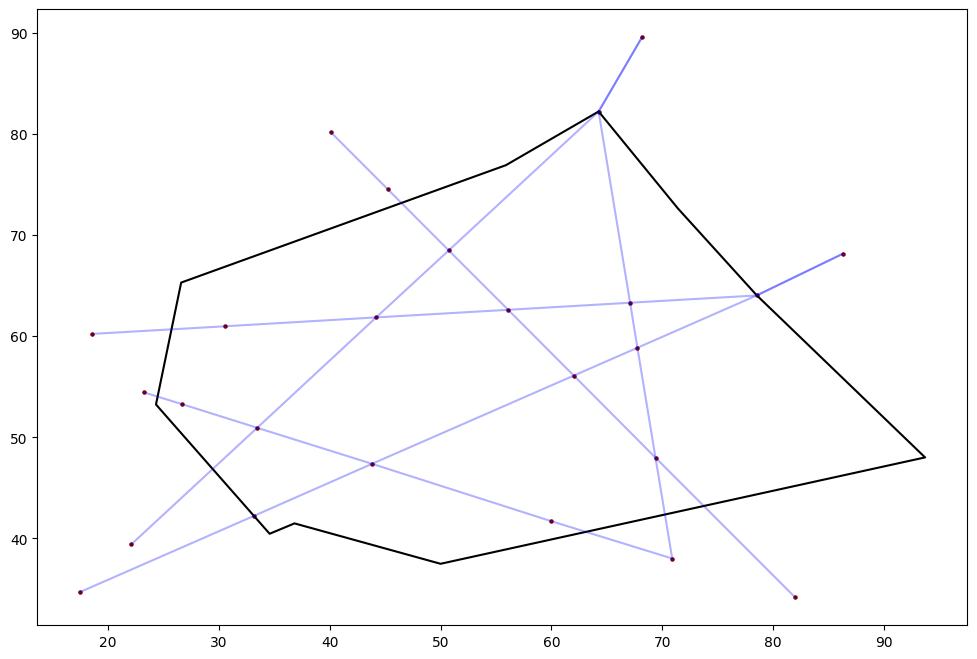

In [3]:
a = plot_sector()

class Ownship:
    def __init__(self, start_x, start_y, heading, speed, offset, original_path, destination):
        self.start_x = start_x
        self.start_y = start_y
        self.x = start_x
        self.y = start_y
        self.offset = offset
        self.heading = heading
        self.speed = speed
        self.offset = offset
        self.destination = destination
        self.pathlist = []
        self.original_path = original_path
        self.position = [self.x, self.y]

    def step(self, n_step, new_heading):
        if n_step <= self.offset:
            self.x = self.start_x
            self.y = self.start_y
        else:    
            self.heading = new_heading
            self.x = np.clip(self.x + self.speed *np.cos(new_heading), 0, 100)
            self.y = np.clip(self.y + self.speed *np.sin(new_heading), 0, 100)
        return self.x, self.y
    
class Intruder:
    def __init__(self, start_x, start_y, offset, heading, speed, destination):
        self.start_x = start_x
        self.stat_y = start_y
        self.x = start_x
        self.y = start_y
        self.offset = offset
        self.heading = heading
        self.speed = speed
        self.destination = destination
        self.position = [self.x, self.y]

    def step(self, n_step, new_heading):
        if n_step <= self.offset:
            self.x = self.start_x
            self.y = self.start_y
        else:
            self.heading = new_heading
            self.x = np.clip(self.x + self.speed *np.cos(new_heading), 0, 100)
            self.y = np.clip(self.y + self.speed *np.sin(new_heading), 0, 100)
        return self.x, self.y


In [4]:
class Agent():
    """
    The Agent class encapsulates the state and parameters for two aircraft in a conflict scenario: the “ownship” (o_) 
    and the “intruder” (i_). Its __init__ method calls a helper to load all scenario data (paths, headings, start/destination
    points, scaled offsets, etc.) for one scenario from our DataFrame, then organizes that into easy-to-use attributes. It 
    also computes fixed speeds and the number of time-steps to reach each aircraft’s first conflict point (“offset”), and 
    prepares a LineString for the ATCO-approved path.

        # 1) Pull all relevant scenario arrays/values for ownship (o_*) and intruder (i_*).
        #    get_conflict_scenario returns:
        #    - o_resolved_path: list of [x, y] for ATCO-approved ownship route
        #    - o_unres_path:   list of [x, y] for original ownship route before conflict resolution
        #    - o_heading:      initial ownship heading (radians)
        #    - o_startposition:ownship start [x, y]
        #    - o_offset_dist_scaled: distance ownship travels before conflict point (scaled)
        #    - o_destination:  ownship destination [x, y]
        #    - i_path:         intruder path coordinates list
        #    - i_headinglist:  list of heading angles for intruder at each step
        #    - i_startposition:intruder start [x, y]
        #    - i_offset_dist_scaled: intruder’s scaled offset distance
        #    - i_destination:  intruder destination [x, y]
        #    - fileinfo:       metadata about this scenario (e.g., filename, index)
    """
    def __init__(self):
        o_resolved_path, o_unres_path, o_heading, o_startposition, o_offset_dist_scaled, o_destination, \
        i_path, i_headinglist, i_startposition, i_offset_dist_scaled, i_destination, fileinfo = get_conflict_scenario(featurefile)
        # 2) Store ownship’s “resolved” (ATCO-approved) vs. “unresolved” paths
        self.o_resolved_path = o_resolved_path
        self.o_unresolved_path = o_unres_path
        # 3) Initial and current heading for ownship
        def _wrap_pi(a: float) -> float:
            return ((float(a) + math.pi) % (2.0 * math.pi)) - math.pi

        self.o_initial_heading = _wrap_pi(o_heading)
        self.o_heading = self.o_initial_heading

        # 4) Start position (tuple) vs. mutable position list
        self.o_start = tuple(o_startposition)
        self.o_position = o_startposition
        # 5) Distance until conflict (“offset”), scaled for ownship
        self.o_offset_dist = o_offset_dist_scaled
        # 6) Final waypoint for ownship
        self.o_destination = o_destination
            # --- Ensure the resolved (ATCO) path runs from START → DESTINATION ---
        def _ensure_forward_path(path, start, dest):
            # If the path is saved backwards (dest→start), reverse it.
            # We compare which ordering is closer to (start, dest) at the ends.
            p0 = np.array(path[0], dtype=float)
            pN = np.array(path[-1], dtype=float)
            start = np.array(start, dtype=float)
            dest  = np.array(dest, dtype=float)
            keep_cost = np.linalg.norm(p0 - start) + np.linalg.norm(pN - dest)
            flip_cost = np.linalg.norm(pN - start) + np.linalg.norm(p0 - dest)
            return path if keep_cost <= flip_cost else list(reversed(path))

        if len(o_resolved_path) >= 2:
            self.o_resolved_path = _ensure_forward_path(o_resolved_path, self.o_start, self.o_destination)
        else:
            # Degenerate path (just in case) – keep as provided
            self.o_resolved_path = o_resolved_path

        # 7) Record actual flown trajectory
        self.o_newpathlist = [self.o_position]

        # 8) Build LineString **after** possibly reversing the path
        self.ATCO_path_linestring = LineString(self.o_resolved_path)

        # 9) Intruder: headings & positions
        self.i_headinglist = i_headinglist
        self.i_start = tuple(i_startposition)
        self.i_position = i_startposition

        # 10) Intruder path/offset/destination
        self.i_path = i_path
        self.i_offset_dist = i_offset_dist_scaled
        self.i_destination = i_destination

        # 11) Fixed speeds (units/step)
        self.o_speed = 2
        self.i_speed = 2

        # 12) Steps to each offset
        self.o_offset = int(np.ceil(self.o_offset_dist / self.o_speed))
        self.i_offset = int(np.ceil(self.i_offset_dist / self.i_speed))

        # 13) Count of applied actions
        self.n_actions = 0

        # 14) Scenario metadata
        self.fileinfo = fileinfo

    def step(self, n_step, new_heading):
        # # Prepare placeholders for new x,y positions
        # xo, yo, xi, yi = 0, 0, 0, 0
        # # --- Move the ownship ---
        # # If we haven’t passed the intruder’s delay yet, keep ownship at its start point
        # # Always remember the latest commanded heading (even if we don't move yet)
        # def _wrap_pi(a: float) -> float:
        #     return ((float(a) + math.pi) % (2.0 * math.pi)) - math.pi

        # self.o_heading = _wrap_pi(new_heading)

        # if n_step <= self.i_offset:
        #     # Not moving yet: keep position, but keep the latched heading
        #     self.o_position = self.o_start
        # else:
        #     # Move forward by o_speed in the x-direction, then force x inside [15,100]
        #     xo = np.clip(self.o_position[0] + self.o_speed *np.cos(new_heading), 15, 100)
        #     # Move forward by o_speed in the y-direction, then force y inside [15,100]
        #     yo = np.clip(self.o_position[1] + self.o_speed *np.sin(new_heading), 15, 100)
        #     # xo = self.o_unresolved_path[n_step - self.i_offset][0]
        #     # yo = self.o_unresolved_path[n_step - self.i_offset][1]

        #     # Update the ownship’s position
        #     self.o_position = [xo,yo]
        # # Save the actual current ownship position (not [0,0] placeholders)
        # self.o_newpathlist.append(list(self.o_position))

        # # print('offset',self.i_offset)
        # # Before the ownship’s delay is up, keep intruder at its start  
        # if n_step <= self.o_offset:
        #     self.i_position = self.i_start
        # # While the intruder still has heading steps left:
        # elif len(self.i_path)+ self.o_offset > n_step > self.o_offset:
        #     # Move in x by i_speed along that heading, keep x inside [15,100]
        #     xi = np.clip(self.i_position[0] + self.i_speed *np.cos(self.i_headinglist[n_step - self.o_offset]), 15, 100)
        #     # Move in y by i_speed along that heading, keep y inside [15,100]
        #     yi = np.clip(self.i_position[1] + self.i_speed *np.sin(self.i_headinglist[n_step - self.o_offset]), 15, 100)
        #     # Update the intruder’s position
        #     self.i_position = [xi, yi]
        # else:
        #     # After the intruder’s whole path is done, jump to its destination
        #     self.i_position = self.i_destination
        # # Return the new ownship and intruder positions
        # return self.o_position, self.i_position

        # Prepare placeholders for new x,y positions
        xo, yo, xi, yi = 0, 0, 0, 0

        # --- Move the ownship ---
        # OLD-PPO-compatible behavior:
        # - Do NOT change self.o_heading until the ownship actually starts moving
        # - Do NOT wrap the angle to (-pi, pi]; keep it as-is
        if n_step <= self.i_offset:
            # Not moving yet: keep position and keep the previous heading unchanged
            self.o_position = self.o_start
        else:
            # Update heading only now (when we start moving), unwrapped
            self.o_heading = new_heading

            # Move forward by o_speed along that heading (clipped to bounds)
            xo = np.clip(self.o_position[0] + self.o_speed*np.cos(new_heading), 15, 100)
            yo = np.clip(self.o_position[1] + self.o_speed*np.sin(new_heading), 15, 100)
            self.o_position = [xo, yo]

        # Save the actual current ownship position
        self.o_newpathlist.append(list(self.o_position))

        # --- Intruder update (unchanged) ---
        if n_step <= self.o_offset:
            self.i_position = self.i_start
        elif len(self.i_path) + self.o_offset > n_step > self.o_offset:
            xi = np.clip(self.i_position[0] + self.i_speed*np.cos(self.i_headinglist[n_step - self.o_offset]), 15, 100)
            yi = np.clip(self.i_position[1] + self.i_speed*np.sin(self.i_headinglist[n_step - self.o_offset]), 15, 100)
            self.i_position = [xi, yi]
        else:
            self.i_position = self.i_destination

        return self.o_position, self.i_position

        
    def path_follow_heading(self, lookahead: float = 1.0) -> float:
        """
        Aim a little ahead on the ATCO path (pure-pursuit). Returns heading in radians.
        """
        cur = Point(self.o_position[0], self.o_position[1])
        s = self.ATCO_path_linestring.project(cur)
        s_next = min(self.ATCO_path_linestring.length, s + lookahead)
        tgt = self.ATCO_path_linestring.interpolate(s_next)
        dx = tgt.x - self.o_position[0]
        dy = tgt.y - self.o_position[1]
        return math.atan2(dy, dx)

In [5]:
A = Agent()

In [6]:
class StructuredEnv(gym.Env):
    """
    This constructor sets up our custom Gym environment. It takes in a list of reward-weight parameters, 
    creates a fresh Agent. It initializes step and reward counters, then defines how many actions are possible 
    and what shape/value-ranges our observations will have. This tells any RL algorithm how to talk to our environment.
    """
    SAFE_R = 5 # Minimum safe separation distance between aircraft
    MAX_STEP = 60 # Maximum number of time-steps per episode

    def __init__(self, Reward_Params= [-1, -1, -1, -1, -1, 1], start_llm_at_step: int = 15):
        # 1) Store the list of six reward-component weights (a1…a6)
        self.Reward_Params = Reward_Params
        # 2) Create a new conflict-scenario agent (ownship + intruder)
        self.agent = Agent()
        # 3) Initialize the reward from the last step, the current step counter and the accumulated total reward
        self.reward = 0
        self.n_step = 0
        self.total_reward = 0
        self.action_space = spaces.Discrete(13)
        first_obs = self.observation_func()
        n = first_obs.size

        low = np.full(n, -np.inf, dtype=np.float64)
        high = np.full(n,  np.inf, dtype=np.float64)

        # 0..5: positions/destination coords (you clip positions inside [15,100], keep generous but finite)
        low[0:6]  = -100.0
        high[0:6] =  120.0

        # 6: separation distance >= 0
        low[6]  = 0.0

        # 7..8: distances to destinations >= 0
        low[7:9] = 0.0

        # 9: cross-track distance to unresolved path (distance) >= 0
        low[9] = 0.0

        # 10: distance to ATCO path (distance) >= 0
        low[10] = 0.0

        # 11: own heading (radians)
        low[11]  = -math.pi
        high[11] =  math.pi

        # 12: ATCO path heading (degrees)
        low[12]  = -180.0
        high[12] =  180.0

        # 13: heading error to path (degrees)
        low[13]  = -180.0
        high[13] =  180.0

        # 14: signed cross-track to path (can be ± large) -> leave as ±inf (already set)

        # 15..16: along-track s and remaining path length >= 0
        low[15:17] = 0.0

        self.observation_space = spaces.Box(low=low, high=high, shape=(n,), dtype=np.float64)
        self.start_llm_at_step = start_llm_at_step  # call LLM only once ≥ this controller step

    def reset(self, seed=None, options=None):
        """
        The reset method is called at the start of each episode to bring the environment back to its initial state. 
        It optionally seeds randomness, creates a fresh Agent (ownship + intruder), zeroes out all counters 
        and rewards, computes the very first observation, and returns that observation along with an empty info dictionary.
        """
        super().reset(seed=seed) # Call parent reset if you pass seed/options
        # Create a new Agent instance for each reset
        self.agent = Agent() 
        # Initialize counters and rewards, Clear out the last step reward 
        self.reward = 0 
        self.n_step = 0
        self.total_reward = 0
        # Compute the initial observation vector from the fresh agent state
        observation = self.observation_func()
        # Gym’s `reset` requires an `info` dict (we have no extra data to return)
        info = {} 
        # Return the tuple (observation, info)
        # This is the standard return format for Gym environments
        # The observation is the initial state of the environment, and info is an empty dictionary
        return observation, info 

    def step(self, action):
        """
        Given an action (one of 13 discrete turn adjustments), 
        it advances the global time-step, converts that action into a small heading change for the ownship, 
        updates both aircraft positions via the Agent.step call, checks if the episode should end 
        (because both planes reached their goals, came too close, moved away, or exceeded the maximum steps), 
        computes the reward based on all those factors, and finally returns the new observation, the step reward, 
        and flags indicating whether the episode terminated or was truncated.

        We chose 0.175/2 because:
        0.175 radians is about 10° (since 1° ≈ 0.01745 rad).
        By dividing by 2, you get ≈0.0875 rad, which is about 5°.
        That way each “1-step” in your discrete action corresponds to a 5° turn. 
        Multiplying that base step by 0–6 (or –6 to –1) then gives you turns of 0°, ±5°, ±10°, … up to ±30° per time-step.
        """
        # 1) Advance the step counter
        self.n_step += 1
        
        # 2) Prepare termination/truncation flags
        terminated = False
        truncated = False
        # --- 3) Choose the base heading depending on the step ---
        # Steps 0–4: autopilot hugs the ATCO path.
        # Step ≥ 5: autopilot OFF → base is current heading; only LLM deltas change it.
        if self.n_step < self.start_llm_at_step:
            base_heading = self.agent.path_follow_heading(lookahead=1.0)
        else:
            base_heading = self.agent.o_heading  # keep flying what we have unless LLM adds a delta

        # --- Discrete delta from action (0.175/2 ≈ 5° per bin) ---
        if action < 7:
            angle = action * (0.175/2)          # +0,+5,...,+30 deg
        else:
            angle = (action - 6) * -(0.175/2)   # -5,...,-30 deg

        # Final heading this step
        ownship_heading = base_heading + angle


        # 4) Move both aircraft one step using the composed heading
        self.agent.step(self.n_step, ownship_heading)

        # 5) Measure distances for termination checks:
        #    - First extract the points 
        #    - Ownship to its destination
        #    - Intruder to its destination
        #    - Separation between the two aircraft
        p1 = self.agent.o_position
        # o_destination = self.agent.o_destination
        o_destination = np.array(self.agent.o_destination, dtype=float)
        p2 = self.agent.i_position
        i_destination = self.agent.i_destination
        dist1_to_dest = np.linalg.norm(np.array(p1) - np.array(o_destination))
        dist2_to_dest = np.linalg.norm(np.array(p2) - np.array(i_destination))
        sep_dist = np.linalg.norm(np.array(p1) - np.array(p2))

        # 6) Terminate if both reached within 5 units of their goals
        if (dist1_to_dest < 5) and (dist2_to_dest < 5):
            terminated = True
        
        # 7) Terminate if they come closer than SAFE_R (collision risk)
        if (sep_dist < self.SAFE_R):
            terminated = True

        # 8) Terminate if ownship is moving away from its goal by more than a small threshold
        threshold = 0.1
        if len(self.agent.o_newpathlist) > 2: # Ensure there's a previous point to compare
            previous_location = np.array(self.agent.o_newpathlist[-2])
            o_current_location = np.array(self.agent.o_position)
            prev_distance = np.linalg.norm(o_destination - previous_location)
            current_distance = np.linalg.norm(o_destination - o_current_location)
            if prev_distance - current_distance < -threshold:
                terminated = True # Punish for moving away

        # 9) Truncate if we exceed MAX_STEP
        if self.n_step >= self.MAX_STEP:
            truncated = True
        
        # 10) Compute the reward, passing a combined “done” flag
        combined_done_for_reward_func = terminated or truncated
        self.reward = self.reward_func(combined_done_for_reward_func)
        self.total_reward += self.reward
        
        # 11) Build next observation and empty info dict
        observation = self.observation_func()
        info = {}
        # 12) Return the Gym-standard 5-tuple
        return observation, self.reward, terminated, truncated, info # Return 5 values

            
    def reward_func(self, done):
        """ 
        This method computes the scalar reward at each step by combining several components—step penalty, 
        trajectory deviation, loss-of-separation penalty/bonus, failure-to-reach penalty, and success bonus—each 
        weighted by the six parameters a1…a6. If the episode has ended (done=True), additional terms (e.g., whether
        we collided or reached the goal) are applied. The final reward is the weighted sum plus any extra “moving-back” 
        penalty.

        """
        # 1) Unpack the six weights from the environment’s configuration        
        a1 = self.Reward_Params[0]
        a2 = self.Reward_Params[1]
        a3 = self.Reward_Params[2]
        a4 = self.Reward_Params[3]
        a5 = self.Reward_Params[4]
        a6 = self.Reward_Params[5]
        
        # 2) Base costs or rewards (initialized here)
        Reward_Step = 0.01 # small per-step penalty to encourage faster resolution
        Moving_back_reward = 0 # penalty if ownship moves away from its goal
        CTDreward = 0 # placeholder for distance-from-original-path reward (unused)
        reward_traj_dev = 0 # trajectory deviation reward


        # 3) Compute deviation from the ATCO-approved path:
        #    • Create a Point for ownship’s current pos
        #    • Compute its distance to the approved LineString (in same units)
        #    • Scale by 20/1000 to form the deviation reward
        o_destination = np.array(self.agent.o_destination)       
        o_current_location = Point(self.agent.o_position)
        ATCO_path_linestring = self.agent.ATCO_path_linestring
        dist = o_current_location.distance(ATCO_path_linestring)
        reward_traj_dev =  20 * (dist/1000)
        # 4) Combine any CTDreward (currently zero) with the trajectory deviation
        Reward_Deviation = CTDreward +  reward_traj_dev # This is negative, so it penalizes deviation
        
        # 5) Initialize other components
        Reward_LOS = 0
        Reward_Maneuvering = 0
        Reward_Not_Reached = 0
        Reward_Reached =0

        # 6) Distance between ownship and intruder (for LOS/collision)
        dis1 = np.linalg.norm(np.array(self.agent.o_position) - np.array(self.agent.i_position))
        
        Reward_LOS = 0
        threshold = 0.1
        # 7) Only apply certain rewards/penalties once the episode is done
        if done:
            # 7a) Collision or near-miss bonus/penalty: if we ended due to separation breach
            if (dis1 < self.SAFE_R) :
                Reward_LOS = 10 # This is a negative reward, so it penalizes loss of separation

            # 7b) If we reached the maximum number of steps without reaching the destination
            if self.n_step == self.MAX_STEP:
                # Penalize based on how far ownship still is from its destination
                current_location = self.agent.o_position
                dist_o_d = np.linalg.norm(np.array(o_destination) - np.array(current_location))
                Reward_Not_Reached = (dist_o_d/10) # Penalize for not reaching destination

            # 7c) Penalty if the ownship just moved away from its destination in final step (done in the else part)
            if len(self.agent.o_newpathlist) <=2:
                pass
            else:
                # Grab the second-to-last position we recorded for ownship
                previous_location = np.array(self.agent.o_newpathlist[-2])
                # Grab the current position of ownship
                o_current_location = np.array(self.agent.o_position)
                # Compute distance from that previous point to the destination
                prev_distance = np.linalg.norm(o_destination - previous_location)
                # Compute distance from the final point to the destination
                current_distance = np.linalg.norm(o_destination - o_current_location)
                # If current_distance > prev_distance by more than `threshold`,
                # it means ownship moved away. We then set a penalty:
                if prev_distance - current_distance < -threshold:
                    Moving_back_reward =  -20
               

            #reaching destination
            p1 = self.agent.o_position
            o_destination = self.agent.o_destination
            p2 = self.agent.i_position
            
            i_destination = self.agent.i_destination
            # 7d) Success bonus or failure penalty upon reaching ownship destination (else condition)
            dist1 = np.linalg.norm(np.array(p1) - np.array(o_destination))
            # dist2 = np.linalg.norm(np.array(p2) - np.array(i_destination))
            if (dist1 < 5): # reaching destination
                Reward_Reached = 10
            else:
                Reward_Reached = - dist1/10 # penalize for not reaching destination (proportional to remaining distance)

        reward = a1 * Reward_Step + a2 *Reward_Deviation + a3 * Reward_LOS + \
                    a5 * Reward_Not_Reached + a6 * Reward_Reached + Moving_back_reward 
        return reward        


    def observation_func(self):
        """
        This method gathers all the state information we want the agent to “see” at each step,
        packs it into a flat NumPy array, and returns it. It includes the ownship’s and intruder’s positions,
        the ownship’s destination, pairwise distances (between aircraft and to each destination), how far the ownship
        has strayed from its original and ATCO-approved paths, and the ownship’s current heading.

        The observation vector contains, in order:
            Ownship’s X and Y position
            Intruder’s X and Y position
            Ownship’s destination X and Y
            Distance between ownship and intruder
            Distance from ownship to its destination
            Distance from intruder to its destination
            Distance from ownship to its original (unresolved) path
            Distance from ownship to the ATCO-approved path
            Ownship’s current heading angle
        """
        observation  = []

        observation.append(self.agent.o_position[0])
        observation.append(self.agent.o_position[1])
        observation.append(self.agent.i_position[0])
        observation.append(self.agent.i_position[1])
        observation.append(self.agent.o_destination[0])
        observation.append(self.agent.o_destination[1])
        # observation.append(self.agent.i_destination[0])
        # observation.append(self.agent.i_destination[1])
    

        dist1 = np.linalg.norm(np.array(self.agent.o_position) - np.array(self.agent.i_position)) 
        dist_o_d = np.linalg.norm(np.array(self.agent.o_position) - np.array(self.agent.o_destination))
        dist_i_d = np.linalg.norm(np.array(self.agent.i_position) - np.array(self.agent.i_destination))

        # Distance between ownship and intruder
        observation.append(dist1)  
        # Distance from ownship to its destination
        observation.append(dist_o_d)
        # Distance from intruder to its destination
        observation.append(dist_i_d)
        # individual coordinates

        current_location = Point(self.agent.o_position)
        # How far ownship is from its ORIGINAL unresolved path
        CTD_distance  = current_location.distance(LineString(self.agent.o_unresolved_path))
        # How far ownship is from the ATCO-approved path
        dist_from_ATCO_path = current_location.distance(self.agent.ATCO_path_linestring)

        observation.append(CTD_distance) #
        observation.append(dist_from_ATCO_path)

        # Ownship’s current heading angle (radians)
        observation.append(self.agent.o_heading)  

        # New LLM observation:
        # --- NEW ATCO-path features ---
                # --- NEW ATCO-path features ---
        cur_pt = Point(self.agent.o_position[0], self.agent.o_position[1])
        line = self.agent.ATCO_path_linestring

        # Along-track distance s and foot point on the path
        s = line.project(cur_pt)
        foot = line.interpolate(s)

        # Unit tangent at s (finite-difference fallback)
        eps = max(1e-3, min(1.0, 0.001 * line.length))
        p_fwd = line.interpolate(min(line.length, s + eps))
        tx, ty = (p_fwd.x - foot.x, p_fwd.y - foot.y)
        if abs(tx) < 1e-9 and abs(ty) < 1e-9:  # fallback if degenerate
            h = self.agent.path_follow_heading(lookahead=1.0)
            tx, ty = math.cos(h), math.sin(h)

        # Signed cross-track: sign by 2D cross product (tangent × foot->own)
        dx, dy = (cur_pt.x - foot.x, cur_pt.y - foot.y)
        cross = tx * dy - ty * dx
        signed_xtrk = math.copysign(math.hypot(dx, dy), cross)

        # Convert tangent to degrees
        path_heading_deg = math.degrees(math.atan2(ty, tx))
        own_heading_deg  = math.degrees(self.agent.o_heading)
        # heading_error_to_path_deg = (path - own) wrapped to (-180, 180]
        heading_error_to_path_deg = ((path_heading_deg - own_heading_deg + 180.0) % 360.0) - 180.0

        # Keep ObsSnapshot’s expected order:
        observation.extend([
            path_heading_deg,           # index 12
            heading_error_to_path_deg,  # index 13
            signed_xtrk,                # index 14
        ])

        # (Optional) You can still add these extras; ObsSnapshot just ignores them:
        along_track_s = float(s)
        remaining_path_len = float(line.length - s)
        observation.extend([along_track_s, remaining_path_len])  # indices 15,16 (optional)
   
        # Convert to a NumPy array and return
        observation = np.array(observation)

        # NEW LLM observation
        
        return observation

   
    def render(self, show = False, folder = './Images/'):
        """
        The render method draws a snapshot of the current episode on top of our sector plot, marking both aircraft’s 
        start, current, and destination points, the ATCO-approved path, and safety circles. It can either display the 
        figure interactively or save it to disk. The close method is a no-op placeholder for any future cleanup.
        """
        # fig, ax = plt.subplots(figsize = (14, 11))
        # print("Ownship", self.agent.o_start)
        # print("intruder", self.agent.i_start)
        # print(self.agent.fileinfo)

        # 1) Draw the static sector background
        figure = plot_sector() # Call our helper to redraw boundaries/waypoints
        ax = figure.gca()  # Grab the current Axes for plotting overlays
        # ax.scatter(50,50, s = 200)
        
        # 2)Plot ownship’s current position (black dot), Plot ownship’s start (black triangle), Plot ownship’s destination (black star)
        ax.scatter(self.agent.o_position[0], self.agent.o_position[1], c = 'black', s = 40)
        ax.scatter(self.agent.o_start[0], self.agent.o_start[1] , c = 'black', s = 50, marker = '^')
        ax.scatter(self.agent.o_destination[0], self.agent.o_destination[1], c = 'black', s = 20, marker= '*')

        # 3) Plot intruder’s current position (maroon dot), Plot intruder’s start (maroon triangle), Plot intruder’s destination (maroon star)
        ax.scatter(self.agent.i_position[0], self.agent.i_position[1], c = 'maroon', s = 40)
        ax.scatter(self.agent.i_start[0], self.agent.i_start[1] , c = 'maroon', s = 50, marker = '^')
        ax.scatter(self.agent.i_destination[0], self.agent.i_destination[1], c = 'maroon', s = 20, marker= '*')
        x, y = [],[]
        for i in range(len(self.agent.o_unresolved_path)):
            x.append(self.agent.o_unresolved_path[i][0])    
            y.append(self.agent.o_unresolved_path[i][1])
            
        # ax.plot(x,y, linewidth = 1, color = 'grey')
        #add circle to the destination
        
        # 4) Draw the ATCO-approved path as a dashed maroon line
        x_, y_ = self.agent.ATCO_path_linestring.xy
        ax.plot(x_, y_, color = 'maroon',linestyle = '--', alpha = 1)

        # 5) Add translucent safety circles around each destination
        circle1 = plt.Circle((self.agent.o_destination[0], self.agent.o_destination[1]), 5, color = 'black',\
                              alpha = 0.2)
        circle2 = plt.Circle((self.agent.i_destination[0], self.agent.i_destination[1]), 5, color = 'maroon',\
                              alpha = 0.5)
        ax.add_patch(circle1)
        ax.add_patch(circle2)
        # 6) Annotate title with step number, recent reward, totals, headings, and offsets
        ax.set_title("Step {} - Reward {:.3f} - Total Reward {:.3f} - headings{}  - offsets(O:I){}".format(self.n_step,self.reward,\
                                                                            self.total_reward,\
                                                                                ((self.agent.o_initial_heading) ,\
                                                                                     np.round(math.degrees(self.agent.o_heading),2)),\
                                                                                        (self.agent.o_offset, self.agent.i_offset)))

        # ax.axis('scaled')
        
        # 7) Display the plot or save it to a file
        if show:
            plt.show()
        else:
            # Save the plot as a PNG file named by step number
            plt.savefig(folder + "image_{:0>3}.png".format(self.n_step)) 
            print(folder + "image_{:0>3}.png".format(self.n_step))

        return figure

    def close(self):
        # Placeholder for any cleanup (e.g., closing files or windows). Currently does nothing.
        pass

In [7]:
from stable_baselines3.common.env_checker import check_env
START_LLM_AT_STEP = 15
env = StructuredEnv(start_llm_at_step=START_LLM_AT_STEP)
check_env(env)

./Images/image_000.png


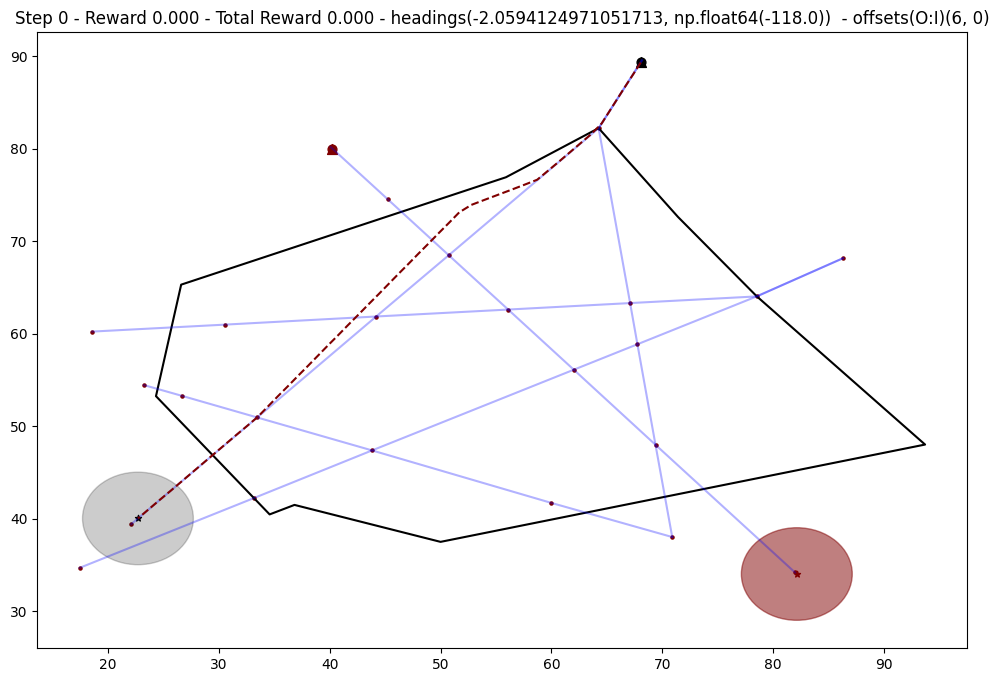

In [8]:
# Quick smoke test: reset, render one frame, then close3 
env.reset() # Reset the environment to its initial state
env.render() # Draw and save the first frame
env.close() # Close the environment (no-op here, but good practice)

In [9]:
# Sanity check: print the observation vector shape and values
env.observation_func()

array([ 6.80600000e+01,  8.93007500e+01,  4.02400000e+01,  7.99985000e+01,
        2.27000000e+01,  4.00317500e+01,  2.93340119e+01,  6.69698735e+01,
        6.22011962e+01,  0.00000000e+00,  0.00000000e+00, -2.05941250e+00,
       -1.17995644e+02,  4.60431693e-12,  0.00000000e+00,  0.00000000e+00,
        6.78034173e+01])

Overview of the Training & Evaluation Pipeline
This final section shows how we hook our custom environment into Stable-Baselines3’s PPO agent, train it, save the model, evaluate its performance, generate rollout animations, and finally launch TensorBoard to visualize training metrics.

 CHECKING THE PERCENTAGE OF SCENARIOS HAVING CONFLICTS
env = env
 Visualize 1 episode using the trained policy and store the image into selected folder
res = []
for trial in range(100):
    obs = env.reset()
    for i in range(60):
        # Take a random action
        action = 0
        obs, reward, done, info = env.step(action)
        
        # Render the game
        if done == True:
            if reward <= -5:
                res.append(1)
            else:
                res.append(0)
            break

res = np.mean(res)
print('res', res)

## PPO PyTorch Implementation

In [10]:

from tensorboardX import SummaryWriter
run_name = "PPO_v2"  
log_dir  = f"./log/PPO/{run_name}"
writer   = SummaryWriter(log_dir)
%tensorboard --logdir ./log/PPO/ --host localhost --port 8040

Launching TensorBoard...

PyTorch version V4 - Following are the changes made on top of the previous version for smoother convergence:
- Used GAE(λ) + normalize advantages: We switched from raw Monte-Carlo returns to GAE and now only normalize advantages, which cuts variance in the policy gradient a lot.
- Mini-batch updates (with shuffling) + multiple epochs: Instead of one big full-batch step, we split each rollout into mini-batches and do a few passes (K_epochs=5). This steadies updates and avoids overfitting a single batch.
- Gradient clipping: We clip grads at 0.5 so no single update can “explode” the policy.
- Lower learning rates: lr_actor=2e-4, lr_critic=8e-4 (down from 3e-4 / 1e-3) to make each step gentler.
- Deterministic evaluation (argmax): During eval only, we pick the most likely action instead of sampling, so the eval curve reflects policy quality—not randomness.
- Observation normalization
- Reward normalization (per update batch): We standardize rewards within each update to keep target scales consistent for the value loss.

In [11]:
def _atomic_torch_save(obj, path: str):
    tmp = path + ".tmp"
    torch.save(obj, tmp)
    os.replace(tmp, path)

def save_training_checkpoint(path: str, agent, time_step: int, episode: int):
    ckpt = {
        # models
        "policy": agent.policy.state_dict(),
        "policy_old": agent.policy_old.state_dict(),
        "optimizer": agent.optimizer.state_dict(),
        # obs normalizer
        "obs_mean": agent.obs_rms.mean.detach().cpu(),
        "obs_var":  agent.obs_rms.var.detach().cpu(),
        "obs_count": float(agent.obs_rms.count),
        # counters
        "time_step": int(time_step),
        "episode": int(episode),
        # RNG states (optional but useful)
        "torch_rng": torch.get_rng_state(),
        "numpy_rng": np.random.get_state(),
        "py_rng":    random.getstate(),
        "cuda_rng":  torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
        # (optional) hyperparams snapshot if you want
        "hparams": {
            "gamma": agent.gamma,
            "K_epochs": agent.K_epochs,
            "eps_clip": agent.eps_clip,
            "mb_size": agent.mb_size,
            "gae_lambda": agent.gae_lambda,
        },
    }
    _atomic_torch_save(ckpt, path)

def load_training_checkpoint(path: str, agent, device):
    ckpt = torch.load(path, map_location=device)

    agent.policy.load_state_dict(ckpt["policy"])
    agent.policy_old.load_state_dict(ckpt["policy_old"])
    agent.optimizer.load_state_dict(ckpt["optimizer"])

    agent.obs_rms.mean  = ckpt["obs_mean"].to(device)
    agent.obs_rms.var   = ckpt["obs_var"].to(device)
    agent.obs_rms.count = ckpt["obs_count"]

    # restore RNG states (optional)
    torch.set_rng_state(ckpt["torch_rng"])
    if torch.cuda.is_available() and ckpt.get("cuda_rng") is not None:
        torch.cuda.set_rng_state_all(ckpt["cuda_rng"])
    np.random.set_state(ckpt["numpy_rng"])
    random.setstate(ckpt["py_rng"])

    return int(ckpt["time_step"]), int(ckpt["episode"])


In [12]:
# 0. Utilities: Running Mean/Std for Obs Normalization
class RunningMeanStd:
    """Track running mean and variance of observations."""
    def __init__(self, shape, eps: float = 1e-4):
        self.mean  = torch.zeros(shape, dtype=torch.float32, device=device)
        self.var   = torch.ones(shape,  dtype=torch.float32, device=device)
        self.count = eps

    @torch.no_grad()
    def update(self, x: torch.Tensor):
        # x: (..., shape)
        if x.dim() == 1:
            x = x.unsqueeze(0)
        batch_mean = x.mean(dim=0)
        batch_var  = x.var(dim=0, unbiased=False)
        batch_count = x.shape[0]
        delta = batch_mean - self.mean
        tot_count = self.count + batch_count
        new_mean = self.mean + delta * (batch_count / tot_count)
        m_a = self.var * self.count
        m_b = batch_var * batch_count
        M2 = m_a + m_b + (delta ** 2) * self.count * batch_count / tot_count
        new_var = M2 / tot_count
        self.mean, self.var, self.count = new_mean, new_var, tot_count

    def normalize(self, x: torch.Tensor) -> torch.Tensor:
        return (x - self.mean) / torch.sqrt(self.var + 1e-8)

# 1. Rollout Buffer
class RolloutBuffer:
    def __init__(self):
        self.states       = []  # list of torch tensors (normalized obs) on device
        self.actions      = []  # list of torch tensors on device
        self.logprobs     = []  # list of torch tensors on device
        self.state_values = []  # list of torch tensors on device
        self.rewards      = []  # list of floats
        self.is_terminals = []  # list of bools
        # NEW: for hybrid path with LLM intent
        self.intents          = []  # torch float32, shape [4]
        self.active_masks     = []  # torch float32 scalar {0,1}
        self.llm_target_bin   = []  # python int (0..12) or -1 if N/A
        self.llm_target_deg   = []  # python float (snapped deg) or 0.0 if N/A


    def clear(self):
        # Reset all buffer lists by reinitializing
        self.__init__()

# 2. Hybrid Actor-Critic Network (attention-ready, backward compatible)
class HybridActorCritic(nn.Module):
    """
    Backward-compatible drop-in for ActorCritic:
      - Keeps .net (state-only MLP), .actor, .critic so existing calls keep working.
      - Adds .intent_proj and .attn + a fuse() path we will enable in Step 2.
      - Right now, PPO continues to use the state-only path (identical behavior).
    """
    def __init__(self, state_dim, action_dim, d_model: int = 64, n_heads: int = 1):
        super().__init__()
        # --- State-only path (kept for backward-compat) ---
        self.net = nn.Sequential(
            nn.Linear(state_dim, d_model), nn.Tanh(),
            nn.Linear(d_model, d_model),   nn.Tanh()
        )
        self.actor  = nn.Sequential(nn.Linear(d_model, action_dim), nn.Softmax(dim=-1))
        self.critic = nn.Linear(d_model, 1)

        # --- New components for fusion (will be used in Step 2) ---
        self.intent_proj = nn.Linear(4, d_model)
        self.attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True)

        # Cache to support "hold" reuse later (Step 3)
        self._last_fused: Optional[torch.Tensor] = None

    # ---- Backward-compatible API used by your current PPO ----
    def act(self, state: torch.Tensor):
        """
        Current training/eval uses state-only path to keep behavior identical.
        We'll switch this to fused path in Step 2.
        """
        features     = self.net(state)
        action_probs = self.actor(features)
        dist         = Categorical(action_probs)

        action      = dist.sample()
        action_logp = dist.log_prob(action)
        value       = self.critic(features)
        return action.detach(), action_logp.detach(), value.detach()

    def evaluate(self, states: torch.Tensor, actions: torch.Tensor):
        """
        Batch evaluation on the state-only path (unchanged behavior).
        """
        features        = self.net(states)
        action_probs    = self.actor(features)
        dist            = Categorical(action_probs)

        action_logprobs = dist.log_prob(actions)
        dist_entropy    = dist.entropy()
        state_values    = self.critic(features).squeeze(-1)
        return action_logprobs, state_values, dist_entropy

    # ---- New fusion utilities (will be used starting Step 2) ----
    def fuse(self, state_emb: torch.Tensor,
             intent_emb: Optional[torch.Tensor] = None,
             active_mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        """
        Build a two-token sequence [state_token, intent_token] and run MHSA.
        If no intent or active_mask==0, bypass and return state token.
        Shapes:
          state_emb:  (B, d_model)  from a state MLP/projection
          intent_emb: (B, 4)        raw intent (norm_turn, norm_hold, is_wait, is_exec)
          active_mask: scalar or (B,) 1=use attention, 0=bypass
        Returns:
          fused embedding z: (B, d_model)
        """
        # State token (project to d_model if needed)
        h_s = self.net[0](state_emb) if state_emb.shape[-1] != self.net[0].in_features else state_emb
        if state_emb.shape[-1] == self.net[0].in_features:
            # Run the same two-layer MLP to stay consistent with current features
            h_s = self.net(state_emb)  # (B, d_model)

        # Bypass unless explicitly active
        use_attn = (intent_emb is not None) and (active_mask is not None) and (
            (torch.is_tensor(active_mask) and torch.any(active_mask != 0)) or
            (not torch.is_tensor(active_mask) and active_mask != 0)
        )
        if not use_attn:
            return h_s

        # Intent token
        h_i = torch.tanh(self.intent_proj(intent_emb))  # (B, d_model)

        # Tokens: (B, 2, d_model)
        tokens = torch.stack([h_s, h_i], dim=1)
        attn_out, _ = self.attn(tokens, tokens, tokens, need_weights=False)
        z = attn_out.mean(dim=1)  # simple pooling over the 2 tokens
        return z

    def act_from_fused(self, z: torch.Tensor):
        action_probs = self.actor(z)
        dist         = Categorical(action_probs)
        action      = dist.sample()
        action_logp = dist.log_prob(action)
        value       = self.critic(z)
        return action.detach(), action_logp.detach(), value.detach()

    def evaluate_from_fused(self, z: torch.Tensor, actions: torch.Tensor):
        action_probs    = self.actor(z)
        dist            = Categorical(action_probs)
        action_logprobs = dist.log_prob(actions)
        dist_entropy    = dist.entropy()
        state_values    = self.critic(z).squeeze(-1)
        return action_logprobs, state_values, dist_entropy


# 3. PPO Agent Wrapper
class PPO:
    def __init__(
        self,
        state_dim,
        action_dim,
        lr_actor=2e-4,
        lr_critic=8e-4,
        gamma=0.99,
        K_epochs=5,
        eps_clip=0.2,
        mb_size=256,
        gae_lambda=0.95,
        normalize_reward=True,
    ):
        self.gamma      = gamma
        self.eps_clip   = eps_clip
        self.K_epochs   = K_epochs
        self.mb_size    = mb_size
        self.gae_lambda = gae_lambda
        self.normalize_reward = normalize_reward

        self.buffer = RolloutBuffer()

        # Observation normalizer
        self.obs_rms = RunningMeanStd(shape=state_dim)

        # Initialize current & old policy networks on device
        # self.policy     = ActorCritic(state_dim, action_dim).to(device)
        # self.policy_old = ActorCritic(state_dim, action_dim).to(device)
        self.policy     = HybridActorCritic(state_dim, action_dim).to(device)
        self.policy_old = HybridActorCritic(state_dim, action_dim).to(device)
        self.policy_old.load_state_dict(self.policy.state_dict())

        # Optimizer for actor and critic parameters
        self.optimizer = torch.optim.Adam([
            {'params': self.policy.net.parameters(),        'lr': lr_actor},   # state MLP
            {'params': self.policy.actor.parameters(),      'lr': lr_actor},
            {'params': self.policy.critic.parameters(),     'lr': lr_critic},
            {'params': self.policy.intent_proj.parameters(),'lr': lr_actor},   # new
            {'params': self.policy.attn.parameters(),       'lr': lr_actor},   # new
        ])
        self.MseLoss = nn.MSELoss()
        # --- NEW: alignment knobs (defaults keep behavior almost identical) ---
        self.use_kl_to_llm = True
        self.use_mse_to_llm = False
        self.lambda_kl = 0.10
        self.lambda_mse = 0.00

        # Bin → degrees map for expected-heading MSE
        self._deg_by_idx = torch.tensor(
            [0, 5,10,15,20,25,30,  -5,-10,-15,-20,-25,-30],
            dtype=torch.float32, device=device
        )
        # Cache for "hold_steps" fused embedding reuse (episode-scoped)
        self._fused_cache = None

    def _normalize_obs_train(self, state_tensor: torch.Tensor) -> torch.Tensor:
        # Update running stats with current state, then normalize
        self.obs_rms.update(state_tensor)
        return self.obs_rms.normalize(state_tensor)

    def _normalize_obs_eval(self, state_tensor: torch.Tensor) -> torch.Tensor:
        # Use current running stats, do NOT update during evaluation
        return self.obs_rms.normalize(state_tensor)

        # --- helpers for LLM-intent (unused = zeros) ---
    def _prepare_intent_tensors(self, intent_embed, phase_active: int):
        """
        Returns (intent_t [4], mask_t [1]) on device.
        If intent_embed is None, returns zeros and mask=0.
        """
        if intent_embed is None:
            intent_t = torch.zeros(4, dtype=torch.float32, device=device)
            mask_t   = torch.tensor([0.0], dtype=torch.float32, device=device)
        else:
            # expect a length-4 iterable: [norm_turn, norm_hold, is_wait, is_exec]
            intent_t = torch.tensor(intent_embed, dtype=torch.float32, device=device)
            mask_t   = torch.tensor([1.0 if phase_active else 0.0], dtype=torch.float32, device=device)
        return intent_t, mask_t

    def _snap_deg_to_bin_index(self, deg: float) -> int:
        """
        Map degrees in {0,±5,±10,...,±30} to action index 0..12.
        Returns -1 if deg is invalid (not multiple of 5 or |deg|>30).
        Bins: 0..6 => +0,+5,+10,+15,+20,+25,+30; 7..12 => -5,-10,-15,-20,-25,-30
        """
        d = int(round(float(deg)))
        if d % 5 != 0 or abs(d) > 30:
            return -1
        return d // 5 if d >= 0 else 6 + (abs(d) // 5)

    def select_action_hybrid(self, state, intent_embed=None, phase_active: int = 0,
                             target_deg: float = None, reuse_cached: bool = False):
        """
        Hybrid selection on policy_old using fused embedding.
        If reuse_cached is True and a cache exists, we reuse the last fused z (ignores new obs).
        """
        # 1) normalize obs (train-time)
        state_tensor = torch.tensor(state, dtype=torch.float32, device=device)
        norm_state   = self._normalize_obs_train(state_tensor)  # [state_dim]

        # 2) prepare intent + mask
        intent_t, mask_t = self._prepare_intent_tensors(intent_embed, phase_active)

        # 3) decide fused embedding (reuse or recompute)
        z: torch.Tensor
        if reuse_cached and (self._fused_cache is not None):
            z = self._fused_cache  # (d_model,)
        else:
            z = self.policy_old.fuse(
                norm_state.unsqueeze(0),     # (1, state_dim)
                intent_t.unsqueeze(0),       # (1, 4)
                mask_t                       # (1,)
            ).squeeze(0)                      # (d_model,)
            # Only keep cache while an LLM phase is active (mask=1)
            self._fused_cache = z.detach() if (mask_t.item() > 0.5) else None

        # 4) sample from fused embedding (policy_old heads)
        action, logp, value = self.policy_old.act_from_fused(z)

        # 5) store rollout (keep old fields; add new)
        self.buffer.states.append(norm_state)
        self.buffer.actions.append(action)
        self.buffer.logprobs.append(logp)
        self.buffer.state_values.append(value)

        self.buffer.intents.append(intent_t)         # [4]
        self.buffer.active_masks.append(mask_t[0])   # scalar

        if target_deg is None:
            self.buffer.llm_target_bin.append(-1)
            self.buffer.llm_target_deg.append(0.0)
        else:
            idx = self._snap_deg_to_bin_index(target_deg)
            self.buffer.llm_target_bin.append(idx)
            self.buffer.llm_target_deg.append(float(int(round(target_deg))))

        return action.cpu().item()

    def clear_fused_cache(self):
        self._fused_cache = None

    def select_action(self, state):
        # Convert raw state to tensor on device and normalize (train-time)
        state_tensor = torch.tensor(state, dtype=torch.float32, device=device)
        norm_state   = self._normalize_obs_train(state_tensor)
        action, logp, value = self.policy_old.act(norm_state)

        # Store tensors directly (already on device)
        self.buffer.states.append(norm_state)
        self.buffer.actions.append(action)
        self.buffer.logprobs.append(logp)
        self.buffer.state_values.append(value)

        return action.cpu().item()

    def update(self):
        """ PPO update on fused embeddings with optional LLM alignment (phase-gated). """
        # ---- Stack rollout tensors (on device) ----
        states      = torch.stack(self.buffer.states,       dim=0)  # (T, obs_dim) normalized
        actions     = torch.stack(self.buffer.actions,      dim=0)  # (T,)
        old_logprob = torch.stack(self.buffer.logprobs,     dim=0)  # (T,)
        values      = torch.stack(self.buffer.state_values, dim=0).squeeze(-1)  # (T,)
        rewards_raw = torch.tensor(self.buffer.rewards, dtype=torch.float32, device=device)
        dones       = torch.tensor(self.buffer.is_terminals, dtype=torch.float32, device=device)

        # ---- LLM fields (backward-compatible) ----
        if len(self.buffer.intents) == 0:
            # Pure-PPO rollout: fabricate zeros so fuse() bypasses attention
            B = states.size(0)
            intents    = torch.zeros(B, 4, dtype=torch.float32, device=device)
            masks      = torch.zeros(B,    dtype=torch.float32, device=device)
            target_idx = torch.full((B,), -1, dtype=torch.long, device=device)
            target_deg = torch.zeros(B,    dtype=torch.float32, device=device)
        else:
            intents    = torch.stack(self.buffer.intents,      dim=0)  # (T, 4)
            masks      = torch.stack(self.buffer.active_masks, dim=0)  # (T,)
            target_idx = torch.tensor(self.buffer.llm_target_bin, dtype=torch.long,   device=device)
            target_deg = torch.tensor(self.buffer.llm_target_deg, dtype=torch.float32, device=device)


        # ---- Reward normalization (per-batch) ----
        rewards = rewards_raw
        if self.normalize_reward:
            r_mean = rewards_raw.mean()
            r_std  = rewards_raw.std(unbiased=False)
            rewards = (rewards_raw - r_mean) / (r_std + 1e-8)

        # ---- GAE(λ) advantages using (normalized) rewards ----
        T = rewards.size(0)
        advantages = torch.zeros(T, dtype=torch.float32, device=device)
        last_gae = 0.0
        values_ext = torch.cat([values, torch.zeros(1, device=device)], dim=0)
        for t in reversed(range(T)):
            next_value = values_ext[t + 1]
            delta = rewards[t] + self.gamma * next_value * (1.0 - dones[t]) - values[t]
            last_gae = delta + self.gamma * self.gae_lambda * (1.0 - dones[t]) * last_gae
            advantages[t] = last_gae
        returns = advantages + values
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        # ---- Mini-batch SGD over K epochs on FUSED embeddings ----
        batch_size = states.size(0)
        mb_size = min(self.mb_size, batch_size)
        for _ in range(self.K_epochs):
            idx = torch.randperm(batch_size, device=device)
            for start in range(0, batch_size, mb_size):
                mb_idx = idx[start:start + mb_size]

                mb_states  = states[mb_idx]        # (B, obs_dim)
                mb_intents = intents[mb_idx]       # (B, 4)
                mb_masks   = masks[mb_idx]         # (B,)
                mb_actions = actions[mb_idx]       # (B,)
                mb_old_lp  = old_logprob[mb_idx]   # (B,)
                mb_adv     = advantages[mb_idx]    # (B,)
                mb_ret     = returns[mb_idx]       # (B,)
                mb_tgt_idx = target_idx[mb_idx]    # (B,)
                mb_tgt_deg = target_deg[mb_idx]    # (B,)

                # -- FUSE with current policy --
                z = self.policy.fuse(mb_states, mb_intents, mb_masks)  # (B, d_model)

                # -- Evaluate taken actions on current policy --
                logprobs, state_vals, entropy = self.policy.evaluate_from_fused(z, mb_actions)
                ratios = torch.exp(logprobs - mb_old_lp.detach())
                surr1  = ratios * mb_adv
                surr2  = torch.clamp(ratios, 1 - self.eps_clip, 1 + self.eps_clip) * mb_adv

                policy_loss   = -torch.min(surr1, surr2).mean()
                value_loss    = self.MseLoss(state_vals, mb_ret)
                entropy_bonus = -0.01 * entropy.mean()

                # -- OPTIONAL: LLM alignment during phases only (mask>0 & valid target idx) --
                align_loss = torch.zeros((), dtype=torch.float32, device=device)

                if self.use_kl_to_llm or self.use_mse_to_llm:
                    probs_all = self.policy.actor(z)                 # (B, 13)
                    log_all   = torch.log(probs_all + 1e-8)

                    valid = (mb_masks > 0.5) & (mb_tgt_idx >= 0)     # boolean mask
                    if valid.any():
                        v_idx = torch.nonzero(valid, as_tuple=False).squeeze(-1)

                        if self.use_kl_to_llm and self.lambda_kl > 0.0:
                            # CE to one-hot target (equiv. KL to delta target)
                            chosen = log_all[v_idx, mb_tgt_idx[v_idx]]
                            ce_loss = -chosen.mean()
                            align_loss = align_loss + self.lambda_kl * ce_loss

                        if self.use_mse_to_llm and self.lambda_mse > 0.0:
                            exp_deg = (probs_all[v_idx] * self._deg_by_idx.unsqueeze(0)).sum(dim=-1)
                            mse = ((exp_deg - mb_tgt_deg[v_idx]) ** 2).mean()
                            align_loss = align_loss + self.lambda_mse * mse

                loss = policy_loss + 0.5 * value_loss + entropy_bonus + align_loss

                self.optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.policy.parameters(), 0.5)
                self.optimizer.step()

        # ---- Sync old policy and clear buffer ----
        self.policy_old.load_state_dict(self.policy.state_dict())
        self.buffer.clear()


    def save(self, path):
        torch.save(self.policy_old.state_dict(), path)

    def load(self, path):
        state_dict = torch.load(path, map_location=device)
        self.policy_old.load_state_dict(state_dict)
        self.policy.load_state_dict(state_dict)

# 4. Evaluation Function
def evaluate_policy(agent, env, n_episodes=10):
    """Deterministic evaluation (argmax over action probs) for smoother curves.
    Uses observation normalization stats but does not update them.
    """
    returns = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        done = False
        ep_ret = 0.0
        while not done:
            state_tensor = torch.tensor(obs, dtype=torch.float32, device=device)
            norm_state   = agent._normalize_obs_eval(state_tensor)
            with torch.no_grad():
                features = agent.policy_old.net(norm_state)
                probs    = agent.policy_old.actor(features)
                action   = torch.argmax(probs, dim=-1).item()
            obs, reward, term, trunc, _ = env.step(action)
            done = term or trunc
            ep_ret += reward
        returns.append(ep_ret)
    return np.mean(returns), np.std(returns)

In [13]:
def find_latest_weights(log_dir: str, best_model_path: str):
    """
    Find and return the newest weights-only checkpoint.

    Returns:
        (path, step):
            path: absolute path to 'checkpoint_*.pth' with largest step, or fall back to best_model.pth if present,
                  or None if nothing found.
            step: int step parsed from filename for checkpoint_*.pth; None if falling back to best_model.pth.

    Why:
        We are skipping 'last.ckpt' entirely to avoid unpickling issues. This loader only touches weights-only files.
    """
    pattern = os.path.join(log_dir, "checkpoint_*.pth")
    files = glob.glob(pattern)
    latest_path, latest_step = None, -1
    for f in files:
        m = re.search(r"checkpoint_(\d+)\.pth$", f)
        if m:
            step = int(m.group(1))
            if step > latest_step:
                latest_step, latest_path = step, f
    if latest_path is not None:
        return latest_path, latest_step
    if os.path.exists(best_model_path):
        return best_model_path, None
    return None, None


def warmup_obs_norm(agent, env, steps: int = 20000):
    """
    Quickly rebuild observation normalization stats after resuming from weights-only.

    Args:
        agent: PPO agent instance (has 'obs_rms' and 'policy_old').
        env:   Gymnasium environment.
        steps: Number of environment steps to feed through the normalizer (no PPO updates).

    What it does:
        - Feeds observations to agent.obs_rms.update() so mean/var are sensible again.
        - Takes deterministic actions to roll the env (no learning).
        - Clears any rollout buffer leftovers at the end.

    Why:
        Weights-only resume doesn't restore obs normalizer; this prevents a noisy restart.
    """
    obs, _ = env.reset()
    for _ in range(steps):
        st = torch.tensor(obs, dtype=torch.float32, device=device)
        agent.obs_rms.update(st)
        with torch.no_grad():
            feats  = agent.policy_old.net(agent.obs_rms.normalize(st))
            probs  = agent.policy_old.actor(feats)
            action = torch.argmax(probs, dim=-1).item()
        obs, _, term, trunc, _ = env.step(action)
        if term or trunc:
            obs, _ = env.reset()
    agent.buffer.clear()


# Logging & Checkpointing setup
run_name       = "PPO_v4"
log_dir        = f"./log/PPO/{run_name}"
best_model_path = os.path.join(log_dir, "best_model.pth")
last_ckpt_path  = os.path.join(log_dir, "last.ckpt")
os.makedirs(log_dir, exist_ok=True)

## Training Code

Base prompt without the comments

In [14]:
# Base Prompt with 3 derived signals
from dataclasses import dataclass
from typing import Optional, List, Sequence
import math
import numpy as np
from collections import deque

# --- Small typed view over your observation vector ---
@dataclass
class ObsSnapshot:
    own_x: float
    own_y: float
    intr_x: float
    intr_y: float
    dest_x: float
    dest_y: float
    sep_oi: float
    dist_o_dest: float
    dist_i_dest: float
    ctd_dist: float
    dist_to_atco_path: float
    own_heading_rad: float
    # --- Optional ATCO-path fields (okay to be None if not supplied) ---
    path_heading_deg: Optional[float] = None
    heading_error_to_path_deg: Optional[float] = None
    signed_cross_track_to_path: Optional[float] = None
    
    step: Optional[int] = None

    @staticmethod
    def from_vector(vec: np.ndarray, step: Optional[int] = None) -> "ObsSnapshot":
        """
        Maps env.observation_func() vector (current ordering) into fields.
        Index map:
          0..1: own (x,y)
          2..3: intruder (x,y)
          4..5: own destination (x,y)
          6:    separation own↔intruder
          7:    own→dest distance
          8:    intr→dest distance
          9:    cross-track to original path
          10:   distance to ATCO path
          11:   own heading (radians)
        """
        s = ObsSnapshot(
            own_x=float(vec[0]),
            own_y=float(vec[1]),
            intr_x=float(vec[2]),
            intr_y=float(vec[3]),
            dest_x=float(vec[4]),
            dest_y=float(vec[5]),
            sep_oi=float(vec[6]),
            dist_o_dest=float(vec[7]),
            dist_i_dest=float(vec[8]),
            ctd_dist=float(vec[9]),
            dist_to_atco_path=float(vec[10]),
            own_heading_rad=float(vec[11]),
            step=step,
        )
        if len(vec) >= 13: s.path_heading_deg = float(vec[12])
        if len(vec) >= 14: s.heading_error_to_path_deg = float(vec[13])
        if len(vec) >= 15: s.signed_cross_track_to_path = float(vec[14])
        return s

def _rad2deg(r: float) -> float:
    return float(r) * 180.0 / math.pi

def _wrap_deg(a: float) -> float:
    """Wrap any angle in degrees to (-180, 180]."""
    return ((a + 180.0) % 360.0) - 180.0

def _bearing_deg(dy: float, dx: float) -> float:
    """atan2(dy, dx) in degrees."""
    return math.degrees(math.atan2(dy, dx))

def _side_word(x: float, left="left", right="right", center="centerline") -> str:
    if x > 0: return left
    if x < 0: return right
    return center

def _ahead_or_behind(abs_deg: float) -> str:
    return "ahead" if abs_deg < 90.0 else "abeam/behind"

# --- Extensible builder: now includes derived signals; history/BC stats can be added later.
class BasePromptBuilder:
    def __init__(self):
        self._bc_text_cache: Optional[str] = None  # Placeholder for future BC baseline text
        self._last_kinematics: Optional[dict] = None  # <— ADD
    
    def _instructions_text(self) -> str:
        return (
        "ROLE: You are a very cautious ATCO helper.\n"
        "GOALS: (1) Keep ownship safely away from the intruder. (2) Help start a safe turn.\n"
        "\n"
        "SAFETY NUMBER:\n"
        "- SAFE_R = 5 units. If separation is near/below this, fix safety first.\n"
        "\n"
        "WHAT YOU GET:\n"
        "- Current step, positions, destination, separation, heading, simple trends, TTCP (time to closest approach).\n"
        "- You will also be told which PHASE we are in. DO NOT change it. Only two phases exist: WAIT_TURN and EXECUTE_TURN.\n"
        "\n"
        "PRIORITY ORDER:\n"
        "1) Safety: open separation / increase TTCP.\n"
        "2) Do not make ownship→destination distance worse if avoidable.\n"
        "\n"
        "YOUR OUTPUT (strict):\n"
        "- Return EXACTLY ONE JSON with fields: scenario_summary, metrics (ttcp=null, separation_distance=null),\n"
        "  and maneuver { phase, heading_change_deg, hold_steps }.\n"
        "- heading_change_deg ∈ {-30,-25,-20,-15,-10,-5,0,5,10,15,20,25,30}.\n"
        "- Positive = LEFT. Negative = RIGHT. 0 = no turn.\n"
        "\n"
        "SIGN RULE (simple):\n"
        "- If intruder on LEFT (bearing_error_to_intruder > 0°), TURN LEFT (positive).\n"
        "- If intruder on RIGHT (bearing_error_to_intruder < 0°), TURN RIGHT (negative).\n"
        "- If intruder ~ahead (|bearing| < 15°) AND closing, use a BIGGER same-side turn.\n"
        "- SAFETY OVERRIDE: if separation < SAFE_R*1.2 or TTCP ≤ 3, pick the direction that increases separation fastest.\n"
        "\n"
        "PHASES (only these two; obey the phase you are given):\n"
        "- WAIT_TURN: heading_change_deg MUST be 0. Only choose hold_steps (watch and wait). Keep hold short if risky.\n"
        "- EXECUTE_TURN: choose ONE turn using the sign rule. Prefer the smallest bin that improves safety (never output 0).\n"
        "  Also choose a small hold_steps to keep that heading for a few steps.\n"
        "\n"
        "FORMAT EXAMPLE (copy shape; keep ttcp and separation_distance as null):\n"
        "{\n"
        "  \"answer\": {\n"
        "    \"scenario_summary\": \"<1–3 short sentences>\",\n"
        "    \"metrics\": { \"ttcp\": null, \"separation_distance\": null },\n"
        "    \"maneuver\": { \"phase\": \"EXECUTE_TURN\", \"heading_change_deg\": -10, \"hold_steps\": 3 }\n"
        "  }\n"
        "}\n"
        "\n"
        "A PHASE STATE block will be provided below. Use it exactly as given.\n"
        "=========================\n"
        "Current observation, derived signals, and recent history are:\n"
        )


    # Public entrypoint (stable API)
    def build_base_prompt(
        self,
        obs_vector: np.ndarray,
        *,
        step: Optional[int] = None,
        prev_obs_vector: Optional[np.ndarray] = None,
        prev_step: Optional[int] = None,
        history_vectors: Optional[Sequence[np.ndarray]] = None,  # <-- NEW
        history_steps:   Optional[Sequence[int]] = None,         # <-- NEW
    ) -> str:
        snap = ObsSnapshot.from_vector(obs_vector, step=step)
        prev = ObsSnapshot.from_vector(prev_obs_vector, step=prev_step) if prev_obs_vector is not None else None

        # Build history snapshots (oldest → newest). History should NOT include 'snap' itself.
        hist_snaps: List[ObsSnapshot] = []
        if history_vectors is not None:
            if history_steps is not None and len(history_steps) != len(history_vectors):
                raise ValueError("history_steps must match history_vectors length")
            for i, v in enumerate(history_vectors):
                s_i = history_steps[i] if history_steps is not None else None
                hist_snaps.append(ObsSnapshot.from_vector(v, step=s_i))

        parts = [
            self._instructions_text(),
            self._current_observation_text(snap),
            self._derived_signals_text(snap, prev),
            self._kinematics_text(snap, prev),
            self._recent_history_text(hist_snaps, current=snap),   # <-- NEW (only prints if history given)
            self._bc_baseline_text(csv_path="featurefile_transformed_2.csv"),                           
        ]
        return "\n\n".join(p for p in parts if p)

    @property
    def last_kinematics(self) -> Optional[dict]:
        """
        Returns the last computed kinematics as a dictionary.
        This is useful for debugging or further processing.
        """
        return self._last_kinematics
    
    def _kinematics_text(self, s: ObsSnapshot, prev: Optional[ObsSnapshot]) -> str:
        """
        Speeds and TTCP-to-CPA from current & previous snapshots.
        Units: scenario-units per step (1 step = 2 minutes).
        TTCP: time (in steps) to closest approach assuming constant velocity & straight lines.
        """
        if prev is None:
            self._last_kinematics = {
                "ttcp_steps": None,
                "own_speed": None,
                "intr_speed": None,
                "rel_speed": None,
                "sep": float(s.sep_oi),
            }
            return ("Kinematics (needs a previous observation to compute):\n"
                    "- Ownship speed: N/A\n- Intruder speed: N/A\n"
                    "- Relative speed: N/A\n- TTCP (to CPA): N/A")

        # Δt in steps (fallback to 1 if step indices missing or equal)
        dt_steps = 1
        if s.step is not None and prev.step is not None and s.step != prev.step:
            dt_steps = max(1, s.step - prev.step)

        # Position deltas
        dx_o = s.own_x  - prev.own_x
        dy_o = s.own_y  - prev.own_y
        dx_i = s.intr_x - prev.intr_x
        dy_i = s.intr_y - prev.intr_y

        # Speeds (scenario-units per step)
        v_o = math.hypot(dx_o, dy_o) / dt_steps
        v_i = math.hypot(dx_i, dy_i) / dt_steps

        # Relative position r (intruder relative to ownship) at current step
        rx = s.intr_x - s.own_x
        ry = s.intr_y - s.own_y

        # Relative velocity v_rel = v_i - v_o
        vrx = (dx_i - dx_o) / dt_steps
        vry = (dy_i - dy_o) / dt_steps
        vrel_mag2 = vrx*vrx + vry*vry

        # TTCP-to-CPA (in steps): t* = - (r · v_rel) / |v_rel|^2, clamped to >= 0
        if vrel_mag2 > 0:
            t_star = - (rx*vrx + ry*vry) / vrel_mag2
            ttcp_steps = max(0.0, t_star)
            ttcp_minutes = 2.0 * ttcp_steps  # 1 step = 2 minutes
            ttcp_text = f"{ttcp_steps:.2f} steps (~{ttcp_minutes:.1f} min)"
        else:
            ttcp_steps = None
            rel_speed = None
            ttcp_text = "N/A (relative speed ~ 0)"

        rel_speed = math.sqrt(vrel_mag2)
        # ---- cache numeric results for the controller ----
        self._last_kinematics = {
            "ttcp_steps": ttcp_steps,
            "own_speed": float(v_o),
            "intr_speed": float(v_i),
            "rel_speed": float(rel_speed) if rel_speed is not None else None,
            "sep": float(s.sep_oi),
        }
        lines = []
        lines.append("Kinematics (scenario-units per step; 1 step = 2 min):")
        lines.append(f"- Ownship speed: {v_o:.3f}")
        lines.append(f"- Intruder speed: {v_i:.3f}")
        lines.append(f"- Relative speed |v_rel|: {rel_speed:.3f}")
        lines.append(f"- TTCP (to CPA): {ttcp_text}")
        return "\n".join(lines)

    def _current_observation_text(self, s: ObsSnapshot) -> str:
        lines = []
        lines.append("Current situation (all numbers are in scenario units):")
        if s.step is not None:
            lines.append(f"- Step index: {s.step}")
        lines.append(f"- Ownship position: x={s.own_x:.1f}, y={s.own_y:.1f}")
        lines.append(f"- Intruder position: x={s.intr_x:.1f}, y={s.intr_y:.1f}")
        lines.append(f"- Ownship destination: x={s.dest_x:.1f}, y={s.dest_y:.1f}")
        lines.append(f"- Separation (ownship ↔ intruder): {s.sep_oi:.2f}")
        lines.append(f"- Distances: ownship→dest={s.dist_o_dest:.2f}, intruder→dest={s.dist_i_dest:.2f}")
        lines.append(f"- Deviation: cross-track-to-original={s.ctd_dist:.2f}, distance-to-ATCO-path={s.dist_to_atco_path:.2f}")
        lines.append(f"- Ownship heading: {_rad2deg(s.own_heading_rad):.1f}° (0°=east, positive is counter-clockwise)")
        # --- NEW: make ATCO path signals explicit in the prompt ---
        if s.path_heading_deg is not None:
            lines.append(f"- ATCO path heading: {s.path_heading_deg:+.1f}°")

        if s.heading_error_to_path_deg is not None:
            lines.append(
                f"- heading_error_to_path_deg: {s.heading_error_to_path_deg:+.1f}° "
                f"(path is to your {_side_word(s.heading_error_to_path_deg)})"
            )

        if s.signed_cross_track_to_path is not None:
            lines.append(
                f"- signed_cross_track_to_path: {s.signed_cross_track_to_path:+.2f} "
                f"(left of path is positive)"
            )

        # Adding sanity check
        if s.path_heading_deg is not None:
            own_h = _rad2deg(s.own_heading_rad)
            err_path_from_heading = _wrap_deg(float(s.path_heading_deg) - own_h)
        if s.heading_error_to_path_deg is not None:
            diff = abs(_wrap_deg(err_path_from_heading - float(s.heading_error_to_path_deg)))
            lines.append(f"- provided_heading_error_to_path: {float(s.heading_error_to_path_deg):+.1f}° (Δ={diff:.1f}°)")

        return "\n".join(lines)

    def _derived_signals_text(self, s: ObsSnapshot, prev: Optional[ObsSnapshot]) -> str:
        """
        Three simple, informative signals:
          1) heading_error_to_dest_deg
          2) bearing_error_to_intr_deg
          3) sep_trend_per_step (requires previous obs; otherwise N/A)
        """
        own_heading_deg = _rad2deg(s.own_heading_rad)

        # 1) Heading error to destination
        heading_to_dest_deg = _bearing_deg(s.dest_y - s.own_y, s.dest_x - s.own_x)
        heading_error_to_dest_deg = _wrap_deg(heading_to_dest_deg - own_heading_deg)

        # 2) Bearing error to intruder
        own_to_intr_angle_deg = _bearing_deg(s.intr_y - s.own_y, s.intr_x - s.own_x)
        bearing_error_to_intr_deg = _wrap_deg(own_to_intr_angle_deg - own_heading_deg)
        intr_pos_rel = _ahead_or_behind(abs(bearing_error_to_intr_deg))

        # 3) Separation trend per step (Δsep)
        if prev is not None:
            sep_trend = s.sep_oi - prev.sep_oi  # negative = closing, positive = opening
            sep_trend_text = f"{sep_trend:+.3f} per step ({'closing' if sep_trend < 0 else 'opening' if sep_trend > 0 else 'steady'})"
        else:
            sep_trend_text = "N/A (no previous observation)"

        lines = []
        lines.append("Derived signals (simple math, for decision support):")
        lines.append(f"- Heading error to destination: {heading_error_to_dest_deg:+.1f}° "
                     f"(destination is to your {_side_word(heading_error_to_dest_deg)})")
        lines.append(f"- Bearing error to intruder:   {bearing_error_to_intr_deg:+.1f}° "
                     f"(intruder is to your {_side_word(bearing_error_to_intr_deg)}; {intr_pos_rel})")
        lines.append(f"- Separation trend (Δsep):      {sep_trend_text}")
        return "\n".join(lines)

    # ---- Stubs to fill later ----
    # NOTE: make sure you have: from typing import List

    def _recent_history_text(self, hist_snaps: List[ObsSnapshot], *, current: ObsSnapshot) -> str:
        """
        Simple-language trend summary over a fixed history window of size K=5 (oldest → current).
        """
        K = 5
        if len(hist_snaps) < K:
            return ""

        window = hist_snaps[-K:]
        oldest = window[0]
        newest = window[-1]

        def heading_err_to_dest_deg(s: ObsSnapshot) -> float:
            own_h_deg = _rad2deg(s.own_heading_rad)
            head_to_dest_deg = _bearing_deg(s.dest_y - s.own_y, s.dest_x - s.own_x)
            return _wrap_deg(head_to_dest_deg - own_h_deg)

        def rel_bearing_to_intr_deg(s: ObsSnapshot) -> float:
            own_h_deg = _rad2deg(s.own_heading_rad)
            b = _bearing_deg(s.intr_y - s.own_y, s.intr_x - s.own_x)
            return _wrap_deg(b - own_h_deg)

        # Helpers to use friendlier words
        def _closer_or_farther(x: float) -> str:
            return "getting closer" if x < 0 else "moving farther apart" if x > 0 else "no change"

        def _path_side(deg: float) -> str:
            if deg > 0: return "left of the direct path"
            if deg < 0: return "right of the direct path"
            return "exactly on the direct path"

        def _nose_quadrant(deg: float) -> str:
            a = abs(deg)
            side = "left" if deg > 0 else "right" if deg < 0 else ""
            if a < 10:
                return "dead-ahead"
            elif a < 90:
                return f"{side}-front" if side else "ahead"
            else:
                return f"{side}-side/behind" if side else "side/behind"

        # ---- 1) Separation ----
        sep_start = float(oldest.sep_oi)
        sep_prev  = float(newest.sep_oi)
        sep_now   = float(current.sep_oi)

        sep_net   = sep_now - sep_start
        sep_last  = sep_now - sep_prev

        # ---- 2) Heading alignment to destination ----
        he_start = heading_err_to_dest_deg(oldest)
        he_prev  = heading_err_to_dest_deg(newest)
        he_now   = heading_err_to_dest_deg(current)

        he_net   = he_now - he_start
        he_last  = he_now - he_prev

        align_trend = "better aligned than at the start" if abs(he_now) < abs(he_start) \
                    else "worse aligned than at the start" if abs(he_now) > abs(he_start) \
                    else "same alignment as at the start"

        # ---- 3) Intruder relative bearing (vs nose) ----
        r_start = rel_bearing_to_intr_deg(oldest)
        r_prev  = rel_bearing_to_intr_deg(newest)
        r_now   = rel_bearing_to_intr_deg(current)

        rmag_net  = abs(r_now) - abs(r_start)   # <0 toward nose, >0 away
        rmag_last = abs(r_now) - abs(r_prev)

        t_old = f"t={oldest.step}" if oldest.step is not None else "oldest"
        t_cur = f"t={current.step}" if current.step is not None else "current"

        lines = []
        lines.append(f"Last {K} steps ({t_old} → {t_cur}):")

        # Separation — plain language first, numbers in parentheses
        lines.append(
            f"- Distance between aircraft: {sep_start:.2f} → {sep_now:.2f} "
            f"({sep_net:+.2f}; {_closer_or_farther(sep_net)}). "
            f"Last step: {sep_last:+.2f} ({_closer_or_farther(sep_last)})."
        )

        # Destination alignment — where you are relative to the direct path
        lines.append(
            f"- Facing the destination: now {abs(he_now):.1f}° {_path_side(he_now)} "
            f"(was {abs(he_start):.1f}° {_path_side(he_start)}). "
            f"Trend: {align_trend}. Last step change: {he_last:+.1f}°."
        )

        # Intruder location relative to nose — quadrant words + nose-angle trend
        lines.append(
            f"- Intruder position vs your nose: {r_start:+.1f}° → {r_now:+.1f}° "
            f"({ _nose_quadrant(r_start) } → { _nose_quadrant(r_now) }). "
            f"Angle from your nose changed by {rmag_net:+.1f}° "
            f"({'moving away from nose' if rmag_net > 0 else 'moving toward nose' if rmag_net < 0 else 'no change'}); "
            f"last step: {rmag_last:+.1f}° "
            f"({'toward nose' if rmag_last < 0 else 'away from nose' if rmag_last > 0 else 'no change'})."
        )

        return "\n".join(lines)

    def _bc_baseline_text(
        self,
        df: Optional[pd.DataFrame] = None,
        csv_path: Optional[str] = None,
        *,
        min_bucket_count: int = 5  # kept for API compatibility; unused now
    ) -> str:
        """
        ATCO baseline (TWO-PHASE: WAIT_TURN & EXECUTE_TURN).

        Summaries included (1 step = 2 minutes):
        1) Distribution of turn magnitudes (0–30° by 5°) + small/large share
        2) Cross-track deviation percentiles (p10,p25,p50,p75,p90)
        3) When first turn typically starts (steps) + coarse histogram
        """
        if self._bc_text_cache is not None:
            return self._bc_text_cache

        # ---- load dataframe ----
        if df is None:
            if csv_path is None:
                return ""  # nothing to compute yet
            try:
                df = pd.read_csv(csv_path)
            except Exception as e:
                return f"(BC baseline unavailable: failed to load CSV: {e})"

        lines: List[str] = []
        lines.append("ATCO baseline (two-phase mode):")

        # -------------------- helpers --------------------
        STEP_MINUTES = 2.0  # 2 minutes per environment step

        def _wrap_signed_deg(d):
            # Wrap to (-180, 180]
            return (d + 180.0) % 360.0 - 180.0

        def _to_time(s):
            # Parse "HH:MM:SS" (returns NaT if bad)
            return pd.to_datetime(s, format="%H:%M:%S", errors="coerce")

        def _diff_steps(start_s, event_s):
            # Steps from start to event (handles cross-midnight). Integer steps by rounding.
            start_t = _to_time(start_s)
            event_t = _to_time(event_s)
            if pd.isna(start_t) or pd.isna(event_t):
                return np.nan
            delta = (event_t - start_t).total_seconds()
            if delta < 0:
                delta += 24 * 3600
            return int(round(delta / (STEP_MINUTES * 60.0)))

        def _hist_str(series_steps: pd.Series) -> str:
            # Coarse, decision-friendly bins
            if series_steps.empty:
                return "n/a"
            bins = [-0.5, 2.5, 5.5, 10.5, 15.5, 20.5, np.inf]
            labels = ["0–2", "3–5", "6–10", "11–15", "16–20", "21+"]
            vc = (
                pd.cut(series_steps.astype(float), bins=bins, labels=labels)
                .value_counts(normalize=True)
                .reindex(labels, fill_value=0.0)
            )
            return ", ".join(f"{lab}: {pct*100:.0f}%" for lab, pct in vc.items())

        # -------------------- 1) Turn magnitude distribution --------------------
        turn_bins_series = None
        if {"initialhead_resolved", "initialhead_unresolved"}.issubset(df.columns):
            cols = df[["initialhead_resolved", "initialhead_unresolved"]].dropna()
            if len(cols):
                d_signed = cols.apply(
                    lambda r: _wrap_signed_deg(
                        float(r["initialhead_resolved"]) - float(r["initialhead_unresolved"])
                    ),
                    axis=1,
                )
                mag_bins = d_signed.abs().apply(lambda x: min(30, int(round(x / 5.0) * 5)))  # 0..30 step 5
                turn_bins_series = mag_bins.value_counts(normalize=True).sort_index()
        elif "headingAngle" in df.columns:
            s = pd.to_numeric(df["headingAngle"], errors="coerce").dropna().astype(float).abs()
            if len(s):
                mag_bins = s.apply(lambda x: min(30, int(round(x / 5.0) * 5)))
                turn_bins_series = mag_bins.value_counts(normalize=True).sort_index()

        if turn_bins_series is not None and len(turn_bins_series):
            all_bins = [0, 5, 10, 15, 20, 25, 30]
            dist_str = ", ".join(f"{b}°:{turn_bins_series.get(b, 0.0)*100:.0f}%" for b in all_bins)
            small_share = sum(turn_bins_series.get(b, 0.0) for b in [0, 5, 10]) * 100.0
            large_share = sum(turn_bins_series.get(b, 0.0) for b in [20, 25, 30]) * 100.0
            top2 = turn_bins_series.sort_values(ascending=False).head(2)
            top_str = ", ".join(f"{int(k)}° ({v*100:.0f}%)" for k, v in top2.items())
            lines.append(
                "- Turn magnitudes (how big the first turn usually is): "
                f"{dist_str}. Most common bins → {top_str}. "
                f"Rule-of-thumb: small turns (≤10°) ≈ {small_share:.0f}% of cases; "
                f"large turns (≥20°) ≈ {large_share:.0f}%."
            )
        else:
            lines.append("- Turn magnitudes: not enough data to estimate typical bins.")

        # -------------------- 2) Cross-track deviation percentiles --------------------
        if "crosstrack_dist_max" in df.columns:
            s = pd.to_numeric(df["crosstrack_dist_max"], errors="coerce").dropna().astype(float)
            if len(s):
                q = s.quantile([0.10, 0.25, 0.50, 0.75, 0.90])
                lines.append(
                    "- Off-route distance after turning (max cross-track): "
                    f"p10≈{q.loc[0.10]:.2f}, p25≈{q.loc[0.25]:.2f}, p50≈{q.loc[0.50]:.2f}, "
                    f"p75≈{q.loc[0.75]:.2f}, p90≈{q.loc[0.90]:.2f}. "
                    "Interpretation: staying near the median is “typical”; exceeding p90 is “unusual”."
                )
            else:
                lines.append("- Off-route distance: no valid values.")
        else:
            lines.append("- Off-route distance: column 'crosstrack_dist_max' not found.")

        # -------------------- 3) When first turn starts (steps) --------------------
        start_time = None
        if "flightstarttime_original_res" in df.columns:
            start_time = df["flightstarttime_original_res"].copy()
            if "flightstarttime_original_unres" in df.columns:
                start_time = start_time.fillna(df["flightstarttime_original_unres"])
        elif "flightstarttime_original_unres" in df.columns:
            start_time = df["flightstarttime_original_unres"].copy()

        first_turn_steps = pd.Series(dtype=float)
        if start_time is not None and "manstrt_time" in df.columns:
            first_turn_steps = start_time.combine(df["manstrt_time"], _diff_steps).dropna().astype(int)

        if len(first_turn_steps):
            p25 = int(first_turn_steps.quantile(0.25))
            p50 = int(first_turn_steps.quantile(0.50))
            p75 = int(first_turn_steps.quantile(0.75))
            p80 = int(first_turn_steps.quantile(0.80))
            lines.append(
                "- When to start the first turn (steps from scenario start): "
                f"median ≈ {p50} (50% lie in {p25}–{p75}); ~80% by {p80}. "
                f"Histogram → { _hist_str(first_turn_steps) }."
            )
        else:
            lines.append("- First-turn timing: not enough data.")

        # -------------------- Decision hints (baseline-only) --------------------
        lines.append(
            "Baseline decision hints: start turns inside the typical window; "
            "prefer smaller bins when geometry is mild; avoid cross-track values beyond p90 unless necessary."
        )

        text = "\n".join(lines)
        self._bc_text_cache = text
        return text


In [15]:
# === Phase 1.2: Attach a PHASE STATE block to the built prompt ===
PHASE_MARKER = "\n=========================\n"
ALLOWED_BINS: List[int] = [-30,-25,-20,-15,-10,-5,0,5,10,15,20,25,30]

def attach_phase_state_block(
    prompt: str,
    *,
    current_phase: str,      # "WAIT_TURN" | "EXECUTE_TURN"
    step_index: int,
    allowed_bins: Optional[list] = None,
    extra_notes: Optional[str] = None
) -> str:
    bins = allowed_bins or ALLOWED_BINS
    block_lines = [
        "PHASE STATE (controller-supplied):",
        f"- current_phase: {current_phase}",
        f"- step_index: {step_index}",
        f"- allowed_bins: {bins}",
        "- VALID_PHASES: ['WAIT_TURN','EXECUTE_TURN']",
        "- enforcement:",
        "  - WAIT_TURN: heading_change_deg must be 0 (only set hold_steps).",
        "  - EXECUTE_TURN: turn AWAY from intruder; pick the smallest bin that opens separation; do not return 0.",
    ]
    if extra_notes:
        block_lines.append(f"- notes: {extra_notes}")
    block = "\n".join(block_lines) + "\n\n"

    idx = prompt.find(PHASE_MARKER)
    if idx == -1:
        return block + prompt
    return prompt[:idx] + block + prompt[idx:]


In [16]:
# pip install python-dotenv langchain-openai
from dotenv import load_dotenv, find_dotenv
from typing import Any, Dict, List
from datetime import datetime, timezone
import os, re, json

# --- Load .env and fetch required env var ---
_ = load_dotenv(find_dotenv(), override=True)

def require_env(name: str) -> str:
    v = os.getenv(name)
    if not v:
        raise RuntimeError(
            f"Missing env var {name}. Create a .env with `{name}=...` "
            "or export it in your shell, then restart the kernel."
        )
    return v

# --- Config: model + policy ---
OPENROUTER_BASE_URL = "https://openrouter.ai/api/v1"
OPENROUTER_MODEL    = "google/gemini-2.5-flash-lite"
ALLOWED_BINS: List[int] = [-30,-25,-20,-15,-10,-5,0,5,10,15,20,25,30]

api_key = require_env("OPENROUTER_API_KEY")

# Optional but recommended for OpenRouter analytics/rate limiting context
EXTRA_HEADERS = {
    "HTTP-Referer": "http://localhost",  # replace with your app/site if you have one
    "X-Title": "ATCO-sim"
}

# --- Client ---
llm = ChatOpenAI(
    base_url=OPENROUTER_BASE_URL,
    api_key=api_key,
    model=OPENROUTER_MODEL,
    temperature=0.2,
    max_tokens=600,
    timeout=60,
    default_headers=EXTRA_HEADERS,  # optional
)

# --- Helpers: files, JSON extraction + validation ---
JSON_OBJECT_RE = re.compile(r"\{.*\}", re.DOTALL)

def _snap_to_allowed_bin(x: float) -> int:
    return min(ALLOWED_BINS, key=lambda b: abs(b - x))

def _coerce_int(v: Any, default: int = 0) -> int:
    try:
        return int(round(float(v)))
    except Exception:
        return default

def _extract_json(text: str) -> Dict[str, Any]:
    m = JSON_OBJECT_RE.search(text.strip())
    if not m:
        raise ValueError("No JSON object found in LLM output.")
    return json.loads(m.group(0))

def _ensure_dir(path: str) -> None:
    os.makedirs(path, exist_ok=True)

def start_llm_log_dir(base_dir: str = "json_answers") -> str:
    """
    Creates a per-run subfolder (json_answers/run_YYYYMMDDTHHMMSSZ) and returns its path.
    Keeps runs separated and the folder clean.
    """
    _ensure_dir(base_dir)
    run_id = datetime.now(timezone.utc).strftime("run_%Y%m%dT%H%M%SZ")
    run_dir = os.path.join(base_dir, run_id)
    _ensure_dir(run_dir)
    return run_dir

def load_eval_notes(path="json_answers/eval_memory.json"):
    try:
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
            return data.get("notes", "")
    except:
        return ""

def save_eval_notes(new_snippets: list, path="json_answers/eval_memory.json"):
    mem = {"notes": ""}
    if os.path.exists(path):
        try:
            with open(path, "r", encoding="utf-8") as f:
                mem = json.load(f)
        except:
            pass
    cur = set([s.strip() for s in mem.get("notes","").split("\n") if s.strip()])
    for s in new_snippets:
        if isinstance(s, str) and s.strip():
            cur.add(s.strip())
    mem["notes"] = "\n".join(sorted(cur))
    with open(path, "w", encoding="utf-8") as f:
        json.dump(mem, f, indent=2)

def _slug(s: str) -> str:
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", s).strip("_")

def _save_text(path: str, content: str) -> None:
    with open(path, "w", encoding="utf-8") as f:
        f.write(content)

def _save_json(path: str, obj: Any) -> None:
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)

def _validate_and_normalize(payload: Dict[str, Any], expected_phase: Optional[str] = None) -> Dict[str, Any]:
    """
    Normalizes and prints messages whenever we correct/replace anything.
    Also used by the saver to persist both raw and normalized outputs.
    """
    corrections: List[str] = []

    if "answer" not in payload or not isinstance(payload["answer"], dict):
        raise ValueError("Missing 'answer' object.")

    ans = payload["answer"]

    # scenario_summary
    if "scenario_summary" not in ans:
        corrections.append("scenario_summary missing → set to empty string.")
        ans["scenario_summary"] = ""

    # metrics (ttcp, separation_distance) → float or null
    ans.setdefault("metrics", {})
    metrics = ans["metrics"]
    for k in ("ttcp", "separation_distance"):
        if k in metrics and metrics[k] is not None:
            try:
                metrics[k] = float(metrics[k])
            except Exception:
                corrections.append(f"metrics.{k} not numeric → set to null.")
                metrics[k] = None
        else:
            # If key missing or explicitly null: keep null
            metrics[k] = None

    # maneuver
    ans.setdefault("maneuver", {})
    man = ans["maneuver"]

    # Phase: only two are allowed here
    allowed_phases = {"WAIT_TURN","EXECUTE_TURN"}
    raw_phase = payload.get("answer",{}).get("maneuver",{}).get("phase", "")
    phase = expected_phase if expected_phase in allowed_phases else (raw_phase if raw_phase in allowed_phases else "WAIT_TURN")
    man["phase"] = phase


    # Heading
    raw_h = man.get("heading_change_deg", 0)
    try:
        h = float(raw_h)
    except Exception:
        corrections.append(f"heading_change_deg not numeric ('{raw_h}') → set to 0.")
        h = 0.0
    snapped = _snap_to_allowed_bin(h)
    if int(round(h)) != snapped:
        corrections.append(f"heading_change_deg {h:+.1f}° snapped to nearest bin {snapped:+d}°.")

    # WAIT_TURN must be 0°
    if phase == "WAIT_TURN":
        if snapped != 0:
            corrections.append("WAIT_TURN forces heading_change_deg to 0°.")
        snapped = 0
    elif phase == "EXECUTE_TURN":
        if snapped == 0:
            corrections.append("EXECUTE_TURN must not be 0° → set to +5°.")
            snapped = 5


    # hold_steps (>=0 integer)
    raw_hold = man.get("hold_steps", 0)
    hold = _coerce_int(raw_hold, default=0)
    if isinstance(raw_hold, (str, float)) and hold != raw_hold:
        corrections.append(f"hold_steps coerced to integer ({raw_hold} → {hold}).")
    if hold < 0:
        corrections.append(f"hold_steps negative ({hold}) → set to 0.")
        hold = 0
    man["hold_steps"] = hold

    # Print corrections (if any)
    if corrections:
        print("LLM output normalized:")
        for c in corrections:
            print("  •", c)

    # Exact schema back
    return {"answer": {"scenario_summary": ans["scenario_summary"], "metrics": metrics, "maneuver": man}}

# --- Public wrapper you will call from the controller ---
def call_llm_for_maneuver(prompt_text: str,
                          save_dir: str = "json_answers",
                          tag: str = None,
                          override_metrics: Optional[Dict[str, Any]] = None,
                          expected_phase: Optional[str] = None) -> dict:
    _ensure_dir(save_dir)
    ts = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    prefix = f"{ts}_{_slug(tag)}" if tag else ts

    # Save the exact input prompt
    _save_text(os.path.join(save_dir, f"{prefix}.prompt.txt"), prompt_text)

    # Call the model
    resp = llm.invoke(prompt_text)
    raw_text = getattr(resp, "content", str(resp))

    # Save the exact raw output
    # _save_text(os.path.join(save_dir, f"{prefix}.output.txt"), raw_text)

    # Parse/normalize in memory only
    try:
        parsed = _extract_json(raw_text)
    except Exception:
        parsed = {
            "answer": {
                "scenario_summary": "",
                "metrics": {"ttcp": None, "separation_distance": None},
                "maneuver": {"phase": expected_phase or "WAIT_TURN", "heading_change_deg": 0, "hold_steps": 0}
            }
        }
    normalized = _validate_and_normalize(parsed, expected_phase=expected_phase)
    # 4) Inject real metrics (overwrite nulls) and SAVE ONE MERGED JSON
    if override_metrics:
        m = normalized["answer"].setdefault("metrics", {})
        # write only floats/None
        for k in ("ttcp", "separation_distance"):
            if k in override_metrics:
                val = override_metrics[k]
                m[k] = None if val is None else float(val)

    # <- THIS is the file you should open to see real ttcp/separation
    _save_json(os.path.join(save_dir, f"{prefix}.json"), normalized)
    return normalized

def call_llm_evaluator(context_text: str, save_dir: str, tag: str):
    """
    Ask LLM to rate last advice. Returns parsed JSON:
    { "ok": true/false, "score": 0..1, "reasons": [..], "memory_updates": [..] }
    """
    prompt = (
      "You are an evaluator. Judge if the controller's suggested turn improved safety.\n"
      "CRITERIA:\n"
      "- Safety improved if separation or TTCP increased.\n"
      "- Sign correctness: if intruder on LEFT → positive turn; on RIGHT → negative turn.\n"
      "Return EXACT JSON: {\"ok\": <bool>, \"score\": <0..1>, \"reasons\": [..], \"memory_updates\": [..]}\n\n"
      "CONTEXT:\n" + context_text
    )
    resp = llm.invoke(prompt)
    txt = getattr(resp, "content", str(resp))
    m = JSON_OBJECT_RE.search(txt.strip())
    obj = {"ok": False, "score": 0.0, "reasons": [], "memory_updates": []}
    if m:
        try: obj = json.loads(m.group(0))
        except: pass
    # save
    _save_json(os.path.join(save_dir, f"{_slug(tag)}.eval.json"), obj)
    return obj


In [17]:
# === Phase 3: Minimal controller (FSM + hold semantics) ===
from dataclasses import dataclass
from typing import Deque, Tuple, Any, Dict, List, Optional
from collections import deque
import numpy as np

NEXT_PHASE = {
    "WAIT_TURN":   "EXECUTE_TURN",
    "EXECUTE_TURN":"EXECUTE_TURN",
}

def _round_down_bin(x: float) -> int:
    """Largest allowed bin ≤ x (5,10,15,20,25,30). Returns 0 if x<5."""
    x = abs(float(x))
    for b in (30, 25, 20, 15, 10, 5):
        if x >= b: return b
    return 0

def _heading_error_to_dest(cur: ObsSnapshot) -> float:
    own_h = _rad2deg(cur.own_heading_rad)
    to_dest = _bearing_deg(cur.dest_y - cur.own_y, cur.dest_x - cur.own_x)
    return _wrap_deg(to_dest - own_h)  # positive = destination to LEFT; negative = to RIGHT

@dataclass
class ControllerState:
    phase: str = "WAIT_TURN"
    hold_remaining: int = 0
    last_turn_deg: int = 0  # last non-zero command we applied (for logging)
    step: int = -1

from typing import Tuple, Optional, Deque
import numpy as np
from collections import deque

# ---- Controller policy knobs (simple, readable) ----
SAFE_R = 5.0

PHASE_MIN_HOLD = {"WAIT_TURN": 0, "EXECUTE_TURN": 3}
PHASE_MAX_HOLD = {"WAIT_TURN": 1, "EXECUTE_TURN": 6}

# Look-ahead limits
EXTRA_HOLD_MAX = 6         # we’ll search N in [1..6]


class LLMGuidanceController:
    """
    Calls the LLM only at the start of each phase (when hold_remaining == 0).
    Applies the chosen heading_change_deg ONCE, then flies straight for `hold_steps` future steps.
    Transitions phases linearly: WAIT_TURN → EXECUTE_TURN.
    """
    def __init__(self, builder: BasePromptBuilder, k_history: int = 5, save_dir: str = "json_answers", start_llm_at_step: int = 10, memory_path: str = "json_answers/eval_memory.json"):
        self.builder = builder
        self.k_history = int(k_history)
        self.save_dir = save_dir

        self.state = ControllerState()
        self._prev_obs: Optional[np.ndarray] = None
        self._prev_step: Optional[int] = None
        self._hist: Deque[np.ndarray] = deque(maxlen=self.k_history)  # oldest → newest (previous snapshots only)
        self._hist_steps: Deque[int] = deque(maxlen=self.k_history)
        self.start_llm_at_step = int(start_llm_at_step)  # call LLM only once ≥ this controller step
        self._phase_called = False  # NEW: ensure one LLM call per phase
        self.last_advice = {"phase": "WAIT_TURN", "turn_deg": 0, "hold": 0, "active": 0}
        self.memory_path = memory_path

    def reset(self, initial_phase: str = "WAIT_TURN"):
        self.state = ControllerState(phase=initial_phase, hold_remaining=0, last_turn_deg=0, step=-1)
        self._prev_obs = None
        self._prev_step = None
        self._hist.clear()
        self._hist_steps.clear()
        self._phase_called = False   # NEW

    def _advice_to_embed(self, phase: str, turn_deg: int, hold_steps: int):
        """
        Returns: small numpy vector for PPO [norm_turn, norm_hold, is_wait, is_exec]
        - turn normalized to [-1, +1] by /30
        - hold normalized to [0, 1] by /6 (your current max hold is 6)
        - flags: WAIT_TURN, EXECUTE_TURN (else both 0)
        """
        norm_turn = float(turn_deg) / 30.0
        norm_hold = float(min(max(hold_steps, 0), 6)) / 6.0
        is_wait   = 1.0 if phase == "WAIT_TURN" else 0.0
        is_exec   = 1.0 if phase == "EXECUTE_TURN" else 0.0
        return np.array([norm_turn, norm_hold, is_wait, is_exec], dtype=np.float32)

    def get_advice_for_rl(self):
        """Safe getter for PPO: returns (embed_vec, target_deg, is_exec_mask)"""
        emb = self._advice_to_embed(
            self.last_advice["phase"],
            int(self.last_advice["turn_deg"]),
            int(self.last_advice["hold"]),
        )
        target_deg = int(self.last_advice["turn_deg"])
        is_exec = 1 if self.last_advice["phase"] == "EXECUTE_TURN" else 0
        return emb, target_deg, is_exec

    def _snap(self, vec, step) -> ObsSnapshot:
        return ObsSnapshot.from_vector(vec, step=step)

    def _estimate_vel(self, prev: ObsSnapshot, cur: ObsSnapshot):
        dt = 1 if (prev.step is None or cur.step is None or cur.step == prev.step) else max(1, cur.step - prev.step)
        vox, voy = (cur.own_x - prev.own_x)/dt, (cur.own_y - prev.own_y)/dt
        vix, viy = (cur.intr_x - prev.intr_x)/dt, (cur.intr_y - prev.intr_y)/dt
        return vox, voy, vix, viy, dt

    def _predict_N(self, cur: ObsSnapshot, prev: Optional[ObsSnapshot], N: int):
        """
        Straight-line preview for N steps:
        - ownship keeps its CURRENT heading (after last turn) and current speed
        - intruder keeps its current velocity vector
        Returns: sep_N, dist_to_dest_N, ttcp_N
        """
        # own speed & heading
        kin = self.builder.last_kinematics or {}
        v_o = kin.get("own_speed", None)
        if v_o is None:
            # fallback from last two snapshots
            if prev is None: return None, None, None
            vox, voy, vix, viy, _ = self._estimate_vel(prev, cur)
            v_o = math.hypot(vox, voy)
        head_deg = _rad2deg(cur.own_heading_rad)
        ux, uy = math.cos(math.radians(head_deg)), math.sin(math.radians(head_deg))

        # intruder velocity
        if prev is None:
            vix = viy = 0.0
        else:
            _, _, vix, viy, _ = self._estimate_vel(prev, cur)

        # positions after N
        own_xN = cur.own_x + v_o * ux * N
        own_yN = cur.own_y + v_o * uy * N
        intr_xN = cur.intr_x + vix * N
        intr_yN = cur.intr_y + viy * N

        # separation
        sepN = math.hypot(intr_xN - own_xN, intr_yN - own_yN)

        # own→dest distance
        dist_destN = math.hypot(cur.dest_x - own_xN, cur.dest_y - own_yN)

        # TTCP at predicted state (relative motion constant)
        rx, ry = (intr_xN - own_xN), (intr_yN - own_yN)
        vrx, vry = (vix - v_o*ux), (viy - v_o*uy)
        vrel2 = vrx*vrx + vry*vry
        if vrel2 > 0:
            t_star = - (rx*vrx + ry*vry) / vrel2
            ttcpN = max(0.0, t_star)
        else:
            ttcpN = None

        return sepN, dist_destN, ttcpN

    def _can_advance(self, phase: str, cur: ObsSnapshot, prev: Optional[ObsSnapshot]) -> bool:
        # WAIT_TURN → EXECUTE_TURN: always allowed (the controller decides when to leave WAIT based on hold)
        if phase == "WAIT_TURN":
            return True

    def _clamp_hold(self, phase: str, hold: int) -> int:
        lo = PHASE_MIN_HOLD.get(phase, 0); hi = PHASE_MAX_HOLD.get(phase, hold)
        return max(lo, min(hi, hold))

    def _choose_extra_hold(self, cur: ObsSnapshot, prev: Optional[ObsSnapshot], phase: str) -> int:
        """
        If the gate is not met, try to find the smallest extra hold N (1..EXTRA_HOLD_MAX)
        that improves the right thing for this phase.
        """
        if phase == "EXECUTE_TURN":
            cur_sep = cur.sep_oi
            for N in range(1, EXTRA_HOLD_MAX+1):
                sepN, _, ttcpN = self._predict_N(cur, prev, N)
                if sepN is None: break
                good = (sepN > cur_sep) or (ttcpN is not None and self.builder.last_kinematics and
                                            self.builder.last_kinematics.get("ttcp_steps") is not None and
                                            ttcpN > self.builder.last_kinematics["ttcp_steps"])
                if good:
                    return N
            return 0


    def _advance_phase_if_needed(self):
        nxt = NEXT_PHASE.get(self.state.phase, "EXECUTE_TURN")
        if nxt != self.state.phase:
            print(f"[FSM] Phase {self.state.phase} → {nxt}")
            self.state.phase = nxt
            self._phase_called = False  # NEW: allow one LLM call in the new phase
        else:
            self.state.phase = nxt


    def _should_call_llm(self) -> bool:
        if self.state.hold_remaining > 0:
            return False
        return not self._phase_called   # NEW: one call per phase

    def _build_prompt(self, obs_vec: np.ndarray, step: int) -> str:
        prompt_core = self.builder.build_base_prompt(
            obs_vector=obs_vec,
            step=step,
            prev_obs_vector=self._prev_obs,
            prev_step=self._prev_step,
            history_vectors=list(self._hist),
            history_steps=list(self._hist_steps)
        )
        notes = load_eval_notes(getattr(self, "memory_path", "json_answers/eval_memory.json"))
        return attach_phase_state_block(
            prompt_core,
            current_phase=self.state.phase,
            step_index=step,
            allowed_bins=ALLOWED_BINS,
            extra_notes=notes    # <<< inject notes here
        )

    # --- REPLACE this method in your class ---
    def next_action(self, obs_vec: np.ndarray, step: int) -> Tuple[int, ControllerState]:
        threshold = self.start_llm_at_step
        cur_snap = self._snap(obs_vec, step)
        prev_snap = self._snap(self._prev_obs, self._prev_step) if self._prev_obs is not None else None

        if not self._should_call_llm():
            if self.state.hold_remaining > 0:                    # <- don’t go negative
                self.state.hold_remaining -= 1
                print(f"[HOLD] Step {step}: phase={self.state.phase}, hold_remaining={self.state.hold_remaining} -> {self.state.hold_remaining-1} next")

            if self.state.hold_remaining == 0 and self._phase_called:
                if self.state.phase == "WAIT_TURN":
                    # move to EXECUTE_TURN and allow one LLM call there
                    self._advance_phase_if_needed()              # WAIT_TURN -> EXECUTE_TURN
                    self._phase_called = False                   # allow LLM once in EXECUTE_TURN
                elif self.state.phase == "EXECUTE_TURN":
                    # we’re done with LLM — PPO can take over now
                    self.last_advice["active"] = 0

            # history bookkeeping
            if self._prev_obs is not None:
                self._hist.append(self._prev_obs)
                self._hist_steps.append(self._prev_step if self._prev_step is not None else (step - 1))
            self._prev_obs, self._prev_step = obs_vec.copy(), step
            self.state.step = step
            return 0, self.state  # keep current heading during hold

        # Gate LLM calls until threshold
        if step < threshold:
            if self._prev_obs is not None:
                self._hist.append(self._prev_obs)
                self._hist_steps.append(self._prev_step if self._prev_step is not None else (step - 1))
            self._prev_obs, self._prev_step = obs_vec.copy(), step
            self.state.step = step
            return 0, self.state

        # === Call LLM ONCE for this phase ===
        prompt_text = self._build_prompt(obs_vec, step)
        print(f"[LLM] Calling model at step {step} for phase {self.state.phase}")
        tag = f"t{step:03d}_{self.state.phase.lower()}"
        nums = self.builder.last_kinematics or {}
        sep_val  = nums.get("sep", float(cur_snap.sep_oi))
        ttcp_val = nums.get("ttcp_steps", None)

        result = call_llm_for_maneuver(
            prompt_text,
            save_dir=self.save_dir,
            tag=tag,
            override_metrics={"separation_distance": sep_val, "ttcp": ttcp_val},
            expected_phase=self.state.phase
        )

        man = result["answer"]["maneuver"]
        turn_now   = int(man.get("heading_change_deg", 0))
        hold_steps = max(0, int(man.get("hold_steps", 0)))

        # Clamp by phase policy
        hold_steps = self._clamp_hold(self.state.phase, hold_steps)

        # Mark that this phase got its LLM call
        self._phase_called = True

        # Apply command now
        self.state.last_turn_deg  = turn_now
        self.state.hold_remaining = hold_steps
        self.state.step = step

        # history bookkeeping
        if self._prev_obs is not None:
            self._hist.append(self._prev_obs)
            self._hist_steps.append(self._prev_step if self._prev_step is not None else (step - 1))
        self._prev_obs, self._prev_step = obs_vec.copy(), step

        # If hold_steps == 0, try to advance immediately; else if gate fails, extend hold minimally
        if hold_steps == 0:
            if self._can_advance(self.state.phase, cur_snap, prev_snap):
                self._advance_phase_if_needed()
            else:
                extra = self._choose_extra_hold(cur_snap, prev_snap, self.state.phase)
                extra = self._clamp_hold(self.state.phase, max(extra, 1))
                self.state.hold_remaining = extra

        # cache advice for PPO to consume
        self.last_advice = {
            "phase": self.state.phase,
            "turn_deg": int(turn_now),
            "hold": int(self.state.hold_remaining),
            "active": 1 if self.state.phase in ("WAIT_TURN","EXECUTE_TURN") else 0
        }
        return turn_now, self.state


### CODE USED FOR CREATING A LLM DRIVEN EPISODE WITH THE TWO PHASES:


In [ ]:
# --- Phase 3: run an LLM-driven episode and save a GIF ---
import os, glob, shutil
from datetime import datetime, timezone

# --- Mapping: heading delta (deg) -> your env's discrete action index (0..12) ---
# bins are ...,-30,-25,...,0,...,25,30 (5° steps)
def _deg_to_action_idx(delta_deg: int) -> int:
    """Map ±(0,5,...,30)° to env action index:
       0..6 produce +0,+5,...,+30°, 7..12 produce -5,...,-30°."""
    d = int(round(delta_deg))
    if d % 5 != 0 or abs(d) > 30:
        raise ValueError(f"delta must be multiple of 5 and |d|<=30, got {delta_deg}")
    if d >= 0:
        return d // 5           # 0°→0, +5°→1, ..., +30°→6
    else:
        return 6 + (abs(d) // 5)  # -5°→7, ..., -30°→12

def _ensure_clean_dir(path: str):
    os.makedirs(path, exist_ok=True)
    # wipe only PNGs, keep any prior GIFs/logs
    for p in glob.glob(os.path.join(path, "image_*.png")):
        try: os.remove(p)
        except OSError: pass

def _save_gif(frames_dir: str, out_gif_path: str, fps: float = 5.0):
    import imageio.v2 as imageio
    frames = sorted(glob.glob(os.path.join(frames_dir, "image_*.png")))
    if not frames:
        raise RuntimeError(f"No frames found in {frames_dir}. Did env.render() run?")
    images = [imageio.imread(f) for f in frames]
    imageio.mimsave(out_gif_path, images, duration=1.0/max(1e-6, fps))

def run_llm_episode_and_gif(
    *,
    max_steps: int = None,
    gif_root: str = "LLM-driven RL",
    fps: float = 5.0,
):
    # --- folders ---
    run_dir = start_llm_log_dir(base_dir="json_answers")
    base_dir   = os.path.join(gif_root, "Training Frames")   # GIF goes here
    frames_dir = os.path.join(base_dir, "Frames")            # PNGs go here (capital F)
    os.makedirs(frames_dir, exist_ok=True)

    # wipe old PNGs
    for p in glob.glob(os.path.join(frames_dir, "image_*.png")):
        try: os.remove(p)
        except OSError: pass

    # --- build env / prompt builder / controller ---
    START_LLM_AT_STEP = 0
    env = StructuredEnv(start_llm_at_step=START_LLM_AT_STEP)
    builder = BasePromptBuilder()
    ctl = LLMGuidanceController(builder=builder, k_history=5, save_dir=run_dir,
                                start_llm_at_step=START_LLM_AT_STEP)
    ctl.reset(initial_phase="WAIT_TURN")

    obs, _info = env.reset()
    step_cap = max_steps if max_steps is not None else env.MAX_STEP

    terminated = truncated = False
    while not (terminated or truncated):
        delta_deg, _state = ctl.next_action(obs, step=env.n_step+1)
        try:
            action_idx = _deg_to_action_idx(delta_deg)
        except ValueError:
            print(f"[WARN] Invalid delta {delta_deg}; sending action 0.")
            action_idx = 0

        obs, reward, terminated, truncated, info = env.step(action_idx)

        # save PNGs to .../Training Frames/Frames/
        env.render(show=False, folder=frames_dir + "/")

        if env.n_step >= step_cap:
            truncated = True

    # --- write GIF to .../Training Frames/
    ts = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    out_gif = os.path.join(base_dir, f"{ts}_episode.gif")
    _save_gif(frames_dir, out_gif, fps=fps)
    print(f"GIF saved → {out_gif}")
    return out_gif

# ---- RUN ONCE (creates frames + GIF) ----
gif_path = run_llm_episode_and_gif(fps=5.0)  # ~5 frames/sec
print("Done:", gif_path)

### Evaluation with neither the policy nor LLM involvement 

In [30]:
# # === Baseline simulation with NO LLM actions (always fly straight) ===
# # Drop this in a new cell after StructuredEnv and its helpers are defined.

# import os, glob
# from datetime import datetime, timezone

# # If imageio isn't installed in your env: pip install imageio
# import imageio.v2 as imageio
# import matplotlib.pyplot as plt

# def _ensure_clean_dir(path: str):
#     os.makedirs(path, exist_ok=True)
#     # Remove only previously rendered frames to keep folder tidy
#     for p in glob.glob(os.path.join(path, "image_*.png")):
#         try: os.remove(p)
#         except OSError: pass

# def run_no_llm_episode_and_gif(
#     *,
#     max_steps: int = None,        # default = env.MAX_STEP
#     gif_root: str = "NoLLM",      # output folder for GIF + frames/
#     fps: float = 5.0              # playback speed
# ):
#     frames_dir = os.path.join(gif_root, "frames")
#     os.makedirs(gif_root, exist_ok=True)
#     _ensure_clean_dir(frames_dir)

#     # --- build env and reset ---
#     env = StructuredEnv()
#     obs, _info = env.reset()
#     step_cap = max_steps if max_steps is not None else env.MAX_STEP

#     terminated = False
#     truncated  = False
#     separations = []

#     # NOTE: action=0 corresponds to "no heading change" in your env
#     while not (terminated or truncated):
#         action_idx = 0  # keep flying straight
#         obs, reward, terminated, truncated, info = env.step(action_idx)

#         # Log separation distance; per your observation_func this is obs[6]
#         separations.append(float(obs[6]))

#         # Save a frame
#         env.render(show=False, folder=frames_dir + "/")

#         if env.n_step >= step_cap:
#             truncated = True

#     # --- write GIF ---
#     ts = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
#     out_gif = os.path.join(gif_root, f"{ts}_no_llm.gif")

#     frames = sorted(glob.glob(os.path.join(frames_dir, "image_*.png")))
#     if not frames:
#         raise RuntimeError("No frames found; did env.render() run?")
#     images = [imageio.imread(f) for f in frames]
#     imageio.mimsave(out_gif, images, duration=1.0 / max(1e-6, fps))
#     print(f"GIF saved → {out_gif}")

#     return out_gif, separations

# # ---- RUN ONCE (creates frames + GIF) ----
# gif_path, sep_series = run_no_llm_episode_and_gif(fps=5.0)
# print("Done:", gif_path)

# # (Optional) quick look at separation over time
# plt.figure()
# plt.plot(sep_series)
# plt.title("Separation distance per step (no LLM)")
# plt.xlabel("Step")
# plt.ylabel("Separation")
# plt.show()


### Complete Prompt 

In [19]:
# import pandas as pd
# from collections import deque

# builder = BasePromptBuilder()

# # Gather 4 past observations
# history = deque(maxlen=5)

# obs, _ = env.reset()
# step_idx = 0

# # fill history with 4 prior snapshots
# for _ in range(10):
#     history.append(obs.copy())                   # store past obs
#     action = env.action_space.sample()           # random step just to create history
#     obs, reward, term, trunc, _ = env.step(action)
#     step_idx += 1
#     if term or trunc:
#         break

# current_obs = obs
# prev_obs    = history[-1]                        # last snapshot before current

# history_vectors = list(history)                  # oldest → newest (does NOT include current)
# history_steps   = list(range(step_idx - len(history), step_idx))

# # Build the prompt (assuming you UNcommented _bc_baseline_text inside build_base_prompt)
# prompt = builder.build_base_prompt(
#     obs_vector=current_obs,
#     step=step_idx,
#     prev_obs_vector=prev_obs,
#     prev_step=step_idx - 1,
#     history_vectors=history_vectors,
#     history_steps=history_steps,
# )

# print(prompt)


### Training Code - LLM + RL 

In [ ]:
# Initialize env and agent (same as before)
env = StructuredEnv()
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
ppo_agent = PPO(state_dim, action_dim,
                lr_actor=2e-4, lr_critic=8e-4,
                gamma=0.99, K_epochs=5, eps_clip=0.2,
                 mb_size=256, gae_lambda=0.95,
                 normalize_reward=True)

# [STEP 4 — ADD] Controller + prompt builder for training
builder = BasePromptBuilder()
llm_run_dir = start_llm_log_dir(base_dir="json_answers")  # per-run folder for JSONs
ctl = LLMGuidanceController(
    builder=builder,
    k_history=5,
    save_dir=llm_run_dir,
    start_llm_at_step=env.start_llm_at_step
)

# Training trackers
time_step = 0
episode = 0
best_mean_reward = -math.inf
start_time = datetime.now()

# --- Weights-only resume: use checkpoint_*.pth or best_model.pth; skip last.ckpt entirely ---
pth_path, resume_step = find_latest_weights(log_dir, best_model_path)
if pth_path is not None:
    ppo_agent.load(pth_path)  # loads only network weights
    if resume_step is not None:
        time_step = resume_step                 # keep charts continuous
    else:
        time_step = 5_000_000                   # sensible default if best_model.pth was saved at ~5M
    episode = 0                                 # unknown; fine to reset
    print(f"Resumed WEIGHTS from {pth_path} | time_step set to {time_step}")
else:
    print("No weights-only checkpoint found; starting from scratch.")


# Create writer AFTER resume so TensorBoard continues correctly
writer = SummaryWriter(log_dir, purge_step=time_step)
print("Starting training...")

# 5. Training Loop (GPU-Compatible)
# Hyperparameters
max_timesteps = 5000000
update_timestep = 2048
eval_freq = 5000
n_eval_episodes = 10
save_model_freq = 500000

# --- Resume if last.ckpt exists ---
try:
    while time_step < max_timesteps:
        obs, _ = env.reset()
        # [STEP 4 — ADD] new episode: reset controller and clear PPO fused cache
        ctl.reset(initial_phase="WAIT_TURN")
        ppo_agent.clear_fused_cache()
        done = False
        ep_reward = 0.0

        for t in range(1, env.MAX_STEP + 1):
            # 1) Controller decides phase & (optionally) calls LLM at phase boundaries
            turn_deg, ctl_state = ctl.next_action(obs, step=env.n_step + 1)

            # 2) Convert controller advice → embedding & supervision targets for PPO
            intent_embed, target_deg, is_exec_mask = ctl.get_advice_for_rl()

            # 3) Sample action using fused path (reuse cached fusion during HOLD)
            action = ppo_agent.select_action_hybrid(
                state=obs,
                intent_embed=intent_embed,
                phase_active=is_exec_mask,
                target_deg=target_deg,
                reuse_cached=(ctl_state.hold_remaining > 0)
            )

            obs, reward, term, trunc, _ = env.step(action)
            done = term or trunc

            ppo_agent.buffer.rewards.append(reward)
            ppo_agent.buffer.is_terminals.append(done)

            ep_reward += reward
            time_step += 1

            # 3) PPO update
            if time_step % update_timestep == 0:
                ppo_agent.update()
                # ---- save last checkpoint after each update ----
                save_training_checkpoint(last_ckpt_path, ppo_agent, time_step, episode)

            # 4) Periodic evaluation & best-model checkpoint
            if time_step % eval_freq == 0:
                mean_ret, std_ret = evaluate_policy(ppo_agent, env, n_eval_episodes)
                writer.add_scalar("eval/mean_reward", mean_ret, time_step)
                writer.add_scalar("eval/std_reward",  std_ret, time_step)
                # optional: also save last here (cheap)
                save_training_checkpoint(last_ckpt_path, ppo_agent, time_step, episode)
                if mean_ret > best_mean_reward:
                    best_mean_reward = mean_ret
                    ppo_agent.save(best_model_path)
                    print(f"[{time_step}] New best mean reward: {mean_ret:.2f} → saved")

            # 5) Periodic weight-only checkpoint (unchanged)
            if time_step % save_model_freq == 0:
                path = os.path.join(log_dir, f"checkpoint_{time_step}.pth")
                ppo_agent.save(path)
                print(f"[{time_step}] Checkpoint saved to {path}")

            if done:
                break

        episode += 1
        writer.add_scalar("train/episode_reward", ep_reward, episode)
        writer.add_scalar("train/steps_per_episode", t, episode)

        if episode % 10 == 0:
            elapsed = datetime.now() - start_time
            print(f"Episode {episode} | Step {time_step} | Ep Reward {ep_reward:.2f} | Elapsed {elapsed}")

except KeyboardInterrupt:
    # emergency save on manual stop
    emergency = os.path.join(log_dir, "interrupted.ckpt")
    save_training_checkpoint(emergency, ppo_agent, time_step, episode)
    print(f"\nInterrupted — saved {emergency}")
    raise
except Exception as e:
    # save and re-raise unexpected errors
    emergency = os.path.join(log_dir, "interrupted.ckpt")
    save_training_checkpoint(emergency, ppo_agent, time_step, episode)
    print(f"\nCrashed — saved {emergency}")
    raise
finally:
    writer.close()
    print("Training complete in", datetime.now() - start_time)
    print("Best model saved at", best_model_path)

### Evaluation using just the PPO policy

Checkpoint expects state_dim=12
[load warning] 6 params not loaded (shape/name mismatch).
Loaded checkpoint from /home/aradhya.dhruv/rl/behaviour_cloning/LLM enhanced DRL/log/PPO/PPO_v3/checkpoint_5000000.pth
Obs normalizer warmed with 8000 steps.
./images_eval/image_001.png
./images_eval/image_002.png
./images_eval/image_003.png
./images_eval/image_004.png
./images_eval/image_005.png
./images_eval/image_006.png
./images_eval/image_007.png
./images_eval/image_008.png
./images_eval/image_009.png
./images_eval/image_010.png
./images_eval/image_011.png
./images_eval/image_012.png
./images_eval/image_013.png
./images_eval/image_014.png
./images_eval/image_015.png
./images_eval/image_016.png
./images_eval/image_017.png
./images_eval/image_018.png
./images_eval/image_019.png
./images_eval/image_020.png
./images_eval/image_021.png
./images_eval/image_022.png
./images_eval/image_023.png
./images_eval/image_024.png
Saved evaluation GIF to ./images_eval/ppo_eval.gif


'./images_eval/ppo_eval.gif'

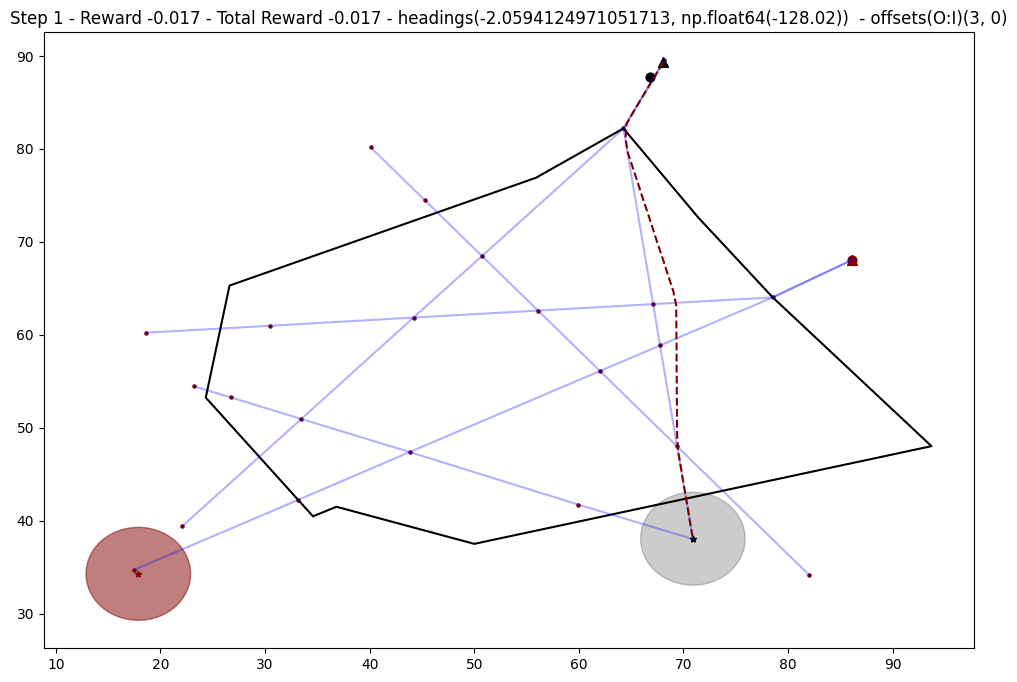

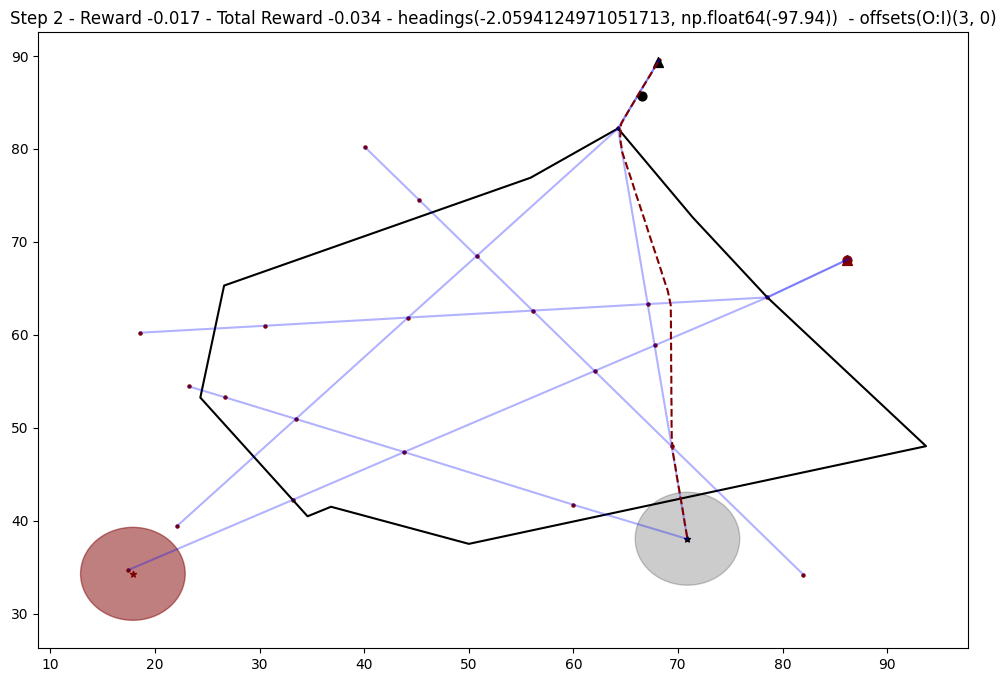

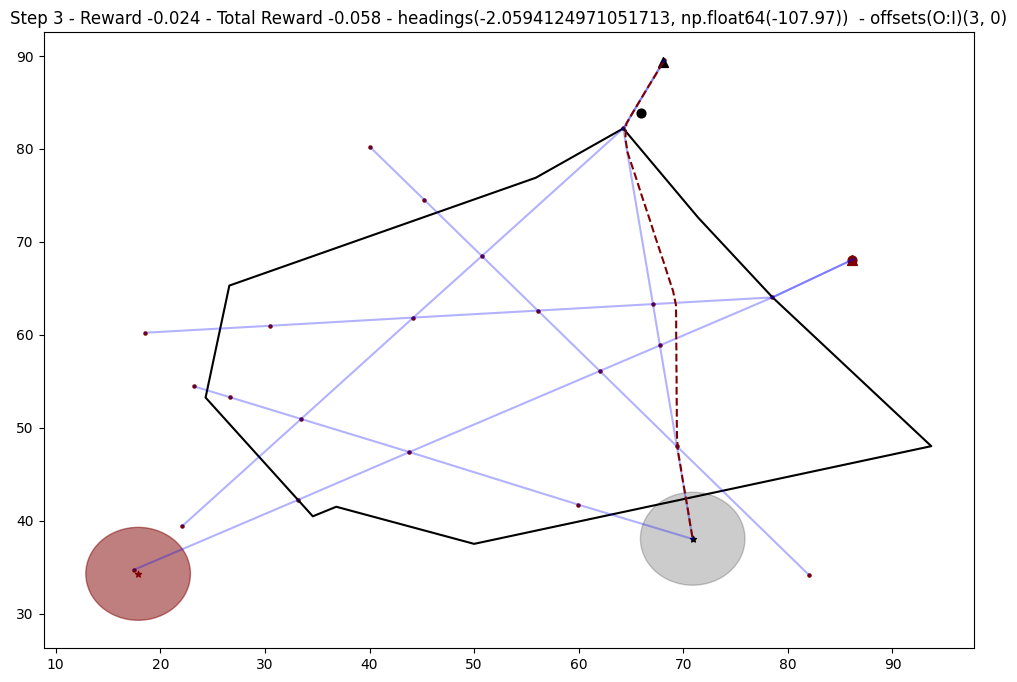

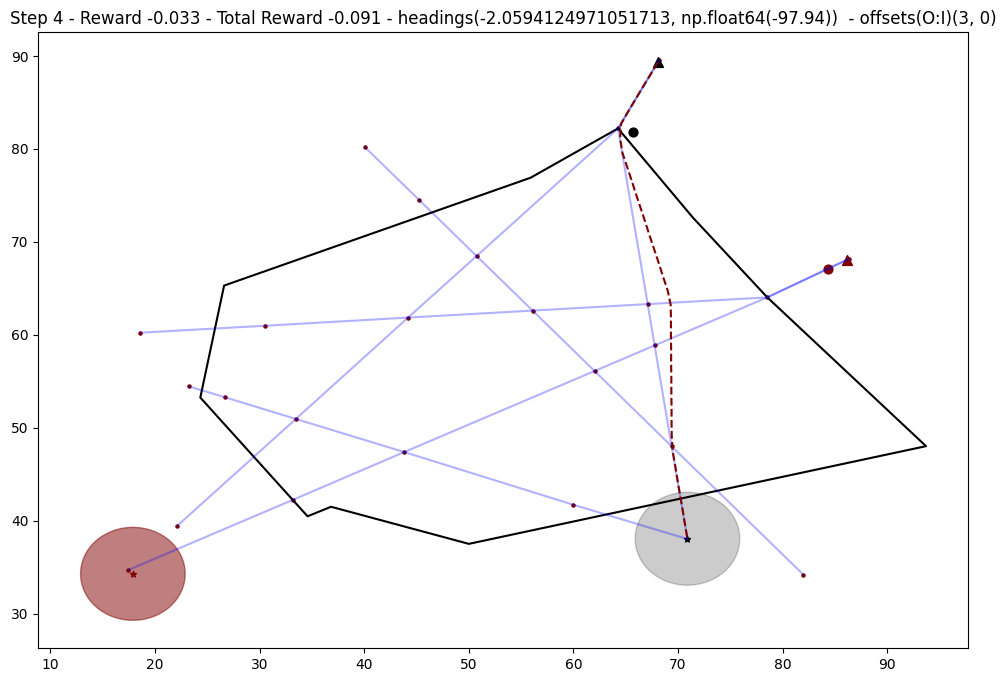

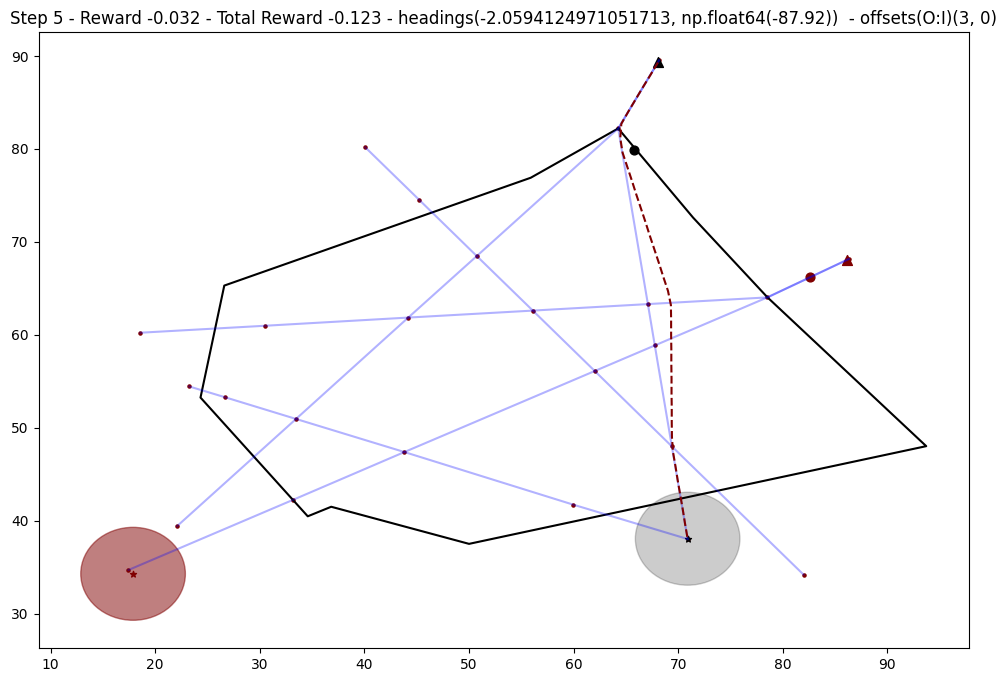

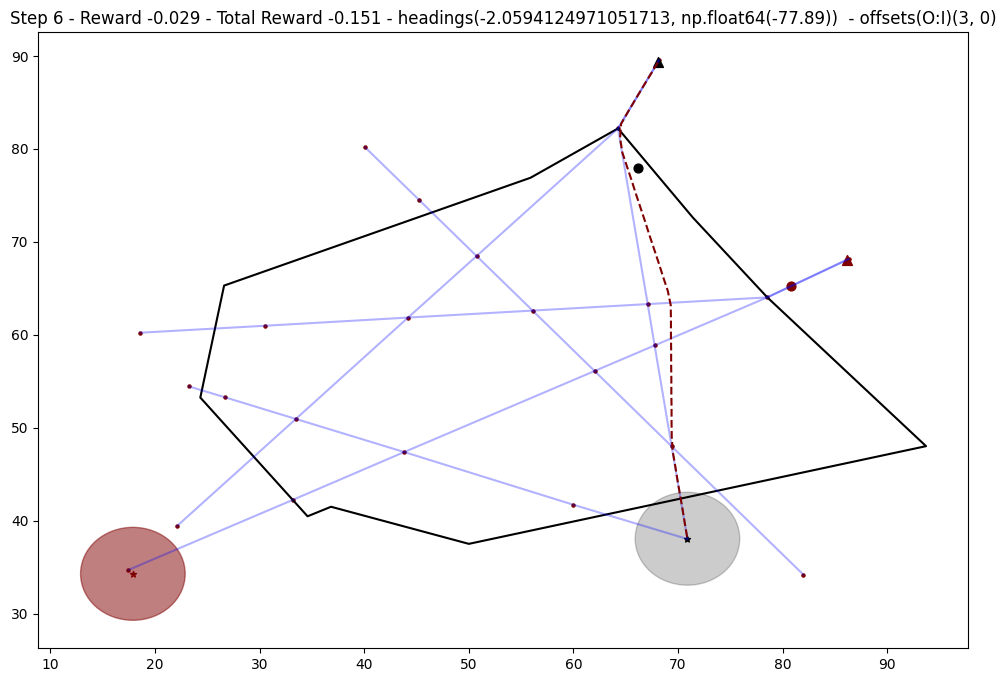

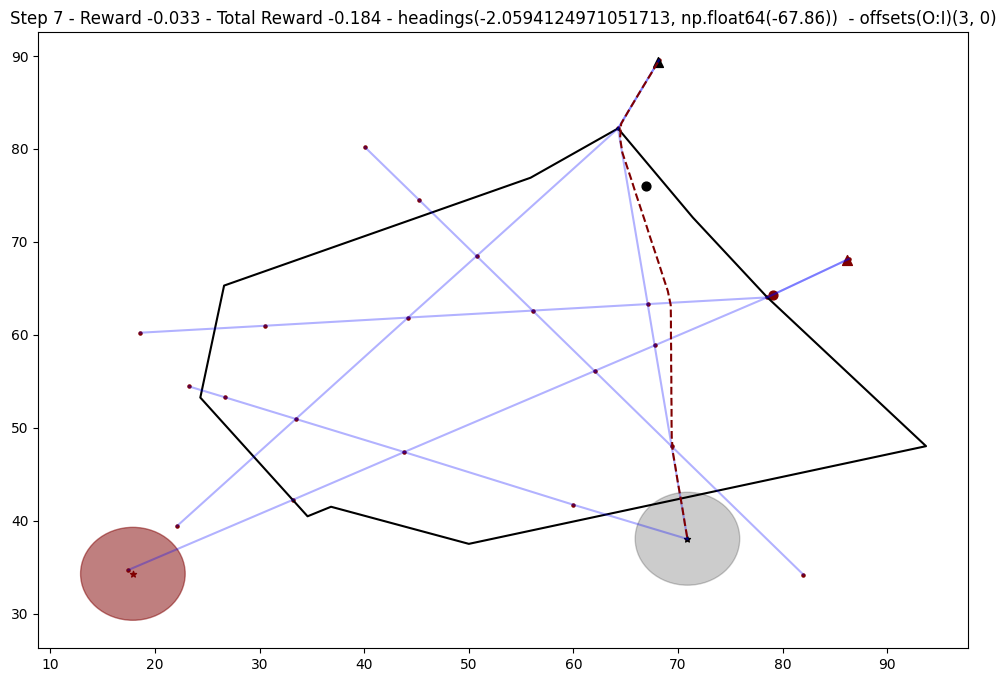

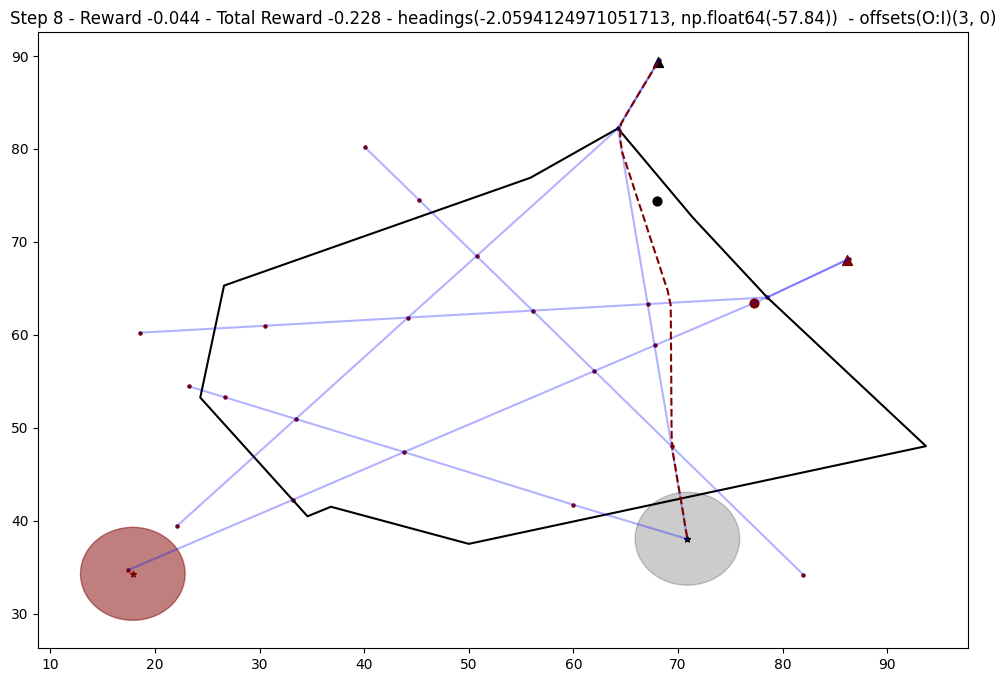

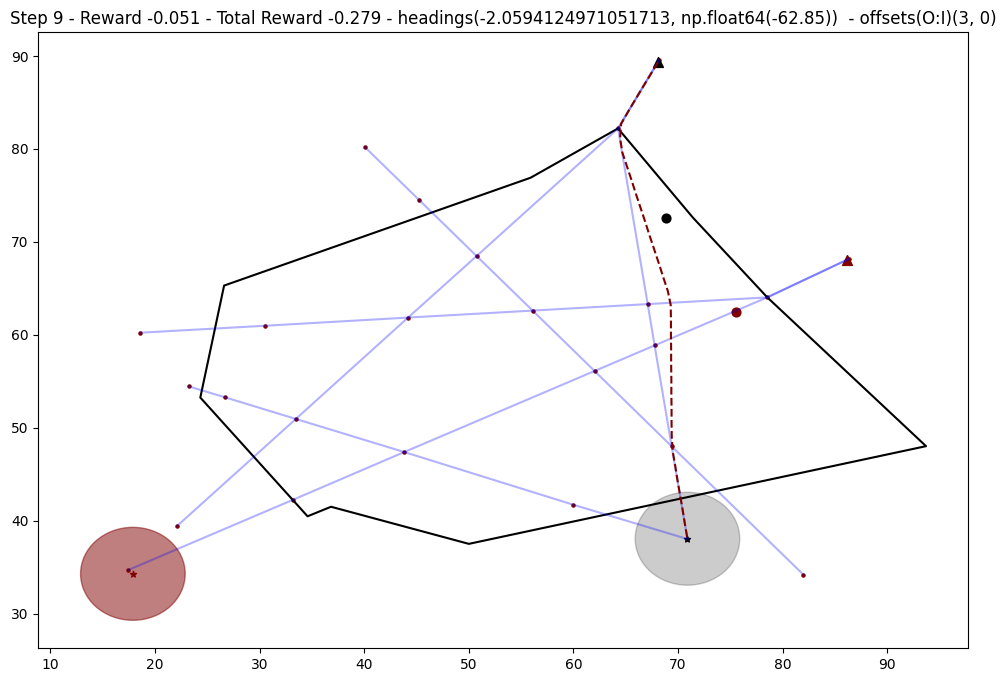

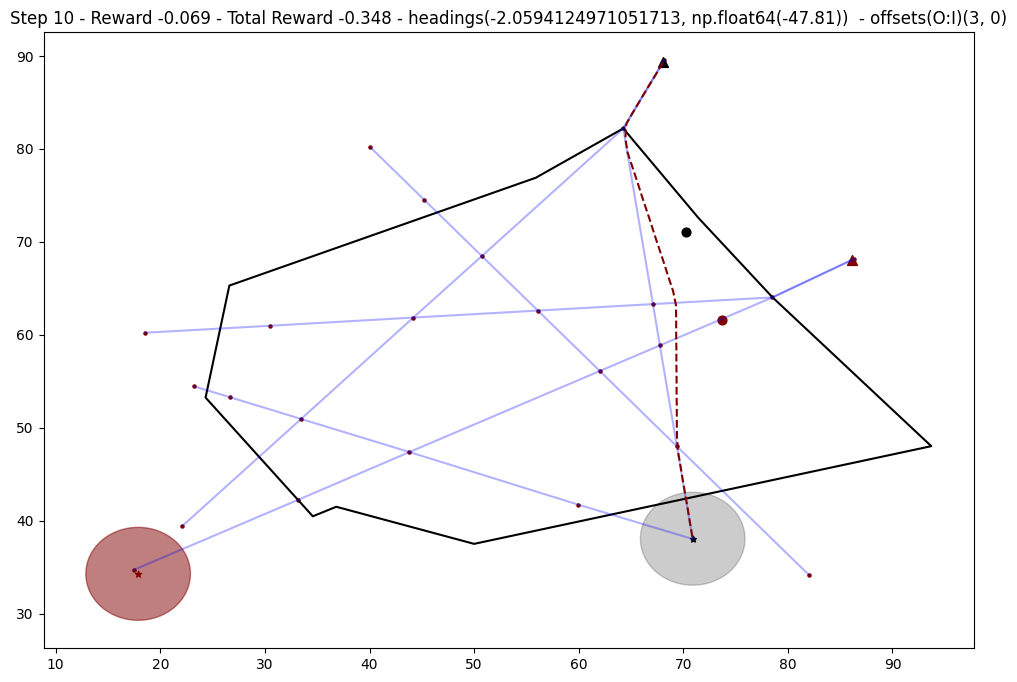

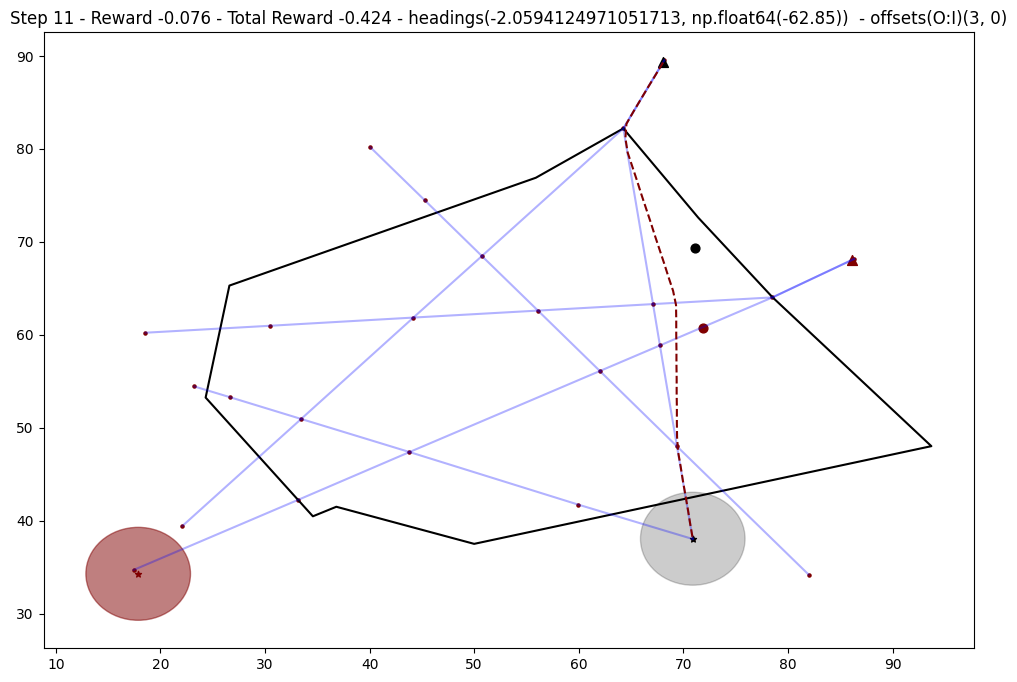

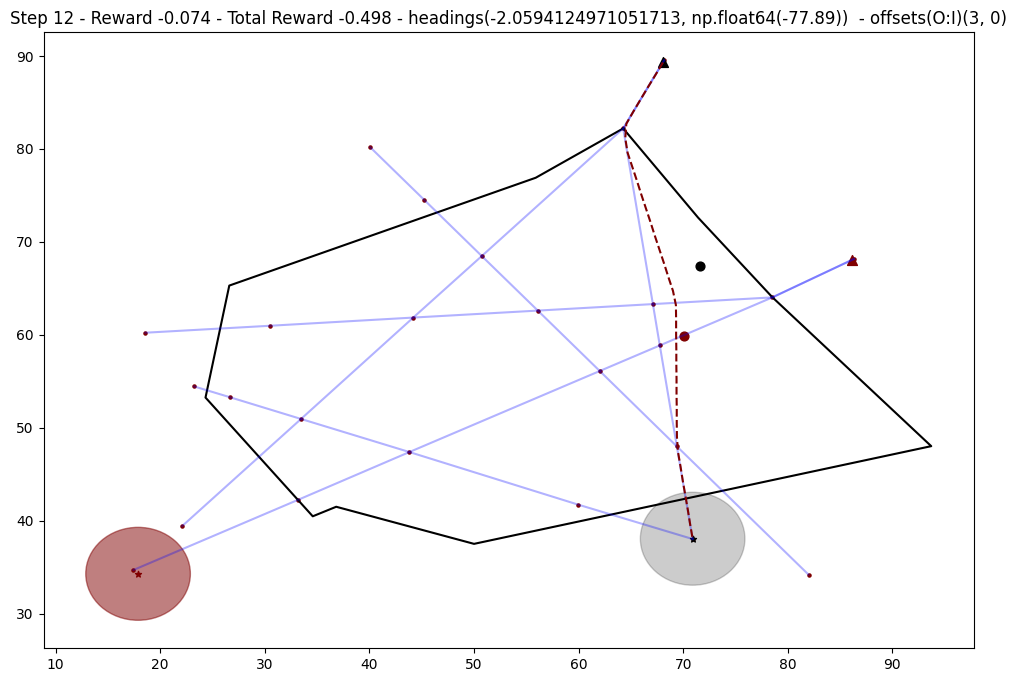

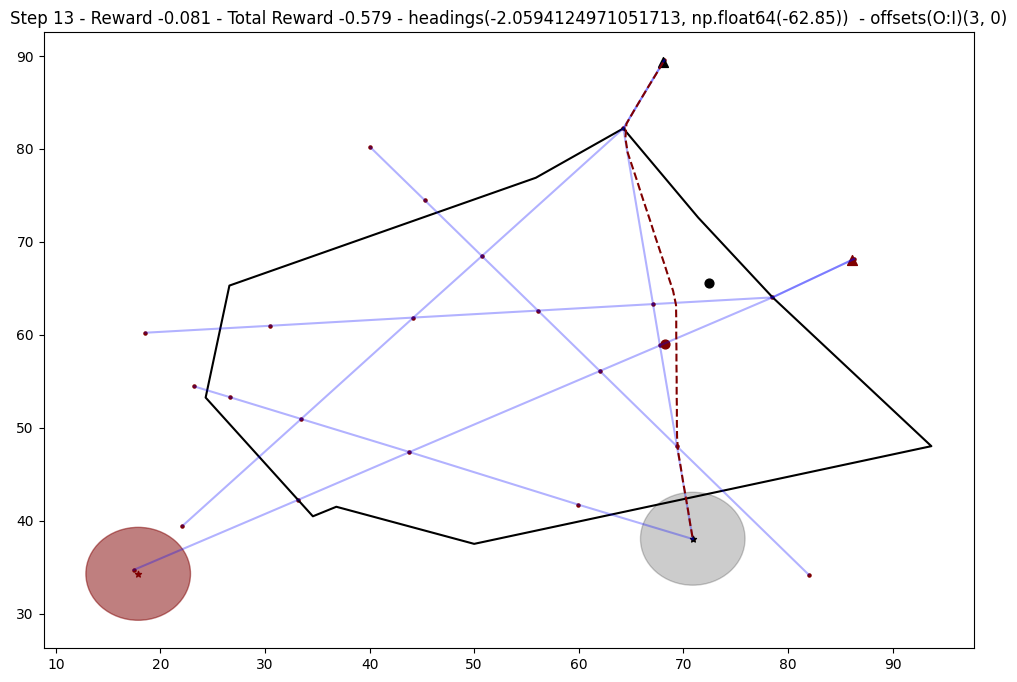

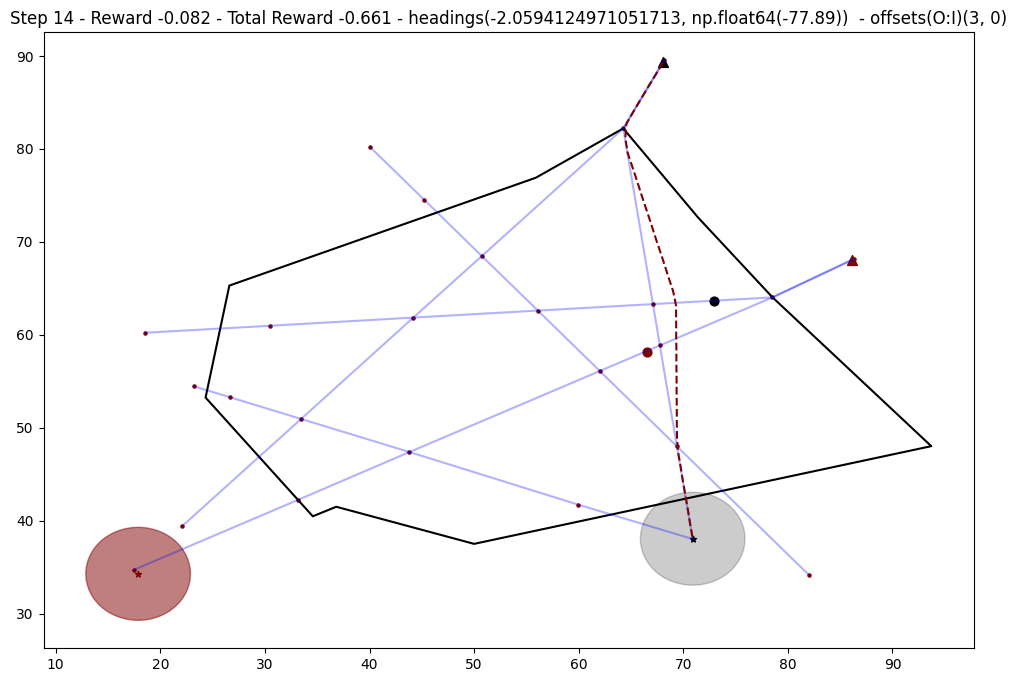

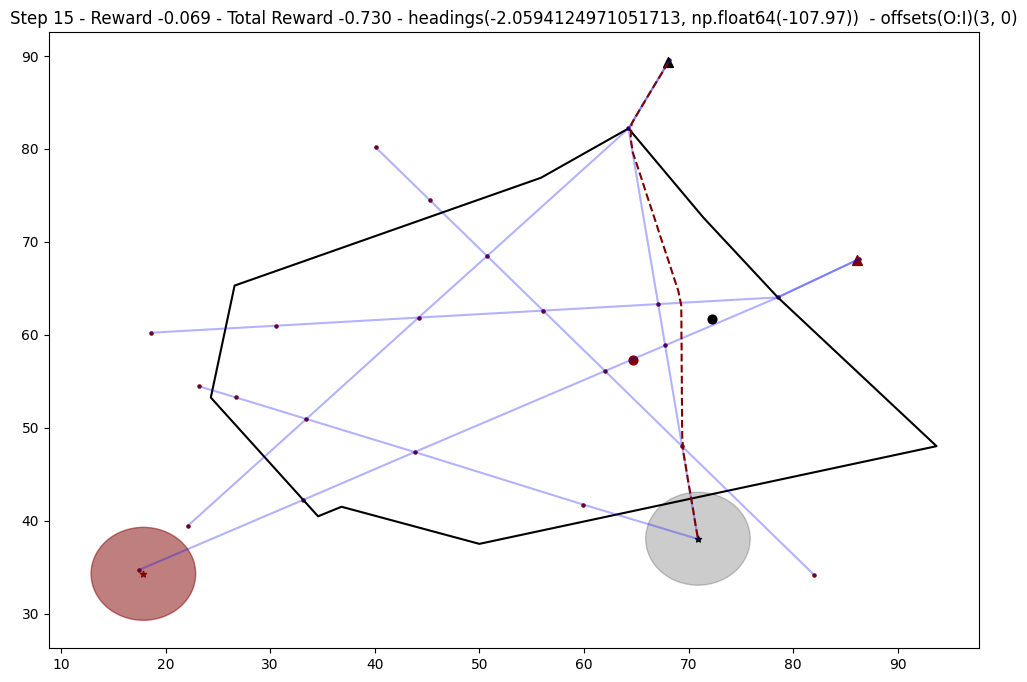

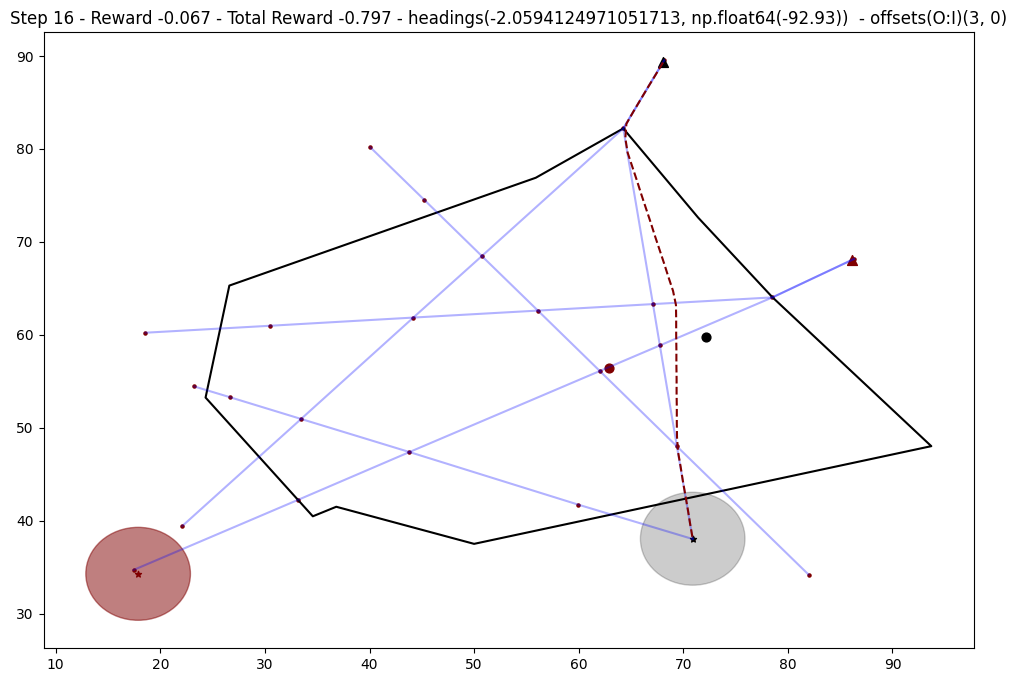

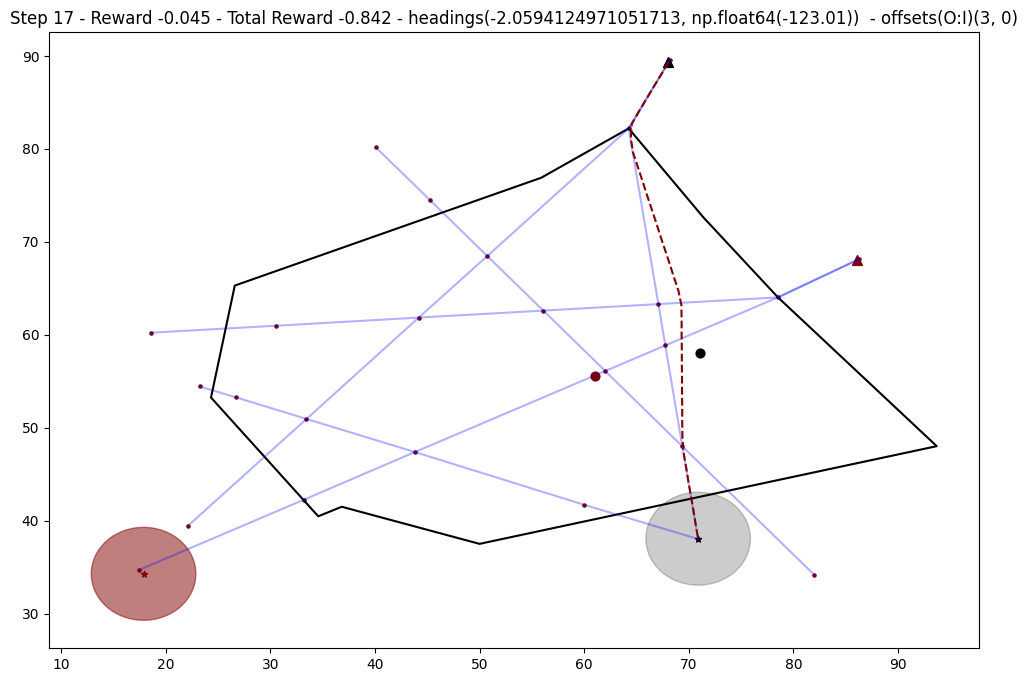

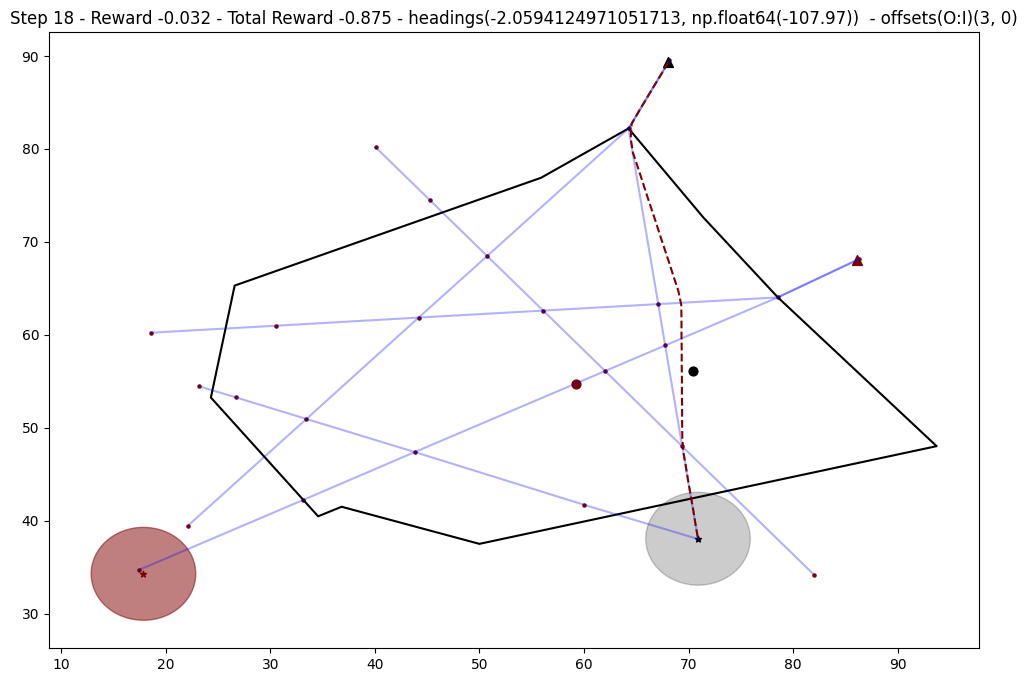

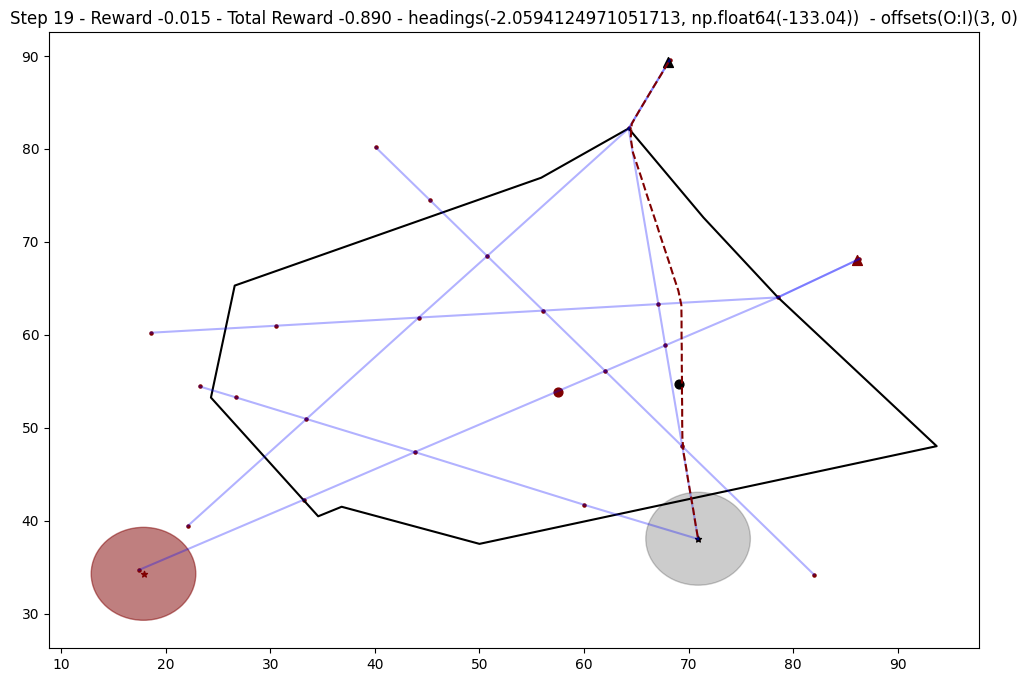

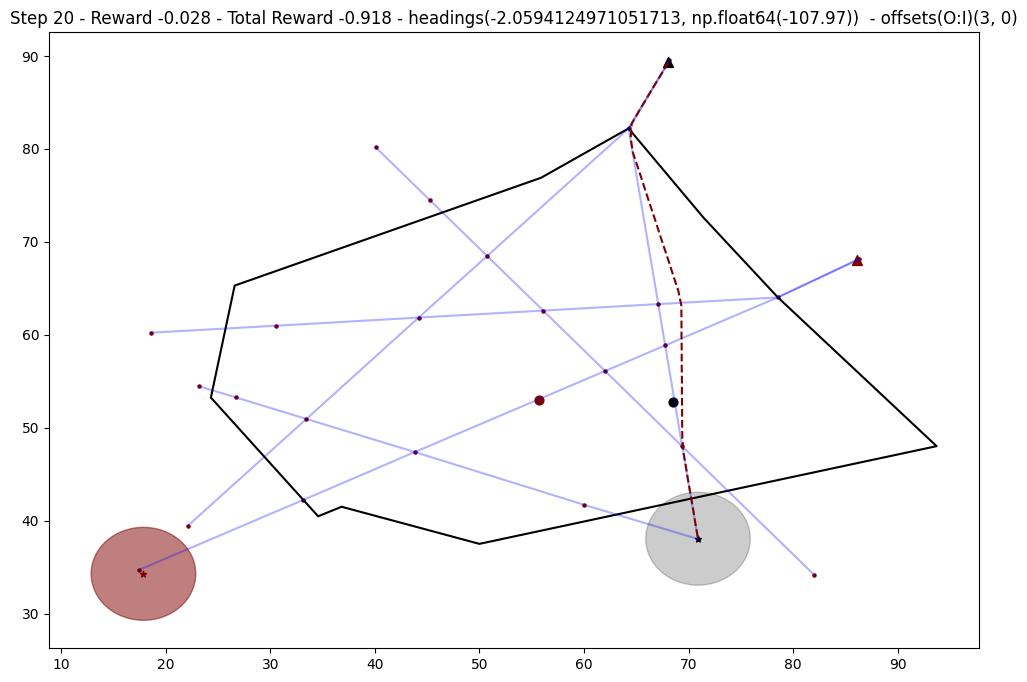

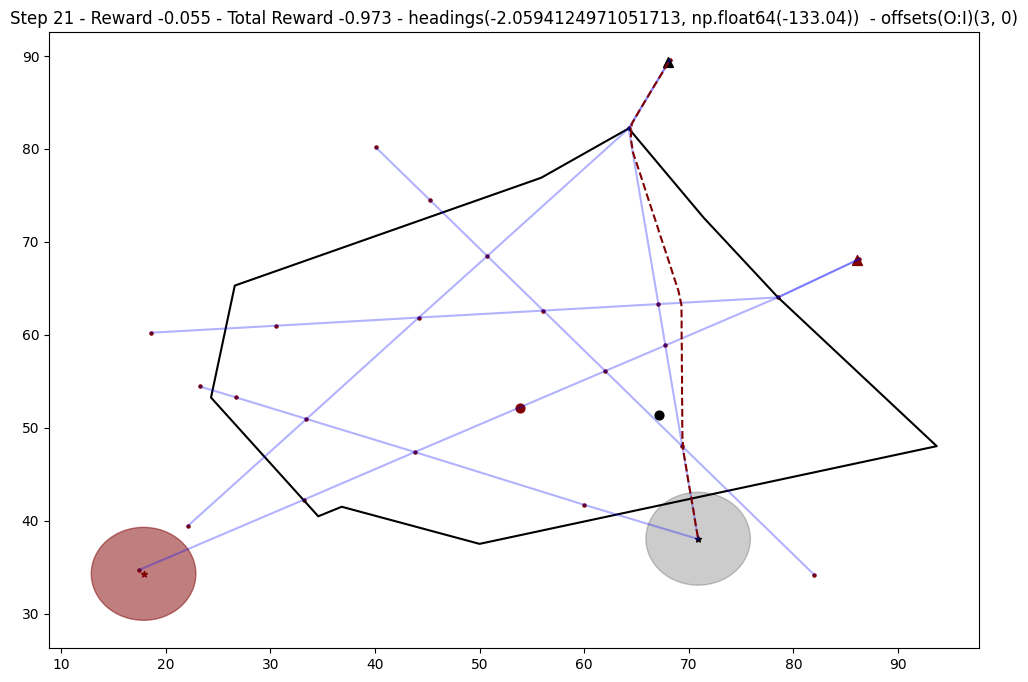

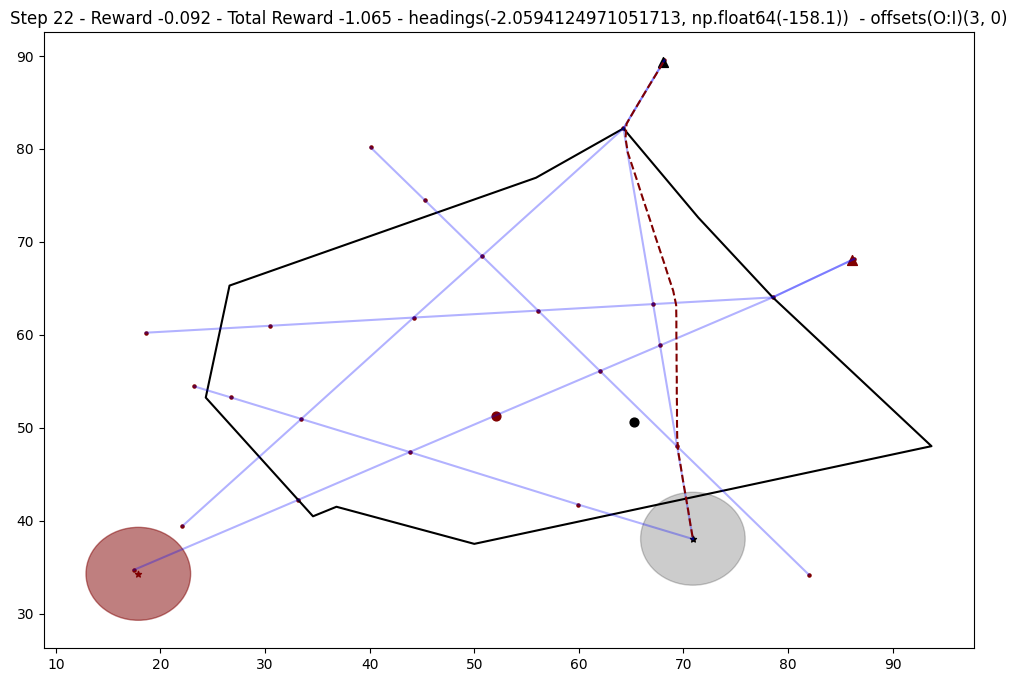

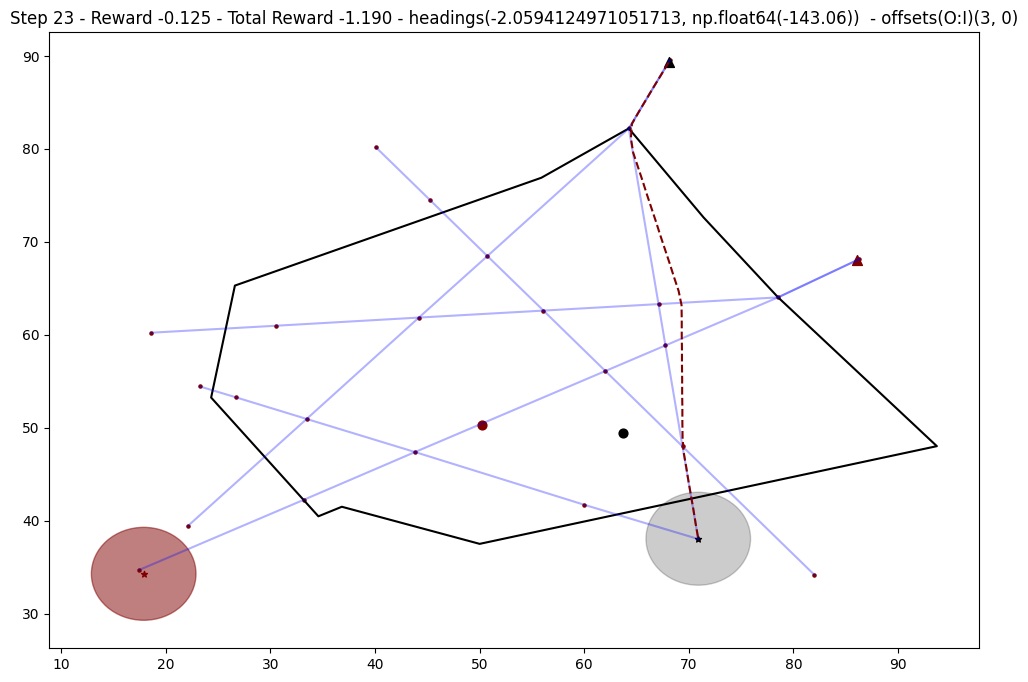

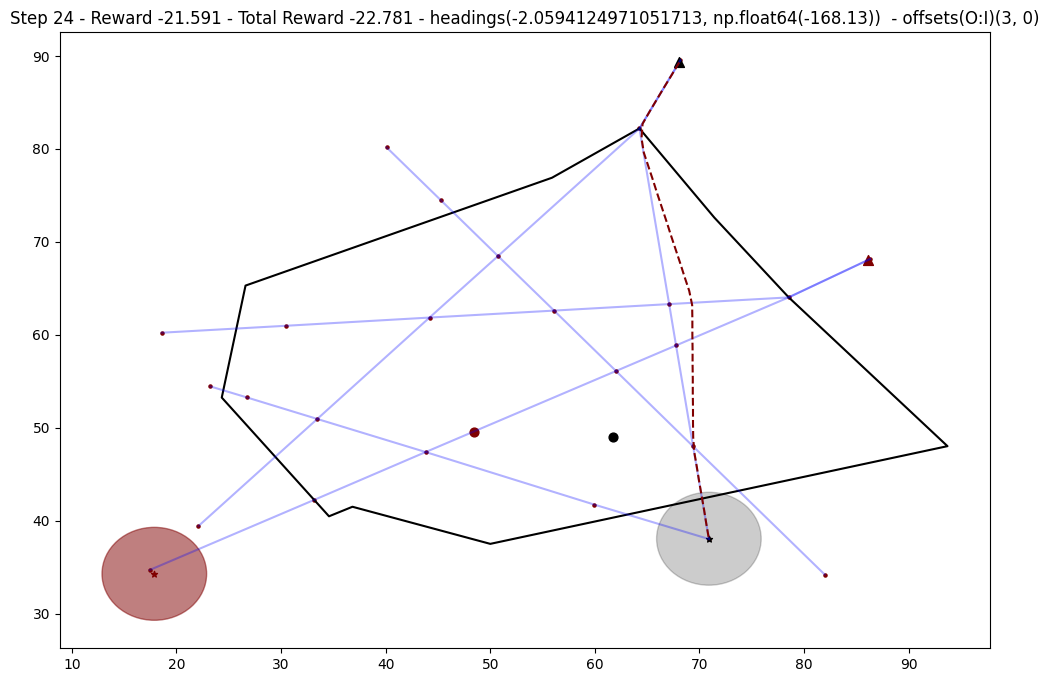

In [ ]:
import os, glob
from PIL import Image
import torch
import numpy as np
import gymnasium as gym
from gymnasium import spaces

# --- If you don't already have 'device' defined in your notebook, uncomment:
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

KEEP_IDX_12 = tuple(range(12))

class ObsSliceWrapper(gym.ObservationWrapper):
    """Keep only the given indices from the observation vector."""
    def __init__(self, env, keep_idx=KEEP_IDX_12):
        super().__init__(env)
        self.keep_idx = np.array(keep_idx, dtype=int)
        low  = env.observation_space.low[self.keep_idx]
        high = env.observation_space.high[self.keep_idx]
        self.observation_space = spaces.Box(low=low, high=high, dtype=np.float64)
    def observation(self, obs):
        return obs[self.keep_idx]

def infer_input_dim_from_ckpt(path: str) -> int:
    """Return the input dimension expected by the checkpoint (12 or 17)."""
    sd = torch.load(path, map_location='cpu')
    w = sd.get("net.0.weight", None)
    if w is not None and w.ndim == 2:
        return int(w.shape[1])  # columns = input dim
    # Fallback guess: newer models are 17
    return 17

def safe_load_policy(agent, path: str):
    """Load whatever matches; ignore extra/missing keys (e.g., intent_proj/attn)."""
    sd  = torch.load(path, map_location=device)
    cur = agent.policy_old.state_dict()
    filt = {k: v for k, v in sd.items() if k in cur and cur[k].shape == v.shape}
    agent.policy_old.load_state_dict({**cur, **filt}, strict=True)
    agent.policy.load_state_dict(agent.policy_old.state_dict())
    missed = [k for k in cur.keys() if k not in filt]
    extra  = [k for k in sd.keys()  if k not in cur]
    if missed:
        print(f"[load warning] {len(missed)} params not loaded (shape/name mismatch).")
    if extra:
        print(f"[info] {len(extra)} extra keys in checkpoint (ignored).")

def evaluate_ppo_checkpoint(
    best_path: str,
    *,
    start_llm_at_step: int = 0,     # 0 => PPO controls from step 1
    warmup_steps: int = 8000,
    frames_dir: str = "./images_eval",
    gif_name: str = "ppo_eval.gif",
):
    # --- detect input dim from checkpoint ---
    in_dim = infer_input_dim_from_ckpt(best_path)
    print(f"Checkpoint expects state_dim={in_dim}")

    # --- build env (no LLM/autopilot) ---
    env = StructuredEnv(start_llm_at_step=start_llm_at_step)
    action_dim = env.action_space.n

    # --- build PPO with matching input dim ---
    agent = PPO(state_dim=in_dim, action_dim=action_dim,
                lr_actor=3e-4, lr_critic=1e-3,
                gamma=0.99, K_epochs=10, eps_clip=0.2)

    # --- load weights safely ---
    safe_load_policy(agent, best_path)
    print("Loaded checkpoint from", best_path)

    # --- warm up obs normalizer on the right dim ---
    if in_dim == 12:
        env_warm = ObsSliceWrapper(StructuredEnv(start_llm_at_step=0), keep_idx=KEEP_IDX_12)
    else:
        env_warm = StructuredEnv(start_llm_at_step=0)
    warmup_obs_norm(agent, env_warm, steps=warmup_steps)
    print(f"Obs normalizer warmed with {warmup_steps} steps.")

    # --- rollout & render frames ---
    os.makedirs(frames_dir, exist_ok=True)
    for p in glob.glob(os.path.join(frames_dir, "image_*.png")):
        try: os.remove(p)
        except OSError: pass

    obs, _ = env.reset()
    step = 0
    while step < env.MAX_STEP:
        # adapt obs to policy input
        obs_in = obs if in_dim == 17 else obs[:12]
        st = torch.tensor(obs_in, dtype=torch.float32, device=device)
        st = agent._normalize_obs_eval(st)

        with torch.no_grad():
            feats  = agent.policy_old.net(st)
            probs  = agent.policy_old.actor(feats)
            action = torch.argmax(probs, dim=-1).item()  # deterministic

        obs, reward, term, trunc, _ = env.step(int(action))
        env.render(show=False, folder=frames_dir + "/")
        step += 1
        if term or trunc:
            break

    # --- save GIF ---
    frames = sorted(glob.glob(os.path.join(frames_dir, "image_*.png")))
    if not frames:
        print("No frames written — check render folder.")
        return None
    from PIL import Image
    imgs = [Image.open(f) for f in frames]
    out_path = os.path.join(frames_dir, gif_name)
    imgs[0].save(fp=out_path, format="GIF", append_images=imgs[1:],
                 save_all=True, duration=len(imgs)*10, loop=0)
    print("Saved evaluation GIF to", out_path)
    return out_path

best_path_12 = "/home/aradhya.dhruv/rl/behaviour_cloning/LLM enhanced DRL/log/PPO/PPO_v3/best_model.pth"
evaluate_ppo_checkpoint(best_path_12)

# best_path_17 = "/home/aradhya.dhruv/rl/behaviour_cloning/LLM enhanced DRL/log/PPO/PPO_v4/best_model.pth"
# evaluate_ppo_checkpoint(best_path_17)


### Evaluation using the LLM + Standalone PPO once the EXECUTE TURN phase is over

[load warning] 6 params not loaded (shape or name mismatch).
Loaded PPO_V3: /home/aradhya.dhruv/rl/behaviour_cloning/LLM enhanced DRL/log/PPO/PPO_v3/checkpoint_5000000.pth
Obs normalizer warmed with 8000 steps.
/home/aradhya.dhruv/rl/behaviour_cloning/LLM enhanced DRL/LLM-driven RL/Evaluation Frames/frames/image_001.png
/home/aradhya.dhruv/rl/behaviour_cloning/LLM enhanced DRL/LLM-driven RL/Evaluation Frames/frames/image_002.png
/home/aradhya.dhruv/rl/behaviour_cloning/LLM enhanced DRL/LLM-driven RL/Evaluation Frames/frames/image_003.png
/home/aradhya.dhruv/rl/behaviour_cloning/LLM enhanced DRL/LLM-driven RL/Evaluation Frames/frames/image_004.png
/home/aradhya.dhruv/rl/behaviour_cloning/LLM enhanced DRL/LLM-driven RL/Evaluation Frames/frames/image_005.png
/home/aradhya.dhruv/rl/behaviour_cloning/LLM enhanced DRL/LLM-driven RL/Evaluation Frames/frames/image_006.png
/home/aradhya.dhruv/rl/behaviour_cloning/LLM enhanced DRL/LLM-driven RL/Evaluation Frames/frames/image_007.png
/home/aradhy

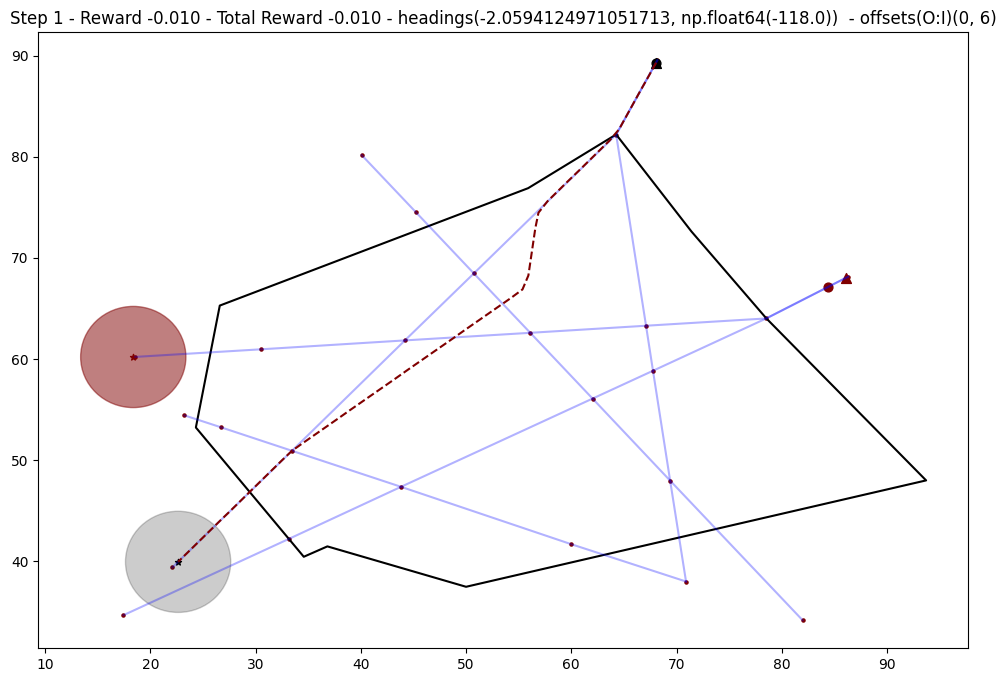

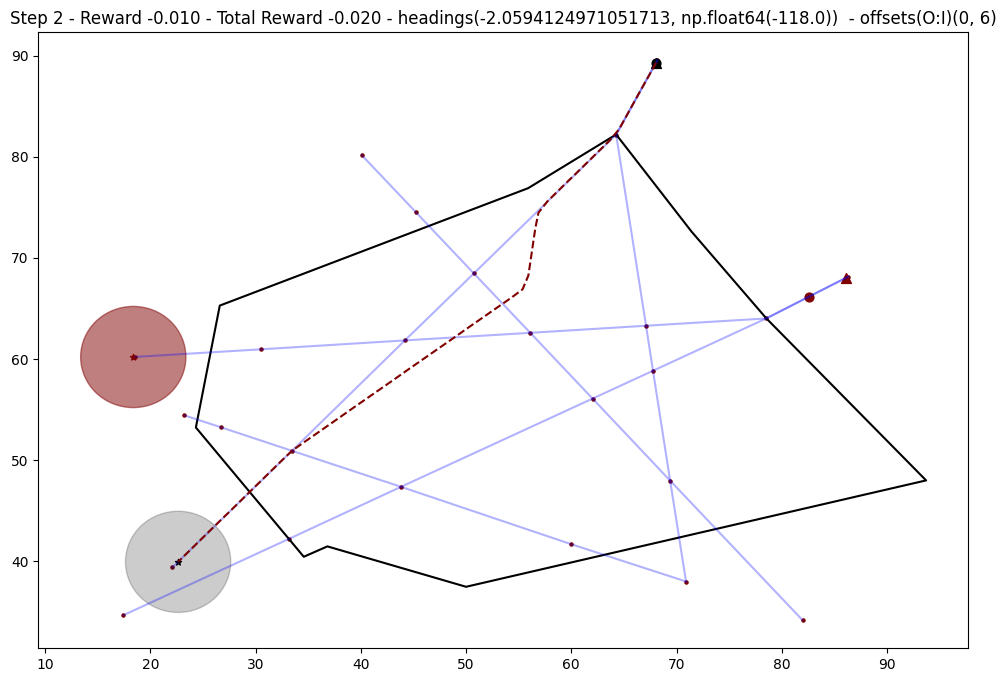

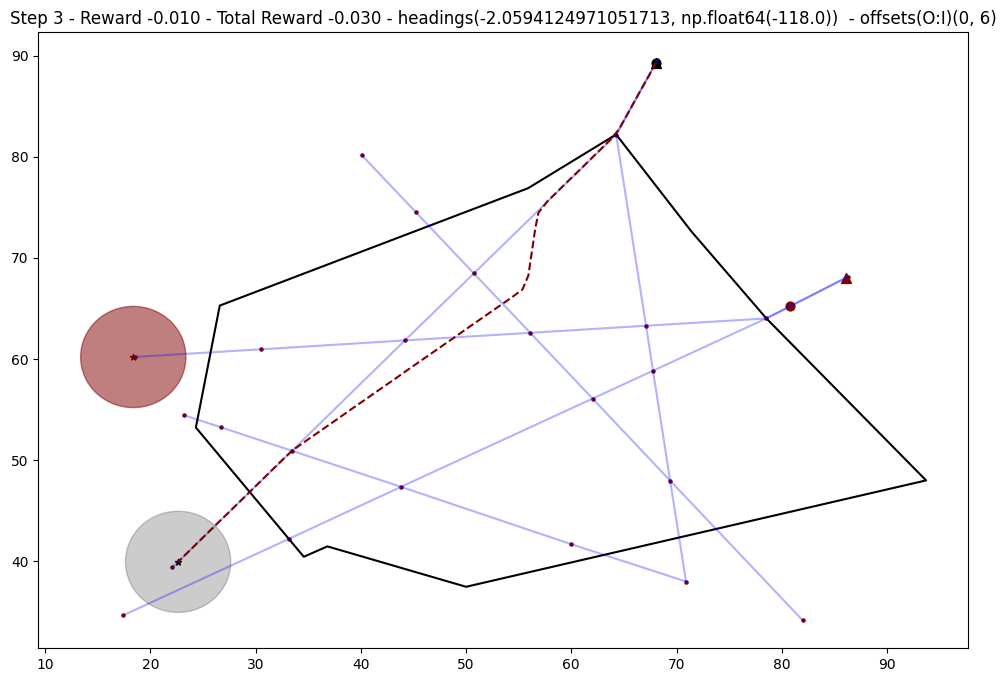

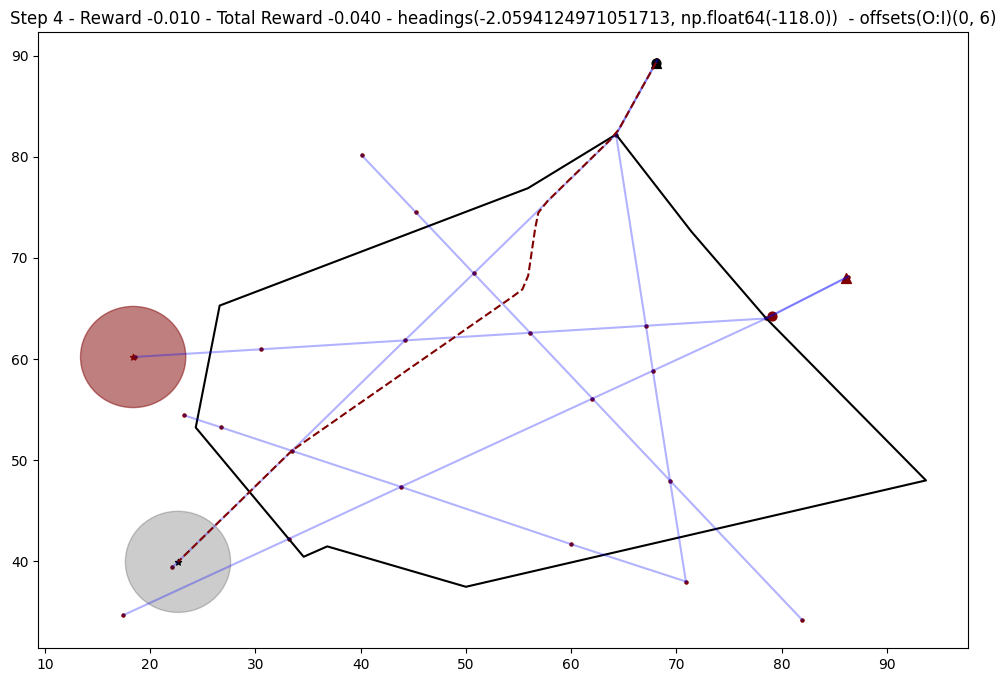

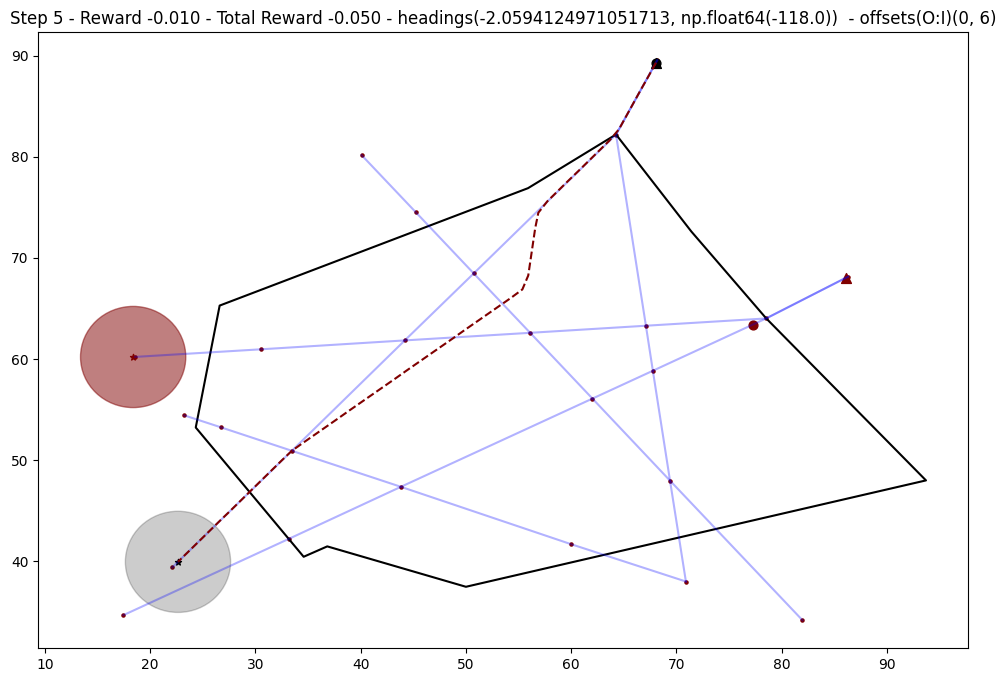

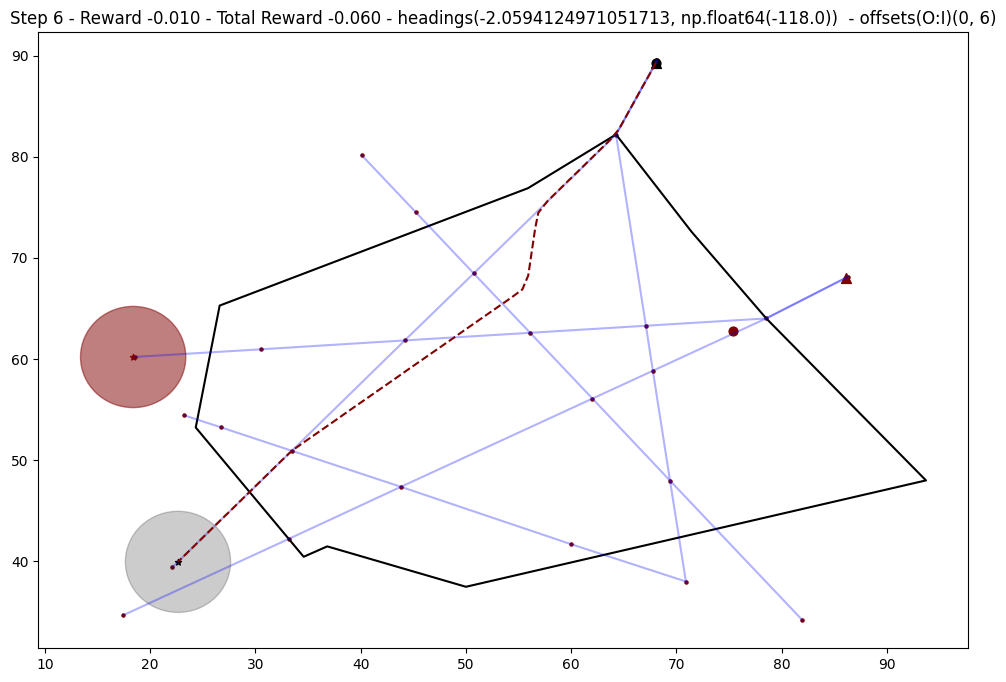

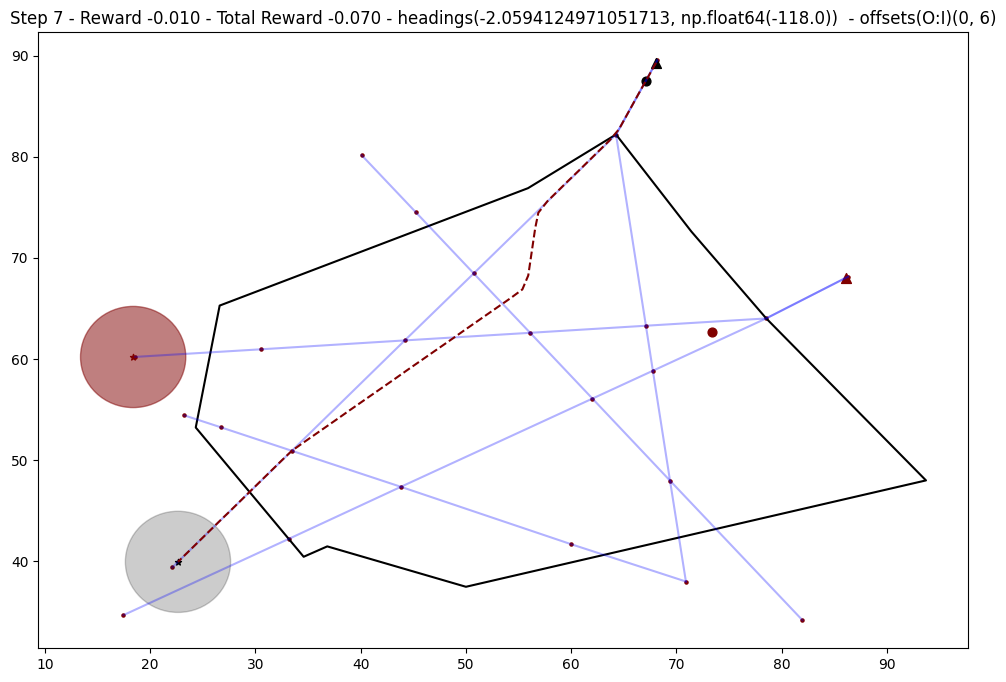

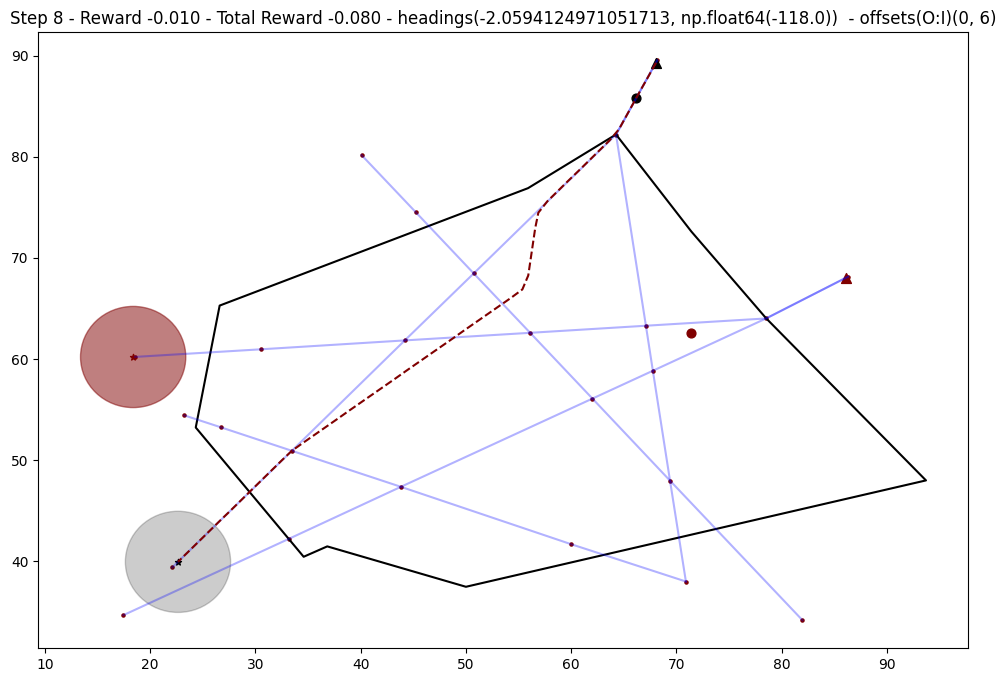

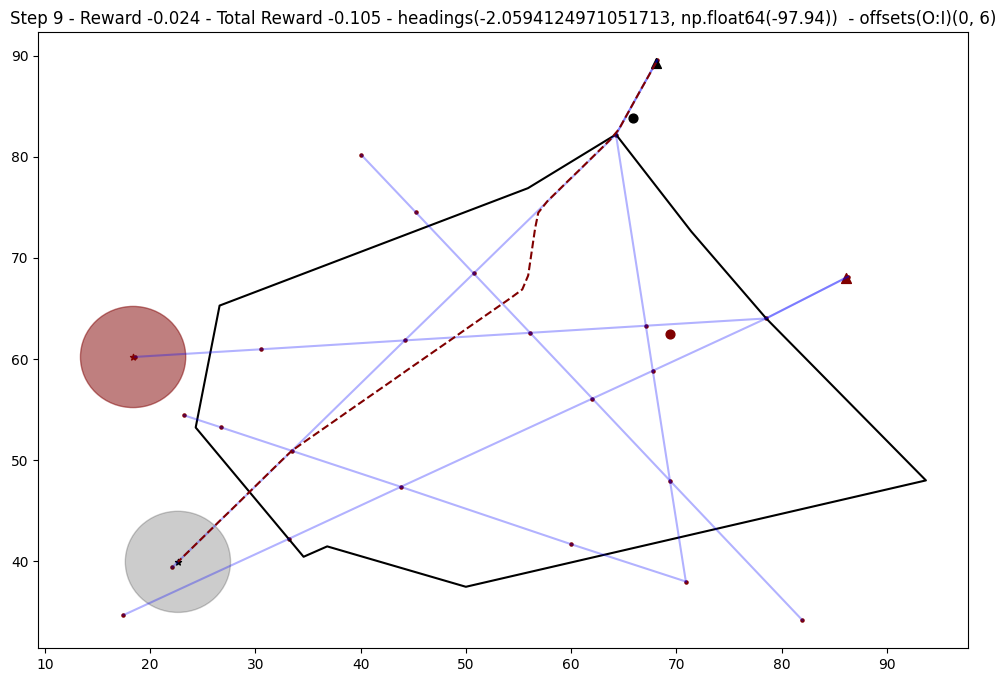

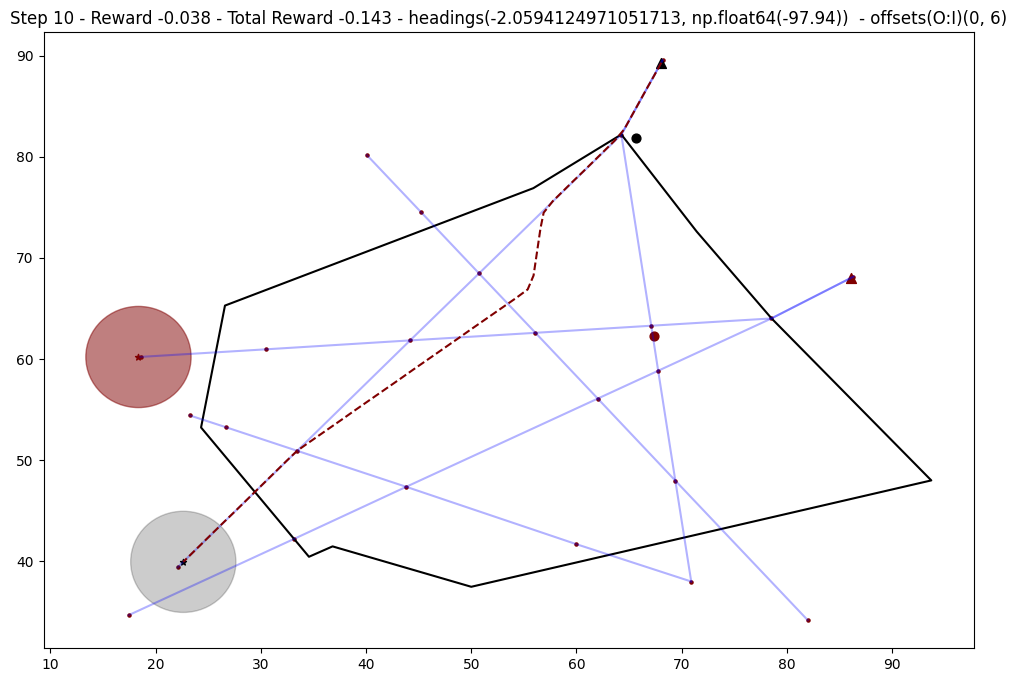

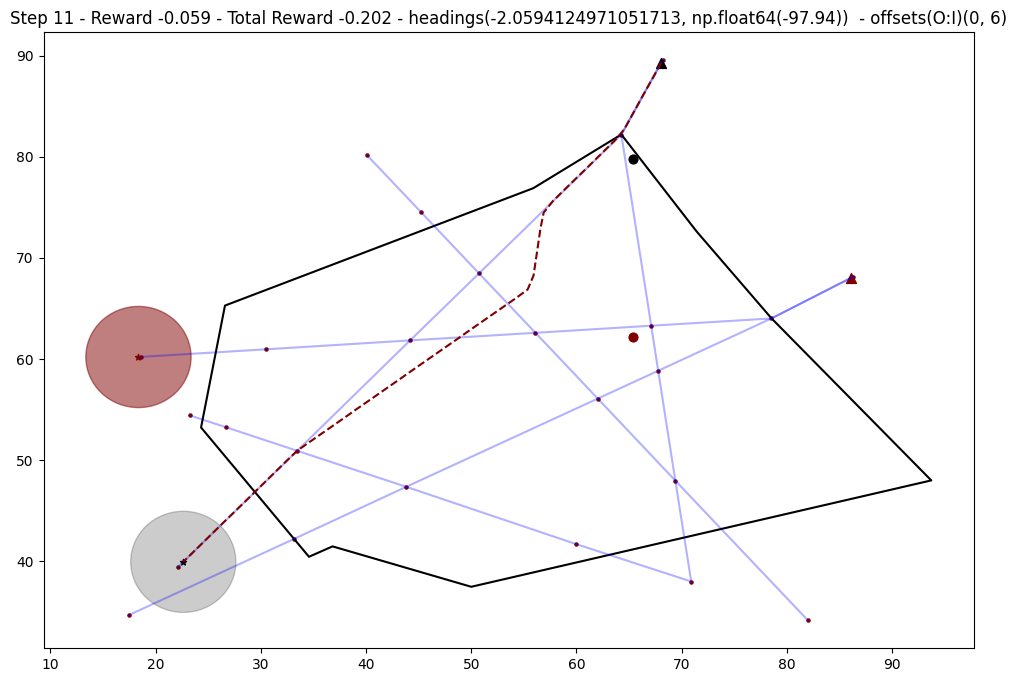

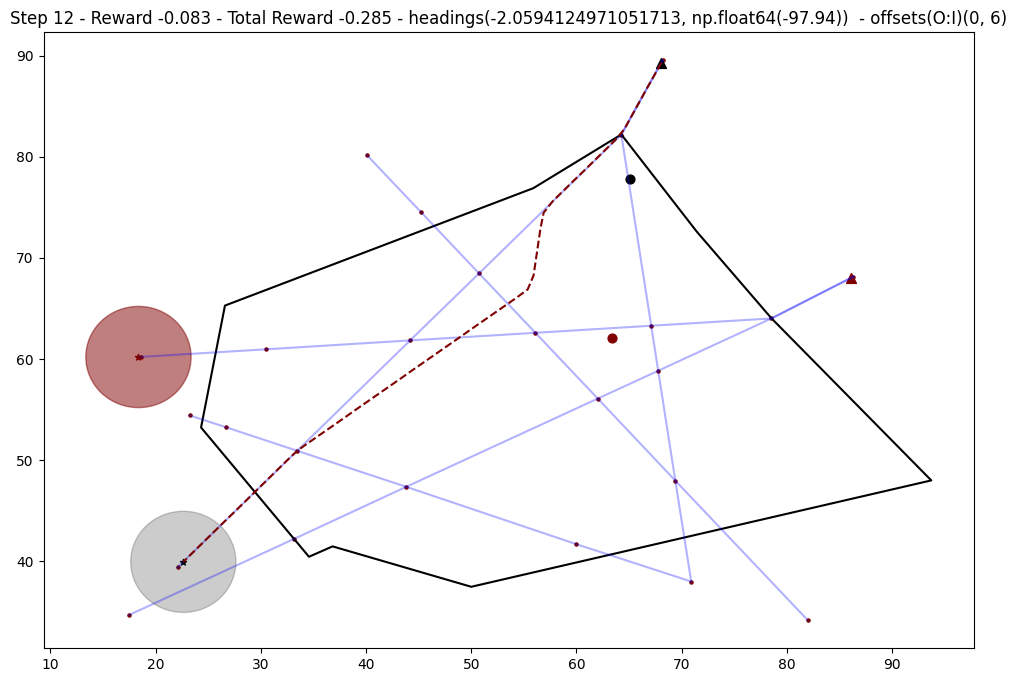

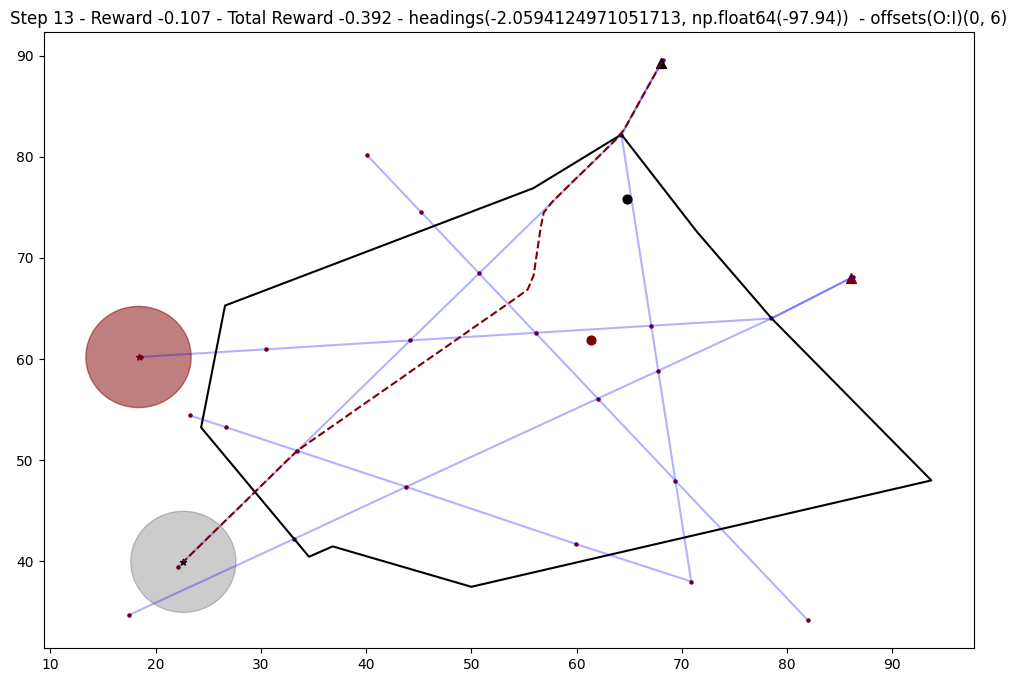

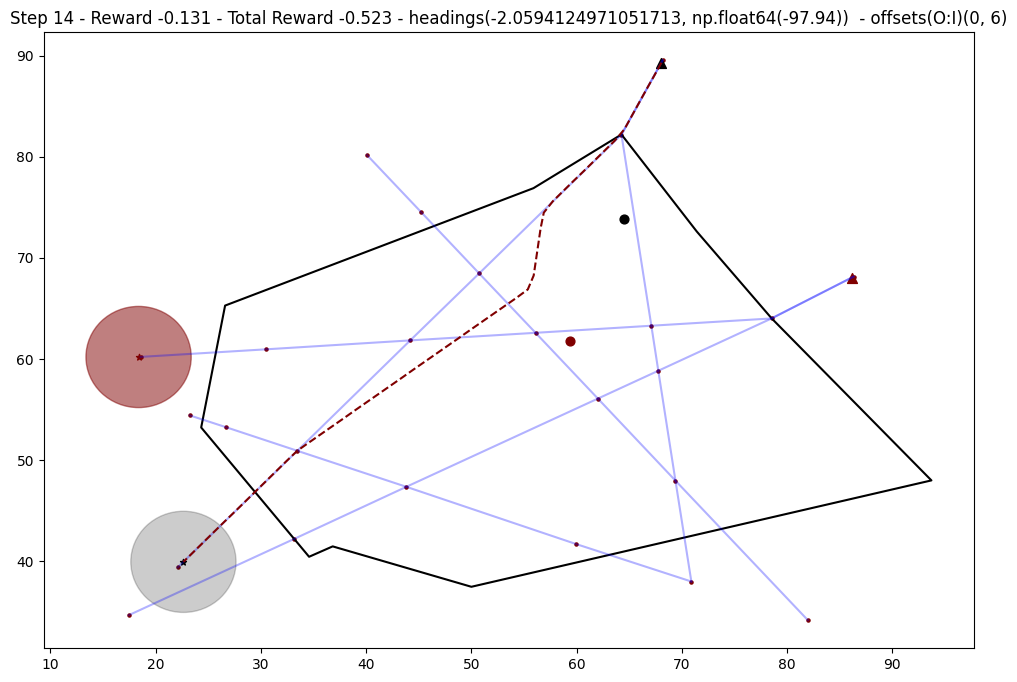

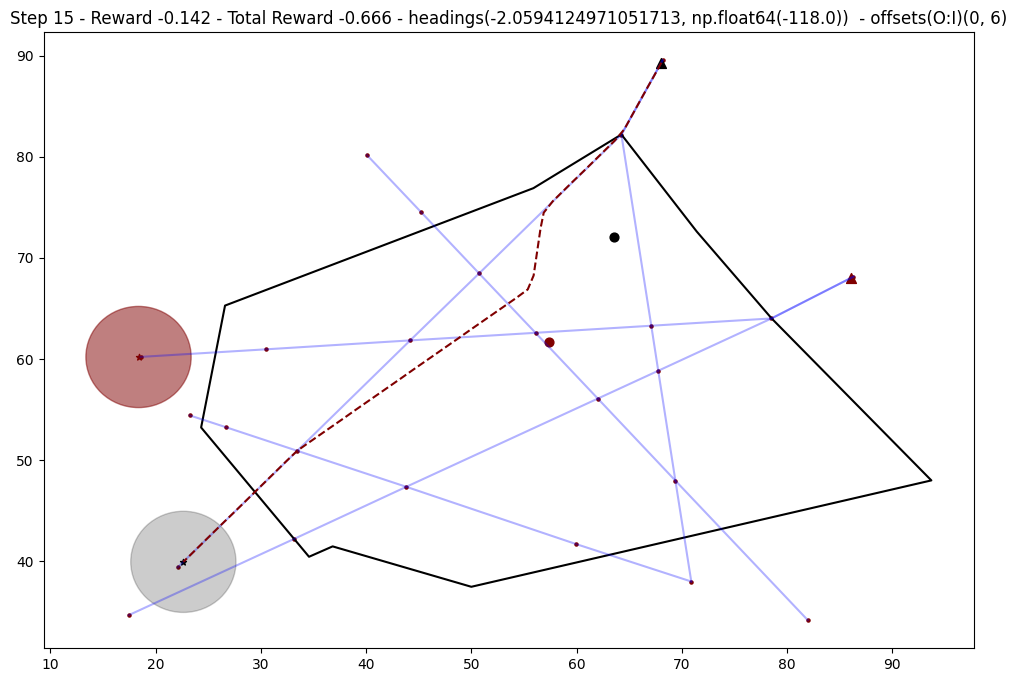

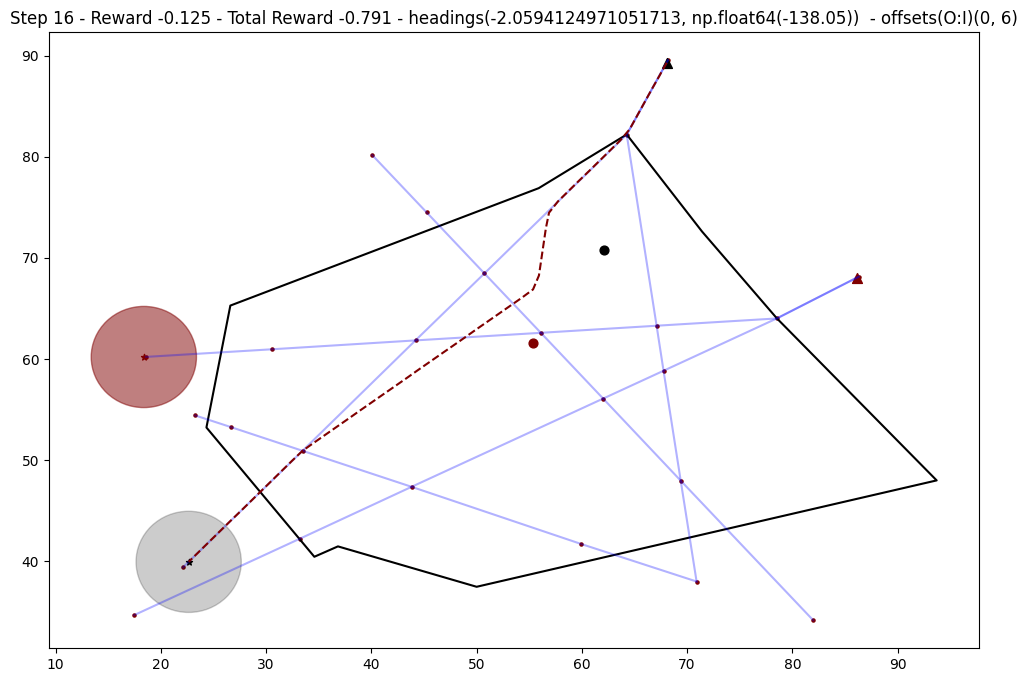

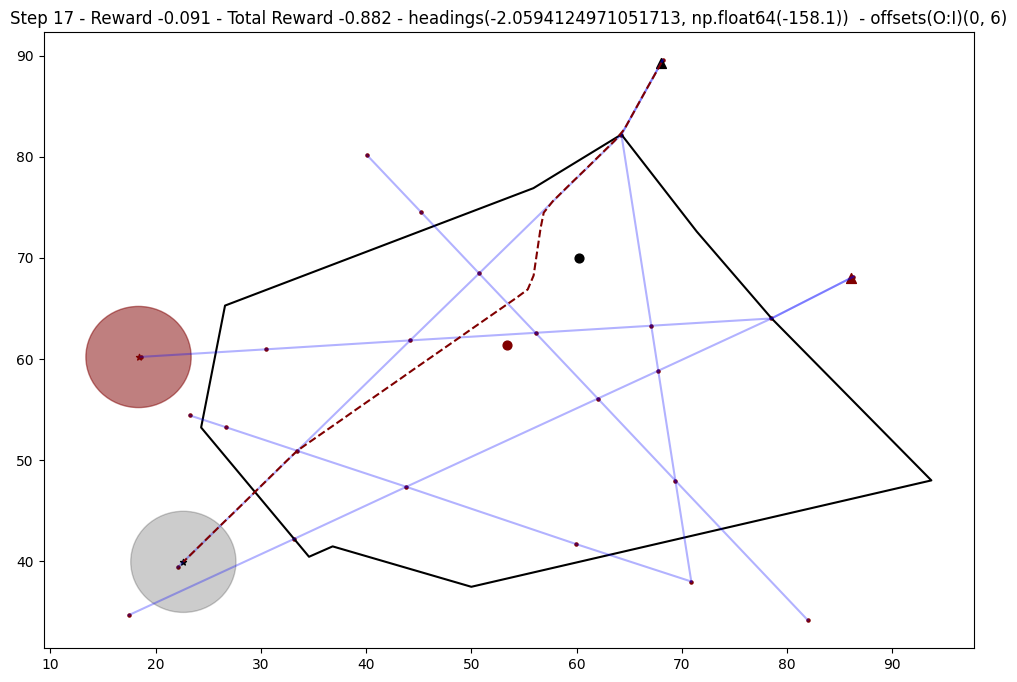

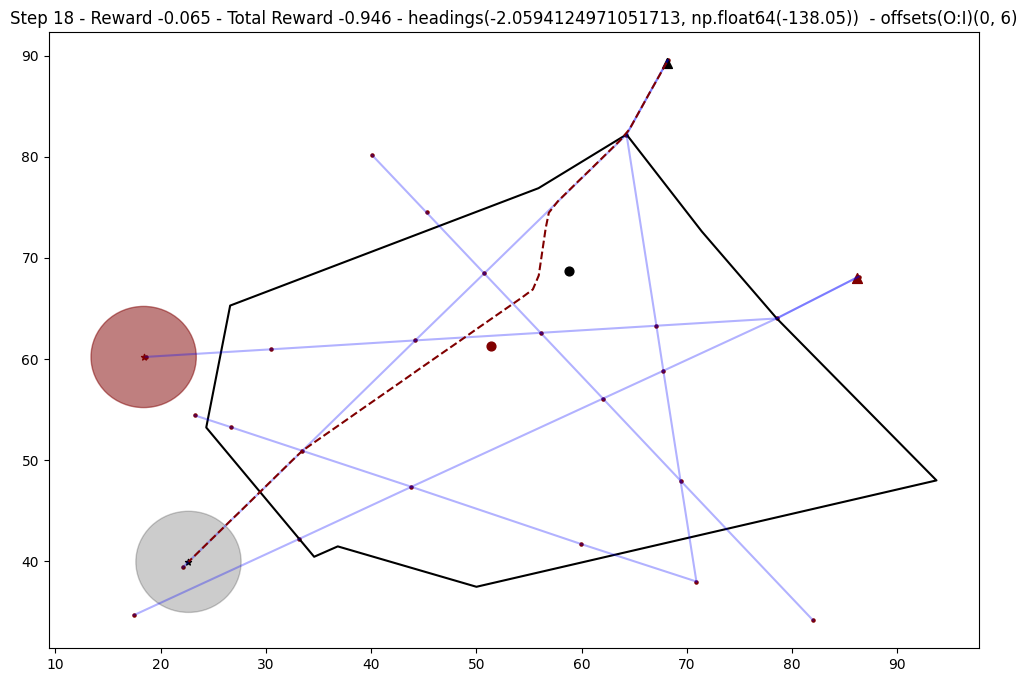

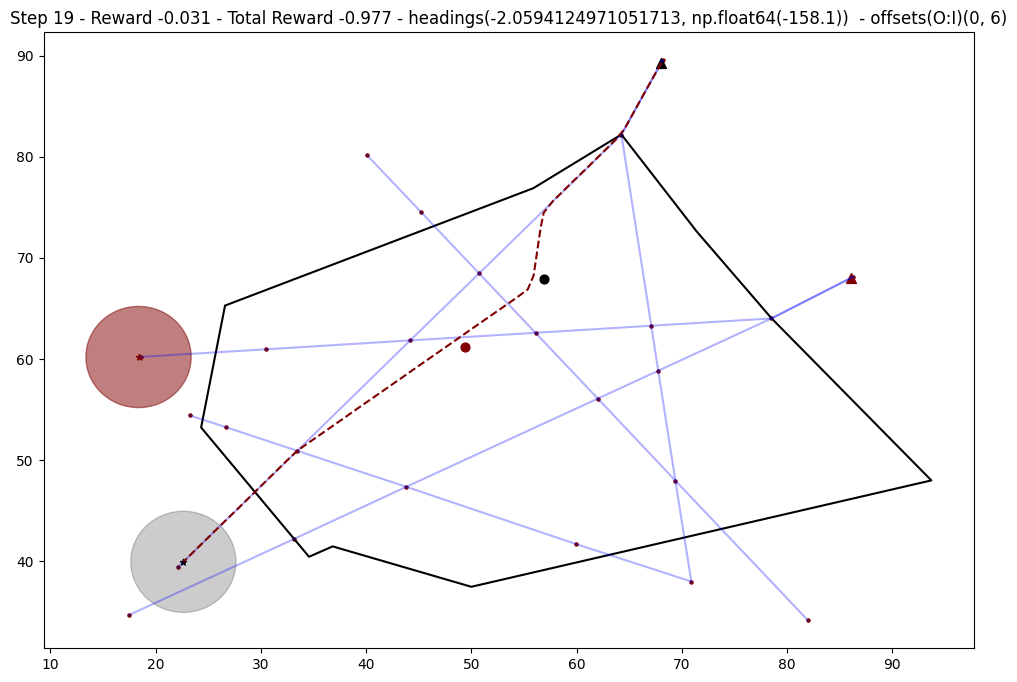

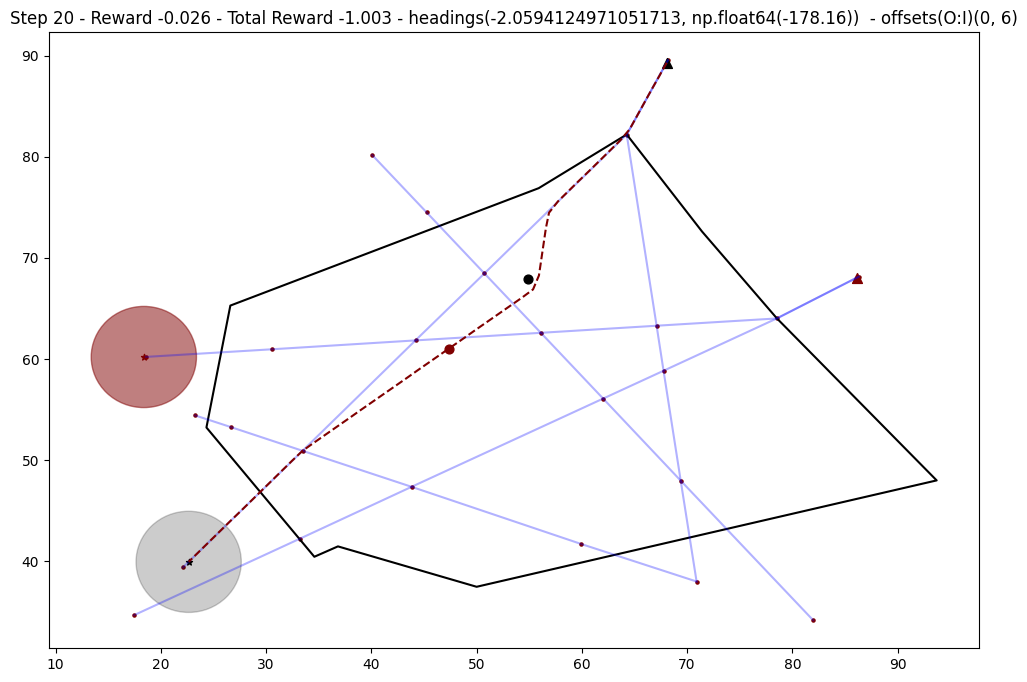

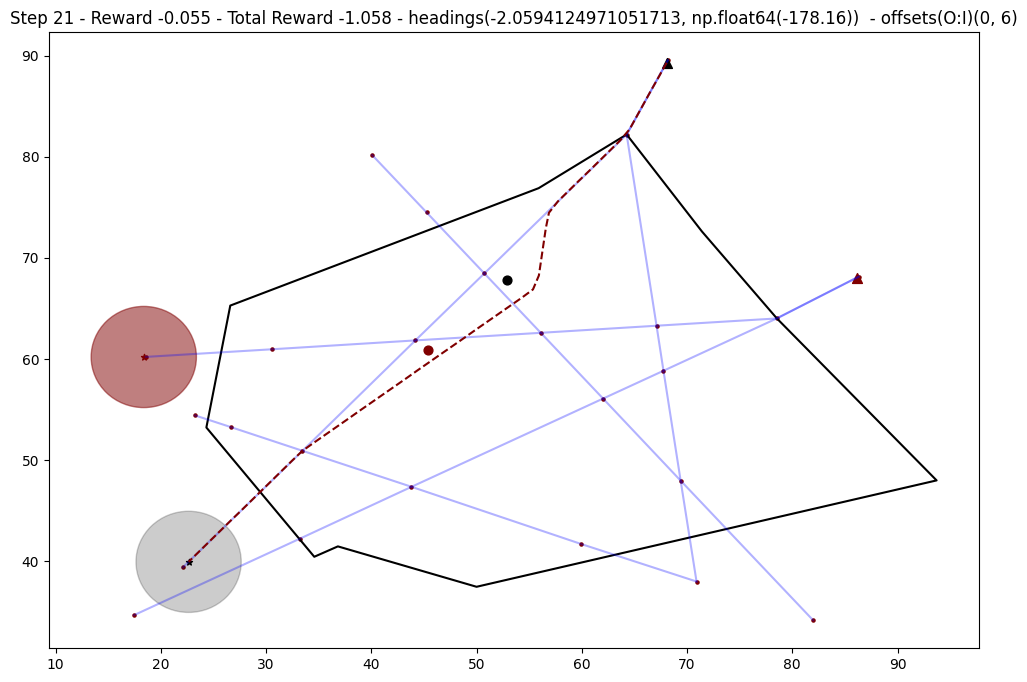

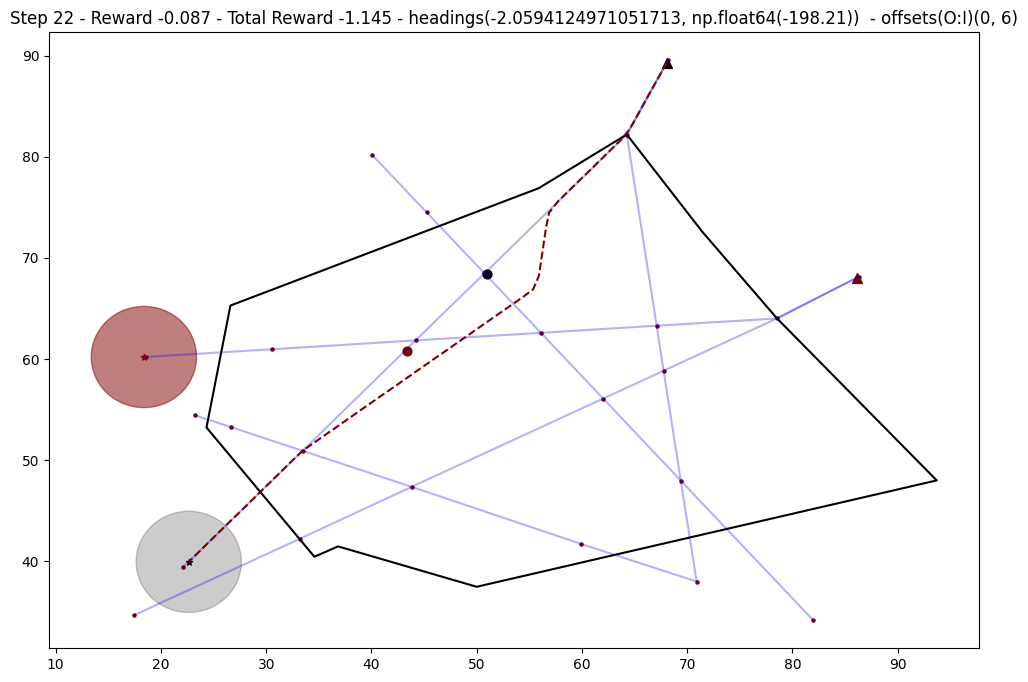

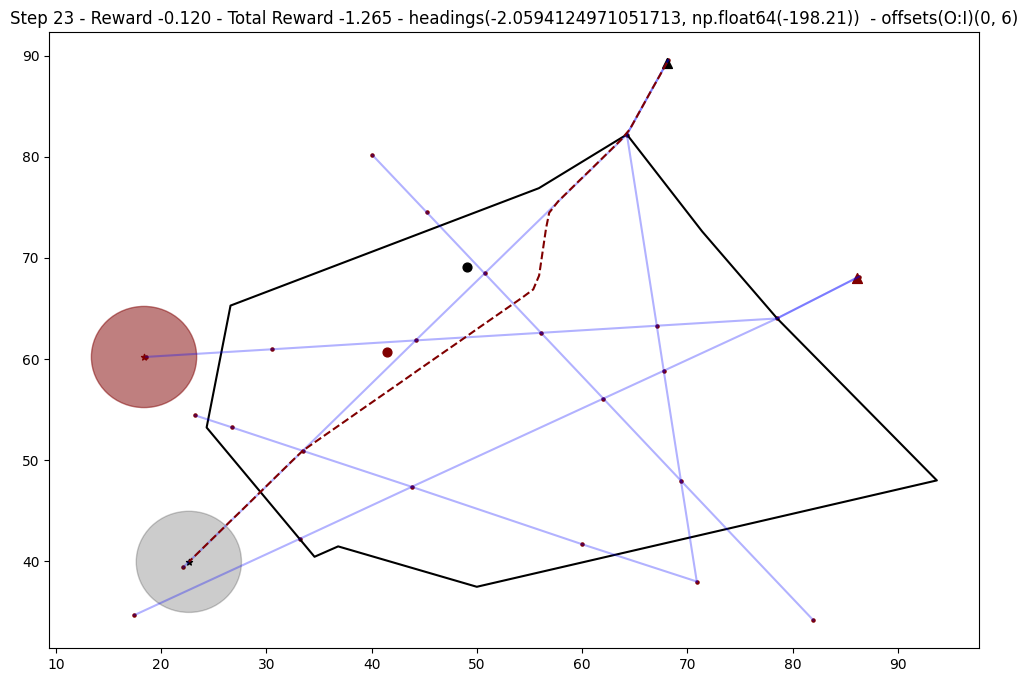

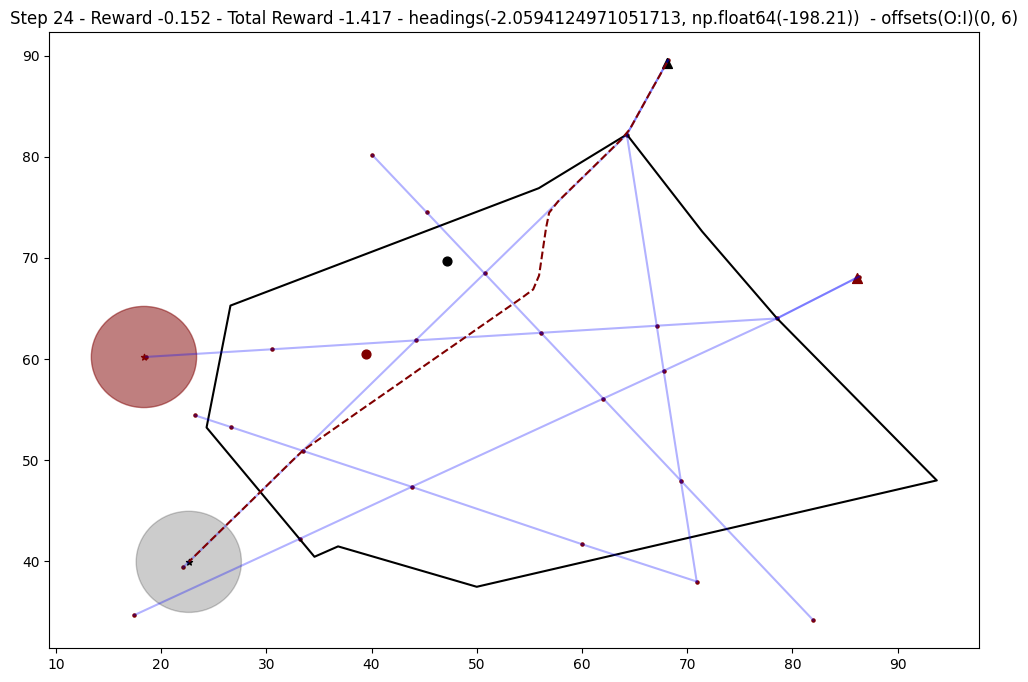

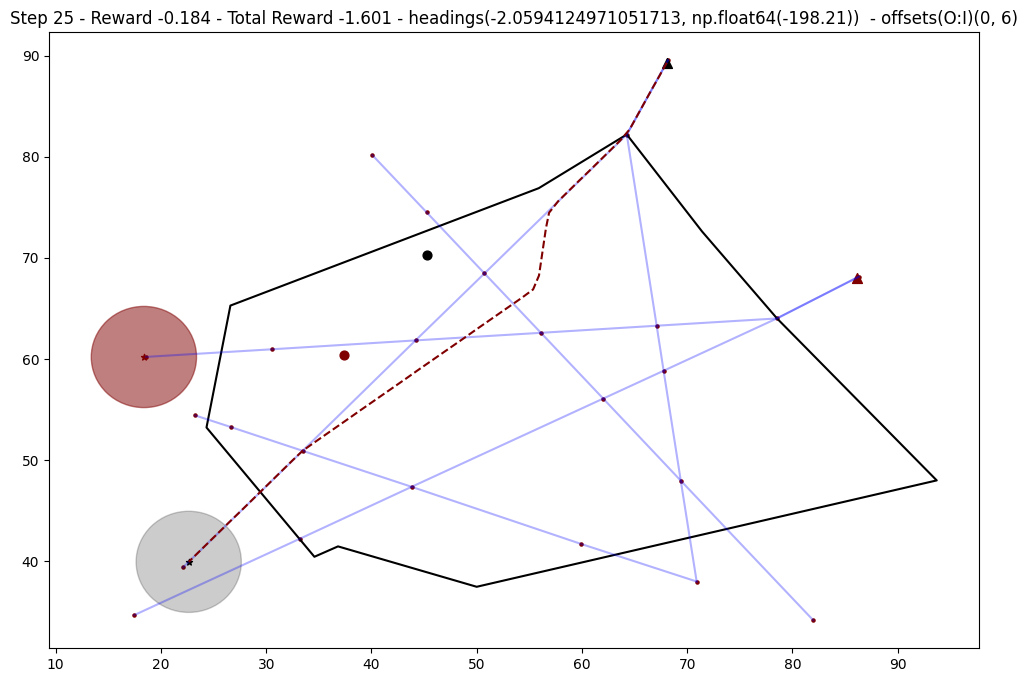

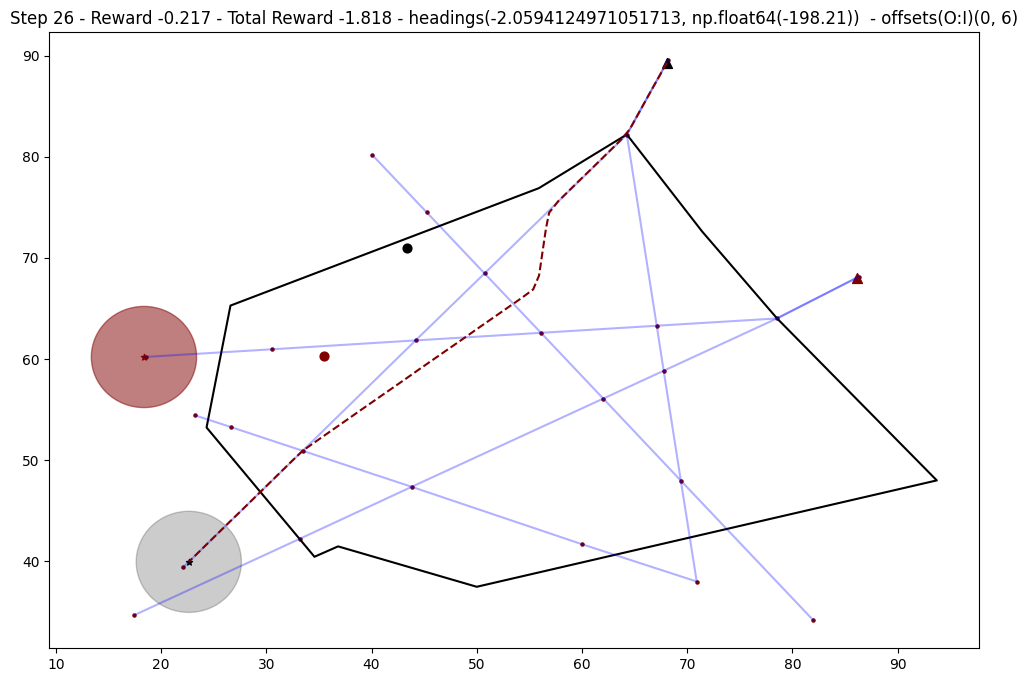

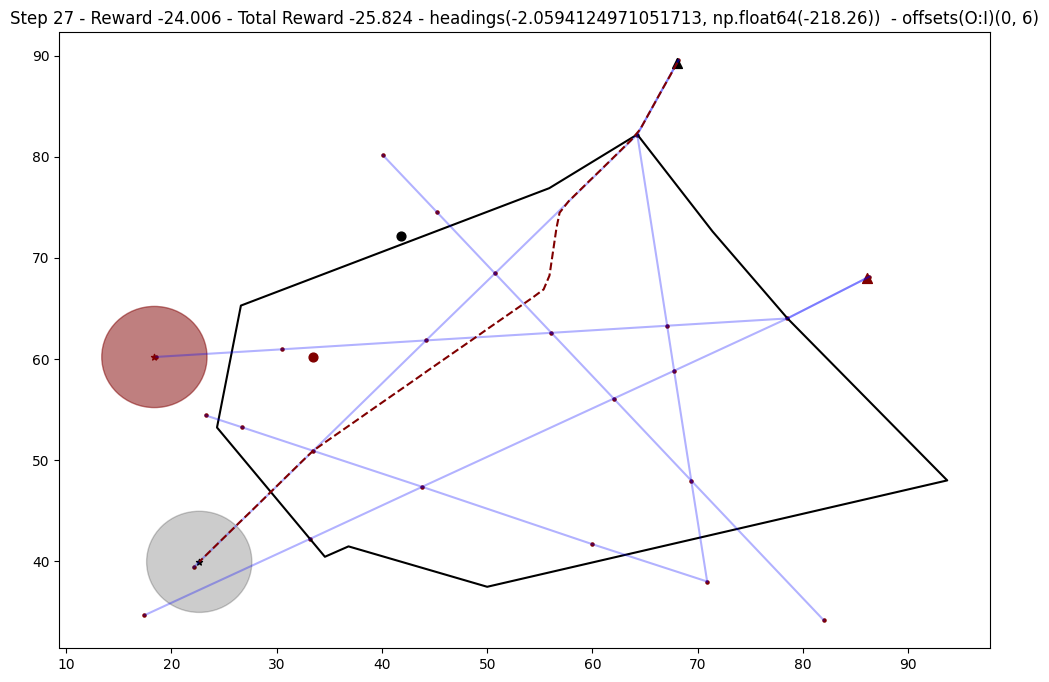

In [ ]:
# --- 1) Observation slicer so an older policy (e.g., 12-dim) can run on the new env (17-dim) ---
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import torch, os, glob, imageio.v2 as imageio
from datetime import datetime, timezone

# Initialize env and agent (same as before)
env = StructuredEnv(start_llm_at_step=0)
state_dim  = env.observation_space.shape[0]
action_dim = env.action_space.n
ppo_agent  = PPO(state_dim, action_dim,
                 lr_actor=2e-4, lr_critic=8e-4,
                 gamma=0.99, K_epochs=5, eps_clip=0.2,
                 mb_size=256, gae_lambda=0.95,
                 normalize_reward=True)

class ObsSliceWrapper(gym.ObservationWrapper):
    """Keep only the given indices from the observation vector."""
    def __init__(self, env, keep_idx=tuple(range(12))):
        super().__init__(env)
        self.keep_idx = np.array(keep_idx, dtype=int)
        low  = env.observation_space.low[self.keep_idx]
        high = env.observation_space.high[self.keep_idx]
        self.observation_space = spaces.Box(low=low, high=high, dtype=np.float64)

    def observation(self, obs):
        return obs[self.keep_idx]

# --- 2) Safe loader for older checkpoints (ignore non-matching tensors) ---
def safe_load_policy(agent, path):
    sd = torch.load(path, map_location=device)
    cur = agent.policy_old.state_dict()
    filtered = {k: v for k, v in sd.items() if k in cur and cur[k].shape == v.shape}
    missing = [k for k in cur.keys() if k not in filtered]
    agent.policy_old.load_state_dict({**cur, **filtered})
    agent.policy.load_state_dict(agent.policy_old.state_dict())
    if missing:
        print(f"[load warning] {len(missing)} params not loaded (shape or name mismatch).")

# --- 3) Helper: degrees → action index (your env's mapping) ---
def _deg_to_action_idx(delta_deg: int) -> int:
    d = int(round(delta_deg))
    if d % 5 != 0 or abs(d) > 30:
        raise ValueError(f"delta must be multiple of 5 and |d|<=30, got {delta_deg}")
    if d >= 0: return d // 5           # 0°→0, +5°→1, ..., +30°→6
    return 6 + (abs(d) // 5)           # -5°→7, ..., -30°→12

# --- 4) Small GIF saver for the episode frames ---
def _save_gif(frames_dir: str, out_gif_path: str, fps: float = 5.0):
    frames = sorted(glob.glob(os.path.join(frames_dir, "image_*.png")))
    if not frames:
        raise RuntimeError(f"No frames in {frames_dir}")
    images = [imageio.imread(f) for f in frames]
    imageio.mimsave(out_gif_path, images, duration=1.0/max(fps, 1e-6))

# --- 5) The test runner: LLM for 2 phases, then PPO_V3 policy takes over ---
def test_two_phase_llm_then_ppo(
    *,
    ppo_dir: str = "./log/PPO/PPO_V3",        # where PPO_V3 best_model.pth lives
    best_name: str = "best_model.pth",
    start_llm_at_step: int = 0,               # first step where base heading is under our control
    warmup_steps: int = 10000,                # rebuild obs normalizer for old policy
    frames_root: str = "eval_two_phase",
    fps: float = 5.0,
):
    # --- folders/files ---
    os.makedirs(frames_root, exist_ok=True)
    frames_dir = os.path.join(frames_root, "frames")
    os.makedirs(frames_dir, exist_ok=True)  # <— add this line
    for p in glob.glob(os.path.join(frames_dir, "image_*.png")):
        try: os.remove(p)
        except OSError: pass

    # --- build env + wrappers ---
    env_full = StructuredEnv(start_llm_at_step=start_llm_at_step)  # full 17-dim obs
    env_ppo  = ObsSliceWrapper(env_full, keep_idx=tuple(range(12))) # slice for old policy (0..11)

    # --- load PPO_V3 (state_dim=12) and warm up obs normalizer ---
    state_dim_old  = env_ppo.observation_space.shape[0]   # 12
    action_dim     = env_full.action_space.n              # 13
    agent_old = PPO(state_dim_old, action_dim,
                    lr_actor=2e-4, lr_critic=8e-4,
                    gamma=0.99, K_epochs=5, eps_clip=0.2,
                    mb_size=256, gae_lambda=0.95, normalize_reward=True)
    best_path = os.path.join(ppo_dir, best_name)
    if not os.path.exists(best_path):
        raise FileNotFoundError(f"Could not find PPO_V3 weights at {best_path}")
    safe_load_policy(agent_old, best_path)
    print("Loaded PPO_V3:", best_path)

    # Warm up obs norm using the sliced wrapper (evaluation only; no learning)
    warmup_obs_norm(agent_old, env_ppo, steps=warmup_steps)
    print(f"Obs normalizer warmed with {warmup_steps} steps.")

    # --- LLM tools ---
    builder = BasePromptBuilder()
    run_dir = start_llm_log_dir(base_dir="json_answers")  # per-run folder for LLM JSONs

    # --- episode ---
    obs_full, _ = env_full.reset()
    prev_full   = None
    hist_vecs, hist_steps = [], []
    terminated = truncated = False

    # 1) Let autopilot run until LLM gate
    while not (terminated or truncated) and env_full.n_step + 1 < start_llm_at_step:
        obs_full, _, terminated, truncated, _ = env_full.step(0)  # no heading change
        env_full.render(show=False, folder=frames_dir + "/")

    # 2) PHASE A: WAIT_TURN (LLM decides a hold; heading_change must be 0)
    step_idx = env_full.n_step + 1
    promptA = builder.build_base_prompt(
        obs_vector=obs_full, step=step_idx,
        prev_obs_vector=prev_full, prev_step=(step_idx-1 if prev_full is not None else None),
        history_vectors=hist_vecs, history_steps=hist_steps
    )
    promptA = attach_phase_state_block(promptA,
        current_phase="WAIT_TURN", step_index=step_idx, allowed_bins=[-30,-25,-20,-15,-10,-5,0,5,10,15,20,25,30]
    )
    kin = builder.last_kinematics or {}
    resA = call_llm_for_maneuver(promptA, save_dir=run_dir, tag=f"t{step_idx:03d}_wait", 
                                 override_metrics={"separation_distance": kin.get("sep", None),
                                                   "ttcp": kin.get("ttcp_steps", None)},
                                 expected_phase="WAIT_TURN")
    holdA = int(resA["answer"]["maneuver"].get("hold_steps", 0))
    # Apply WAIT_TURN: 0° now, then hold (0 actions keep heading once autopilot is off)
    for _ in range(max(1, holdA+1)):  # do at least one step through the phase
        prev_full = obs_full.copy()
        hist_vecs.append(prev_full); hist_steps.append(env_full.n_step)
        obs_full, _, terminated, truncated, _ = env_full.step(0)
        env_full.render(show=False, folder=frames_dir + "/")
        if terminated or truncated: break

    if not (terminated or truncated):
        # 3) PHASE B: EXECUTE_TURN (LLM picks one non-zero turn + hold)
        step_idx = env_full.n_step + 1
        promptB = builder.build_base_prompt(
            obs_vector=obs_full, step=step_idx,
            prev_obs_vector=prev_full, prev_step=(step_idx-1 if prev_full is not None else None),
            history_vectors=hist_vecs[-5:], history_steps=hist_steps[-5:]
        )
        promptB = attach_phase_state_block(promptB,
            current_phase="EXECUTE_TURN", step_index=step_idx, allowed_bins=[-30,-25,-20,-15,-10,-5,0,5,10,15,20,25,30]
        )
        kin = builder.last_kinematics or {}
        resB = call_llm_for_maneuver(promptB, save_dir=run_dir, tag=f"t{step_idx:03d}_exec",
                                     override_metrics={"separation_distance": kin.get("sep", None),
                                                       "ttcp": kin.get("ttcp_steps", None)},
                                     expected_phase="EXECUTE_TURN")
        turnB = int(resB["answer"]["maneuver"].get("heading_change_deg", 0))
        holdB = int(resB["answer"]["maneuver"].get("hold_steps", 0))

        # one-time LLM turn:
        try:
            a_idx = _deg_to_action_idx(turnB)
        except ValueError:
            print(f"[LLM turn warning] invalid {turnB}°, using 0°")
            a_idx = 0
        prev_full = obs_full.copy()
        hist_vecs.append(prev_full); hist_steps.append(env_full.n_step)
        obs_full, _, terminated, truncated, _ = env_full.step(a_idx)
        env_full.render(show=False, folder=frames_dir + "/")

        # then hold straight for holdB steps (send 0)
        for _ in range(holdB):
            if terminated or truncated: break
            prev_full = obs_full.copy()
            hist_vecs.append(prev_full); hist_steps.append(env_full.n_step)
            obs_full, _, terminated, truncated, _ = env_full.step(0)
            env_full.render(show=False, folder=frames_dir + "/")

    # 4) PPO_V3 takes over to the end
    while not (terminated or truncated):
        ppo_obs = obs_full[:12]  # slice like the wrapper
        st = torch.tensor(ppo_obs, dtype=torch.float32, device=device)
        st = agent_old._normalize_obs_eval(st)
        with torch.no_grad():
            feats  = agent_old.policy_old.net(st)
            probs  = agent_old.policy_old.actor(feats)
            action = torch.argmax(probs, dim=-1).item()
        obs_full, _, terminated, truncated, _ = env_full.step(int(action))
        env_full.render(show=False, folder=frames_dir + "/")

    # 5) Save GIF
    ts = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    out_gif = os.path.join(frames_root, f"{ts}_two_phase_then_ppo.gif")
    _save_gif(frames_dir, out_gif, fps=fps)
    print("Saved:", out_gif)
    return out_gif

# ---- Run the test once (edit path if your PPO_V3 lives elsewhere) ----
gif_path = test_two_phase_llm_then_ppo(
    ppo_dir="/home/aradhya.dhruv/rl/behaviour_cloning/LLM enhanced DRL/log/PPO/PPO_v3/",
    best_name="best_model.pth",
    start_llm_at_step=0,
    warmup_steps=8000,
    frames_root="/home/aradhya.dhruv/rl/behaviour_cloning/LLM enhanced DRL/LLM-driven RL/Evaluation Frames",
    fps=5.0,
)
print("Done:", gif_path)
